In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ravirajsinh45/real-life-industrial-dataset-of-casting-product")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product


DATASET CHECK
Dataset path: /kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_512x512/casting_512x512
Exists      : True

FOLDER STRUCTURE
📁 casting_512x512/  --> 0 images
    📁 ok_front/  --> 519 images
    📁 def_front/  --> 781 images

TOTAL IMAGE COUNT
Total images: 1,300

First few images:


,filename,parent_folder,relative_path,full_path
0,cast_def_0_0.jpeg,def_front,def_front/cast_def_0_0.jpeg,/kaggle/input/datasets/ravirajsinh45/real-life...
1,cast_def_0_100.jpeg,def_front,def_front/cast_def_0_100.jpeg,/kaggle/input/datasets/ravirajsinh45/real-life...
2,cast_def_0_1015.jpeg,def_front,def_front/cast_def_0_1015.jpeg,/kaggle/input/datasets/ravirajsinh45/real-life...
3,cast_def_0_102.jpeg,def_front,def_front/cast_def_0_102.jpeg,/kaggle/input/datasets/ravirajsinh45/real-life...
4,cast_def_0_1046.jpeg,def_front,def_front/cast_def_0_1046.jpeg,/kaggle/input/datasets/ravirajsinh45/real-life...



IMAGE COUNT BY FOLDER / CLASS


,Folder/Class,Image Count
0,def_front,781
1,ok_front,519


def_front                      : 781
ok_front                       : 519


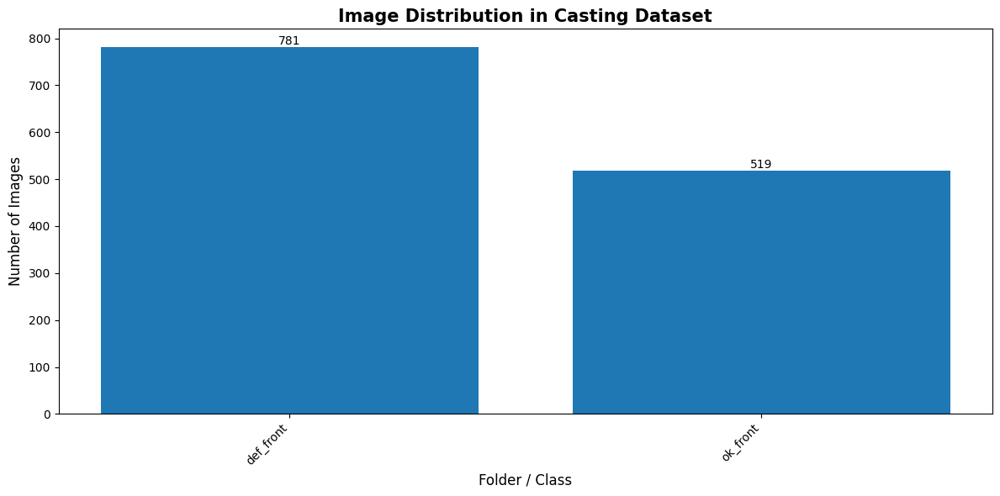


CLASS/FOLDER DISTRIBUTION


,Folder/Class,Image Count,Percentage (%)
0,def_front,781,60.076923
1,ok_front,519,39.923077



IMAGE RESOLUTIONS


,Width,Height,Count
0,512,512,1300



Corrupted/unreadable images: 0


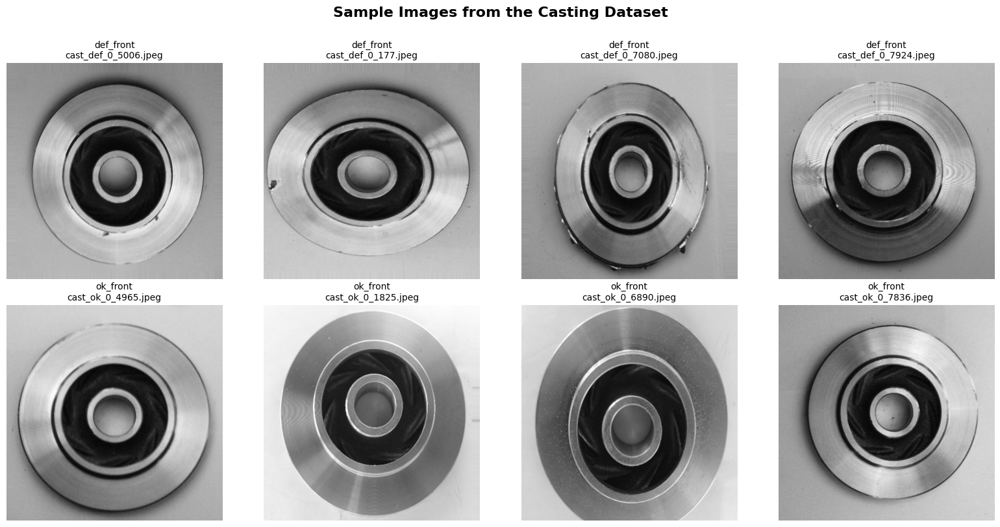


FINAL DATASET SUMMARY
Total images             : 1,300
Detected folders/classes : 2
Corrupted images         : 0

Distribution:
def_front                          781 images (60.08%)
ok_front                           519 images (39.92%)


In [2]:
# ============================================================
# CHECK IMAGE COUNT + PLOT DATASET DISTRIBUTION + SAMPLE IMAGES
# ============================================================

import os
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# 1. Dataset path
# ------------------------------------------------------------
DATASET_PATH = Path(
    "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_512x512/casting_512x512"
)

# Supported image extensions
IMAGE_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

print("=" * 70)
print("DATASET CHECK")
print("=" * 70)

print(f"Dataset path: {DATASET_PATH}")
print(f"Exists      : {DATASET_PATH.exists()}")

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset directory not found:\n{DATASET_PATH}")


# ------------------------------------------------------------
# 2. Display folder structure
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FOLDER STRUCTURE")
print("=" * 70)

for root, dirs, files in os.walk(DATASET_PATH):
    level = len(Path(root).relative_to(DATASET_PATH).parts)

    # Limit printed indentation
    indent = "    " * level
    folder_name = Path(root).name

    image_count = sum(
        1 for f in files
        if Path(f).suffix.lower() in IMAGE_EXTS
    )

    print(f"{indent}📁 {folder_name}/  --> {image_count} images")


# ------------------------------------------------------------
# 3. Collect every image recursively
# ------------------------------------------------------------
image_paths = sorted([
    p for p in DATASET_PATH.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
])

print("\n" + "=" * 70)
print("TOTAL IMAGE COUNT")
print("=" * 70)

print(f"Total images: {len(image_paths):,}")

if len(image_paths) == 0:
    raise RuntimeError("No image files were detected.")


# ------------------------------------------------------------
# 4. Create dataframe containing path information
# ------------------------------------------------------------
records = []

for img_path in image_paths:
    relative_path = img_path.relative_to(DATASET_PATH)
    parts = relative_path.parts

    records.append({
        "filename": img_path.name,
        "parent_folder": img_path.parent.name,
        "relative_path": str(relative_path),
        "full_path": str(img_path)
    })

df = pd.DataFrame(records)

print("\nFirst few images:")
display(df.head())


# ------------------------------------------------------------
# 5. Count images by immediate parent folder
# ------------------------------------------------------------
folder_counts = (
    df["parent_folder"]
    .value_counts()
    .rename_axis("Folder/Class")
    .reset_index(name="Image Count")
)

print("\n" + "=" * 70)
print("IMAGE COUNT BY FOLDER / CLASS")
print("=" * 70)

display(folder_counts)

for _, row in folder_counts.iterrows():
    print(f"{row['Folder/Class']:<30} : {row['Image Count']:,}")


# ------------------------------------------------------------
# 6. Plot image distribution
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

bars = plt.bar(
    folder_counts["Folder/Class"],
    folder_counts["Image Count"]
)

plt.title(
    "Image Distribution in Casting Dataset",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Folder / Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Display count above every bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Percentage distribution
# ------------------------------------------------------------
folder_counts["Percentage (%)"] = (
    folder_counts["Image Count"] /
    folder_counts["Image Count"].sum() * 100
)

print("\n" + "=" * 70)
print("CLASS/FOLDER DISTRIBUTION")
print("=" * 70)

display(folder_counts)


# ------------------------------------------------------------
# 8. Check image sizes
# ------------------------------------------------------------
size_counter = Counter()
corrupted_images = []

for img_path in image_paths:
    try:
        with Image.open(img_path) as img:
            size_counter[img.size] += 1
    except Exception as e:
        corrupted_images.append(str(img_path))

size_df = pd.DataFrame([
    {
        "Width": size[0],
        "Height": size[1],
        "Count": count
    }
    for size, count in size_counter.items()
]).sort_values("Count", ascending=False)

print("\n" + "=" * 70)
print("IMAGE RESOLUTIONS")
print("=" * 70)

display(size_df)

print(f"\nCorrupted/unreadable images: {len(corrupted_images)}")

if corrupted_images:
    print("\nCorrupted files:")
    for p in corrupted_images[:20]:
        print(p)


# ------------------------------------------------------------
# 9. Display sample images from each folder/class
# ------------------------------------------------------------
classes = folder_counts["Folder/Class"].tolist()

N_PER_CLASS = 4

fig, axes = plt.subplots(
    len(classes),
    N_PER_CLASS,
    figsize=(4 * N_PER_CLASS, 4 * len(classes))
)

# Handle single-class case
if len(classes) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, class_name in enumerate(classes):

    class_paths = df[
        df["parent_folder"] == class_name
    ]["full_path"].tolist()

    # Random samples
    rng = np.random.default_rng(42)

    selected = rng.choice(
        class_paths,
        size=min(N_PER_CLASS, len(class_paths)),
        replace=False
    )

    for col_idx in range(N_PER_CLASS):

        ax = axes[row_idx, col_idx]
        ax.axis("off")

        if col_idx < len(selected):

            img_path = selected[col_idx]

            try:
                img = Image.open(img_path).convert("RGB")

                ax.imshow(img)
                ax.set_title(
                    f"{class_name}\n{Path(img_path).name[:30]}",
                    fontsize=10
                )

            except Exception:
                ax.set_title("Unable to read")

plt.suptitle(
    "Sample Images from the Casting Dataset",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Final summary
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

print(f"Total images             : {len(image_paths):,}")
print(f"Detected folders/classes : {len(folder_counts)}")
print(f"Corrupted images         : {len(corrupted_images)}")

print("\nDistribution:")

for _, row in folder_counts.iterrows():
    print(
        f"{row['Folder/Class']:<30} "
        f"{row['Image Count']:>7,} images "
        f"({row['Percentage (%)']:.2f}%)"
    )

print("=" * 70)

Input : /kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_512x512/casting_512x512
Output: /kaggle/working/casting_512x512_preprocessed

Total images found: 1300


Preprocessing images:   0%|          | 0/1300 [00:00<?, ?it/s]


PREPROCESSING COMPLETED
Input images     : 1,300
Processed images : 1,300
Failed images    : 0

Saved at:
/kaggle/working/casting_512x512_preprocessed

Verified saved images: 1,300


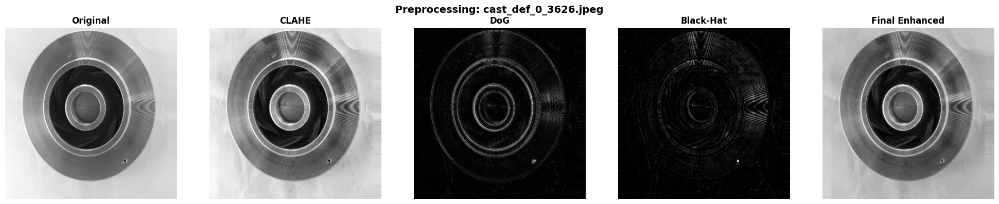

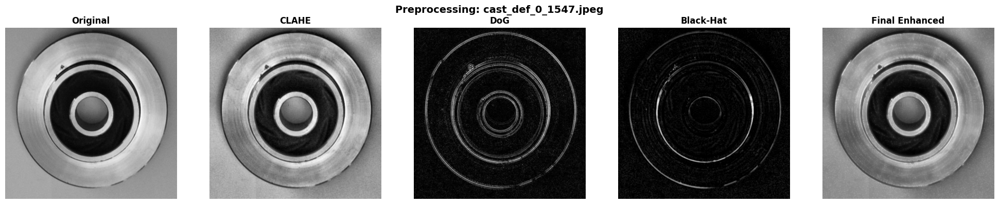

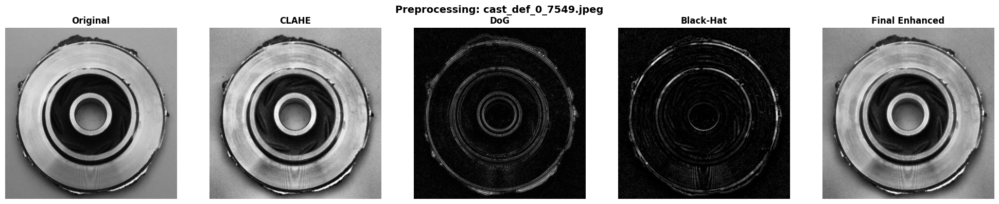

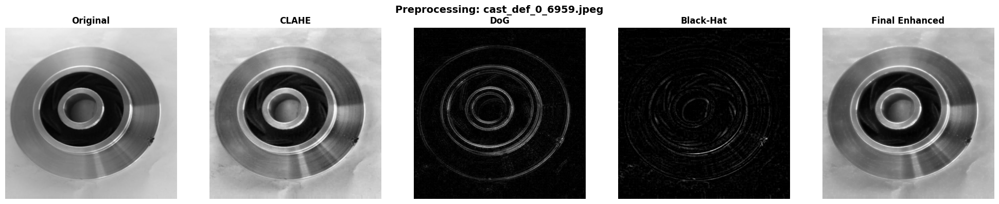

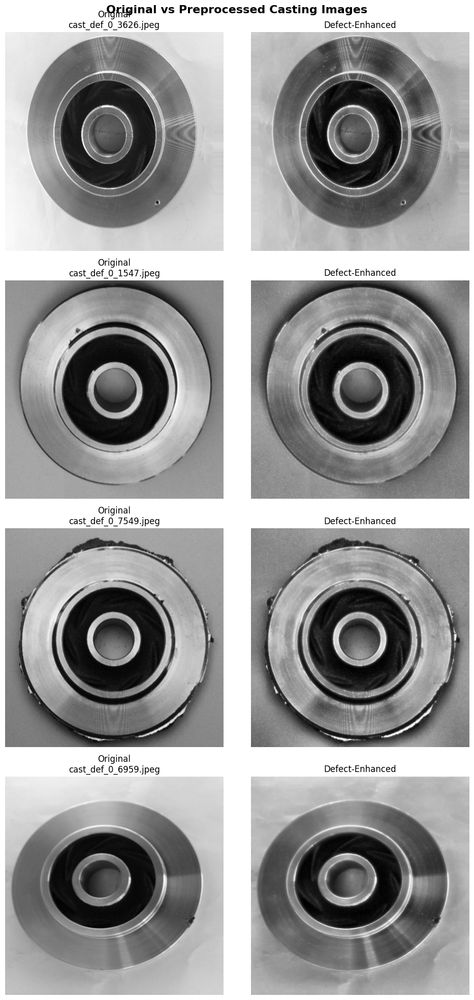


OUTPUT DIRECTORY STRUCTURE
casting_512x512_preprocessed/ --> 0 images
    ok_front/ --> 519 images
    def_front/ --> 781 images


In [3]:
# ============================================================
# CASTING DEFECT-AWARE IMAGE PREPROCESSING
#
# Pipeline:
# Grayscale
#    ↓
# CLAHE
#    ↓
# Difference of Gaussians (DoG)
#    ↓
# Black-Hat Morphology
#    ↓
# Weighted Fusion
#    ↓
# Normalize to 0-255
#    ↓
# Save to NEW directory
#
# Original dataset remains unchanged.
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm
import random


# ============================================================
# 1. PATHS
# ============================================================

INPUT_DIR = Path(
    "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_512x512/casting_512x512"
)

OUTPUT_DIR = Path(
    "/kaggle/working/casting_512x512_preprocessed"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input :", INPUT_DIR)
print("Output:", OUTPUT_DIR)

assert INPUT_DIR.exists(), f"Input directory not found: {INPUT_DIR}"


# ============================================================
# 2. IMAGE EXTENSIONS
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


# ============================================================
# 3. HELPER: NORMALIZE IMAGE TO 0-255
# ============================================================

def normalize_uint8(img):

    img = img.astype(np.float32)

    min_val = img.min()
    max_val = img.max()

    if max_val - min_val < 1e-8:
        return np.zeros_like(img, dtype=np.uint8)

    img = (img - min_val) / (max_val - min_val)

    img = img * 255.0

    return np.clip(img, 0, 255).astype(np.uint8)


# ============================================================
# 4. PREPROCESSING FUNCTION
# ============================================================

def preprocess_casting_image(image_path):

    # --------------------------------------------------------
    # Read image
    # --------------------------------------------------------

    img = cv2.imread(str(image_path))

    if img is None:
        raise ValueError(f"Cannot read image: {image_path}")


    # --------------------------------------------------------
    # STEP 1: Convert to grayscale
    # --------------------------------------------------------

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )


    # --------------------------------------------------------
    # STEP 2: Mild denoising
    #
    # Small Gaussian blur removes tiny sensor noise.
    # Do NOT use strong blur because thin defects may disappear.
    # --------------------------------------------------------

    gray_smooth = cv2.GaussianBlur(
        gray,
        (3, 3),
        sigmaX=0.5
    )


    # --------------------------------------------------------
    # STEP 3: CLAHE
    #
    # Improves local contrast.
    # Useful for faint cracks, pits, scratches and defects.
    # --------------------------------------------------------

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    clahe_img = clahe.apply(gray_smooth)


    # --------------------------------------------------------
    # STEP 4: Difference of Gaussians (DoG)
    #
    # Enhances fine/high-frequency surface structures.
    # --------------------------------------------------------

    gaussian_small = cv2.GaussianBlur(
        clahe_img,
        (0, 0),
        sigmaX=0.8
    )

    gaussian_large = cv2.GaussianBlur(
        clahe_img,
        (0, 0),
        sigmaX=2.0
    )

    dog = cv2.absdiff(
        gaussian_small,
        gaussian_large
    )

    dog = normalize_uint8(dog)


    # --------------------------------------------------------
    # STEP 5: Black-Hat Morphology
    #
    # Particularly useful for:
    # - dark scratches
    # - thin cracks
    # - pits
    # - dark local defects
    # --------------------------------------------------------

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (9, 9)
    )

    blackhat = cv2.morphologyEx(
        clahe_img,
        cv2.MORPH_BLACKHAT,
        kernel
    )

    blackhat = normalize_uint8(blackhat)


    # --------------------------------------------------------
    # STEP 6: Mild defect-aware fusion
    #
    # CLAHE remains dominant.
    # DoG and Black-hat only enhance small details.
    #
    # This avoids converting the image into an edge map.
    # --------------------------------------------------------

    clahe_float = clahe_img.astype(np.float32)
    dog_float = dog.astype(np.float32)
    blackhat_float = blackhat.astype(np.float32)

    enhanced = (
        0.75 * clahe_float +
        0.15 * dog_float +
        0.10 * blackhat_float
    )


    # --------------------------------------------------------
    # STEP 7: Normalize final result
    # --------------------------------------------------------

    enhanced = normalize_uint8(enhanced)


    # --------------------------------------------------------
    # STEP 8: Optional mild sharpening
    #
    # Very mild sharpening only.
    # --------------------------------------------------------

    blurred = cv2.GaussianBlur(
        enhanced,
        (0, 0),
        sigmaX=1.0
    )

    final = cv2.addWeighted(
        enhanced,
        1.15,
        blurred,
        -0.15,
        0
    )

    final = np.clip(
        final,
        0,
        255
    ).astype(np.uint8)


    return {
        "original": gray,
        "clahe": clahe_img,
        "dog": dog,
        "blackhat": blackhat,
        "final": final
    }


# ============================================================
# 5. FIND ALL IMAGES
# ============================================================

image_paths = sorted([
    path
    for path in INPUT_DIR.rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
])

print("\nTotal images found:", len(image_paths))

if len(image_paths) == 0:
    raise RuntimeError("No images found!")


# ============================================================
# 6. PROCESS + SAVE ALL IMAGES
# ============================================================

processed_count = 0
failed_images = []

for image_path in tqdm(
    image_paths,
    desc="Preprocessing images"
):

    try:

        # ----------------------------------------------------
        # Run preprocessing
        # ----------------------------------------------------

        result = preprocess_casting_image(
            image_path
        )

        final_img = result["final"]


        # ----------------------------------------------------
        # Preserve original directory structure
        #
        # Example:
        #
        # INPUT:
        # casting_512x512/train/def_front/image.jpeg
        #
        # OUTPUT:
        # casting_512x512_preprocessed/train/def_front/image.png
        # ----------------------------------------------------

        relative_path = image_path.relative_to(
            INPUT_DIR
        )

        output_path = (
            OUTPUT_DIR /
            relative_path
        ).with_suffix(".png")


        # Create required folder
        output_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )


        # ----------------------------------------------------
        # Save as PNG
        #
        # PNG avoids introducing additional JPEG artifacts.
        # ----------------------------------------------------

        success = cv2.imwrite(
            str(output_path),
            final_img
        )

        if success:
            processed_count += 1

        else:
            failed_images.append(
                str(image_path)
            )

    except Exception as e:

        failed_images.append(
            f"{image_path} -> {e}"
        )


# ============================================================
# 7. SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PREPROCESSING COMPLETED")
print("=" * 70)

print(f"Input images     : {len(image_paths):,}")
print(f"Processed images : {processed_count:,}")
print(f"Failed images    : {len(failed_images):,}")

print("\nSaved at:")
print(OUTPUT_DIR)


if failed_images:

    print("\nFirst failed images:")

    for item in failed_images[:10]:
        print(item)


# ============================================================
# 8. VERIFY OUTPUT IMAGE COUNT
# ============================================================

saved_images = [
    p
    for p in OUTPUT_DIR.rglob("*.png")
]

print(
    f"\nVerified saved images: "
    f"{len(saved_images):,}"
)


# ============================================================
# 9. SHOW FULL PREPROCESSING STAGES
# ============================================================

random.seed(42)

num_samples = min(
    4,
    len(image_paths)
)

sample_paths = random.sample(
    image_paths,
    num_samples
)


for sample_path in sample_paths:

    result = preprocess_casting_image(
        sample_path
    )

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(20, 4)
    )

    images = [
        result["original"],
        result["clahe"],
        result["dog"],
        result["blackhat"],
        result["final"]
    ]

    titles = [
        "Original",
        "CLAHE",
        "DoG",
        "Black-Hat",
        "Final Enhanced"
    ]

    for ax, img, title in zip(
        axes,
        images,
        titles
    ):

        ax.imshow(
            img,
            cmap="gray"
        )

        ax.set_title(
            title,
            fontsize=12,
            fontweight="bold"
        )

        ax.axis("off")

    plt.suptitle(
        f"Preprocessing: {sample_path.name}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 10. ORIGINAL VS FINAL COMPARISON
# ============================================================

fig, axes = plt.subplots(
    num_samples,
    2,
    figsize=(10, 5 * num_samples)
)

if num_samples == 1:
    axes = np.expand_dims(
        axes,
        axis=0
    )


for row, sample_path in enumerate(sample_paths):

    result = preprocess_casting_image(
        sample_path
    )

    # Original
    axes[row, 0].imshow(
        result["original"],
        cmap="gray"
    )

    axes[row, 0].set_title(
        f"Original\n{sample_path.name}"
    )

    axes[row, 0].axis("off")


    # Enhanced
    axes[row, 1].imshow(
        result["final"],
        cmap="gray"
    )

    axes[row, 1].set_title(
        "Defect-Enhanced"
    )

    axes[row, 1].axis("off")


plt.suptitle(
    "Original vs Preprocessed Casting Images",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ============================================================
# 11. PRINT OUTPUT FOLDER STRUCTURE
# ============================================================

print("\n" + "=" * 70)
print("OUTPUT DIRECTORY STRUCTURE")
print("=" * 70)

for root, dirs, files in os.walk(
    OUTPUT_DIR
):

    level = len(
        Path(root)
        .relative_to(OUTPUT_DIR)
        .parts
    )

    indent = "    " * level

    image_count = sum(
        Path(f).suffix.lower()
        in IMAGE_EXTENSIONS
        for f in files
    )

    print(
        f"{indent}"
        f"{Path(root).name}/ "
        f"--> {image_count} images"
    )

Total images found: 1,300

Detected classes:
ok_front             : 519 images
def_front            : 781 images

Class: def_front
Total : 781
Train : 624 (79.90%)
Val   : 78 (9.99%)
Test  : 79 (10.12%)

Class: ok_front
Total : 519
Train : 415 (79.96%)
Val   : 51 (9.83%)
Test  : 53 (10.21%)

FINAL SPLIT SUMMARY


Class,def_front,ok_front
Split,,
train,624,415
val,78,51
test,79,53



Total images per split:
train      :  1,039 (79.92%)
val        :    129 (9.92%)
test       :    132 (10.15%)


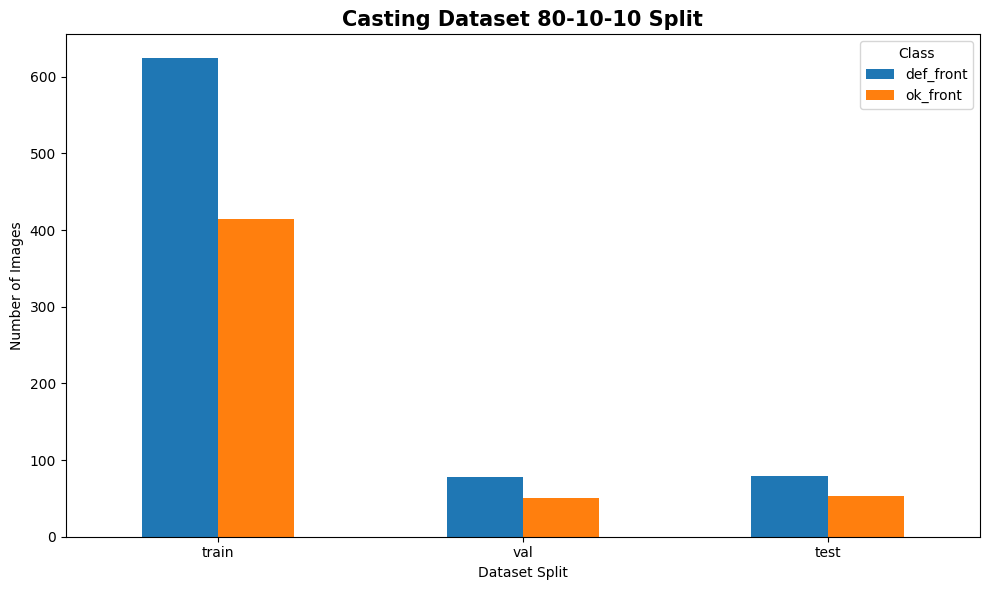


OVERLAP CHECK
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

DATASET SPLIT COMPLETED
Saved to:
/kaggle/working/casting_512x512_split

Folder structure:

casting_512x512_split/
│
├── train/
│   ├── def_front/
│   └── ok_front/
│
├── val/
│   ├── def_front/
│   └── ok_front/
│
└── test/
    ├── def_front/
    └── ok_front/



In [4]:
# ============================================================
# SPLIT PREPROCESSED CASTING DATASET
# TRAIN : VALIDATION : TEST = 80 : 10 : 10
# ============================================================

import shutil
import random
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PATHS
# ============================================================

SOURCE_DIR = Path(
    "/kaggle/working/casting_512x512_preprocessed"
)

SPLIT_DIR = Path(
    "/kaggle/working/casting_512x512_split"
)

# Fresh output directory
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

SPLIT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. SETTINGS
# ============================================================

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

SEED = 42

random.seed(SEED)

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


# ============================================================
# 3. FIND ALL IMAGES
# ============================================================

all_images = [
    p for p in SOURCE_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
]

print(f"Total images found: {len(all_images):,}")


# ============================================================
# 4. GROUP IMAGES BY CLASS
#
# Dataset classes:
# def_front
# ok_front
# ============================================================

class_images = defaultdict(list)

for img_path in all_images:

    # Immediate parent folder = class
    class_name = img_path.parent.name

    class_images[class_name].append(img_path)


print("\nDetected classes:")

for class_name, images in class_images.items():
    print(
        f"{class_name:<20} : "
        f"{len(images):,} images"
    )


# ============================================================
# 5. SPLIT EACH CLASS SEPARATELY
# ============================================================

split_records = []

for class_name, images in sorted(class_images.items()):

    images = images.copy()

    # Deterministic shuffle
    random.shuffle(images)

    total = len(images)

    # --------------------------------------------------------
    # 80 / 10 / 10
    # --------------------------------------------------------

    n_train = int(total * TRAIN_RATIO)
    n_val   = int(total * VAL_RATIO)

    # Remaining images go to test
    n_test = total - n_train - n_val


    train_images = images[:n_train]

    val_images = images[
        n_train:
        n_train + n_val
    ]

    test_images = images[
        n_train + n_val:
    ]


    split_data = {
        "train": train_images,
        "val": val_images,
        "test": test_images
    }


    # ========================================================
    # 6. COPY FILES
    # ========================================================

    for split_name, split_images in split_data.items():

        destination_folder = (
            SPLIT_DIR /
            split_name /
            class_name
        )

        destination_folder.mkdir(
            parents=True,
            exist_ok=True
        )


        for idx, src_path in enumerate(split_images):

            # ------------------------------------------------
            # Prevent duplicate filename collisions
            # ------------------------------------------------

            new_name = src_path.name

            dst_path = (
                destination_folder /
                new_name
            )


            # If duplicate filename already exists,
            # create unique name
            if dst_path.exists():

                new_name = (
                    f"{src_path.stem}_"
                    f"{idx}"
                    f"{src_path.suffix}"
                )

                dst_path = (
                    destination_folder /
                    new_name
                )


            shutil.copy2(
                src_path,
                dst_path
            )


            split_records.append({
                "Split": split_name,
                "Class": class_name,
                "Filename": new_name
            })


    print("\n" + "=" * 60)

    print(f"Class: {class_name}")

    print(
        f"Total : {total:,}"
    )

    print(
        f"Train : {len(train_images):,} "
        f"({len(train_images)/total*100:.2f}%)"
    )

    print(
        f"Val   : {len(val_images):,} "
        f"({len(val_images)/total*100:.2f}%)"
    )

    print(
        f"Test  : {len(test_images):,} "
        f"({len(test_images)/total*100:.2f}%)"
    )


# ============================================================
# 7. CREATE SUMMARY DATAFRAME
# ============================================================

df_split = pd.DataFrame(
    split_records
)

summary = (
    df_split
    .groupby(["Split", "Class"])
    .size()
    .unstack(fill_value=0)
)


# Correct split order
summary = summary.reindex(
    ["train", "val", "test"]
)


print("\n" + "=" * 70)
print("FINAL SPLIT SUMMARY")
print("=" * 70)

display(summary)


# ============================================================
# 8. TOTAL PER SPLIT
# ============================================================

split_totals = (
    df_split["Split"]
    .value_counts()
    .reindex(
        ["train", "val", "test"]
    )
)

print("\nTotal images per split:")

for split_name, count in split_totals.items():

    percentage = (
        count /
        len(df_split) *
        100
    )

    print(
        f"{split_name:<10} : "
        f"{count:>6,} "
        f"({percentage:.2f}%)"
    )


# ============================================================
# 9. PLOT SPLIT DISTRIBUTION
# ============================================================

plot_df = (
    df_split
    .groupby(["Split", "Class"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        ["train", "val", "test"]
    )
)

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Casting Dataset 80-10-10 Split",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

plt.xticks(
    rotation=0
)

plt.legend(
    title="Class"
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. VERIFY NO IMAGE OVERLAP
# ============================================================

train_files = set(
    df_split[
        df_split["Split"] == "train"
    ]["Filename"]
)

val_files = set(
    df_split[
        df_split["Split"] == "val"
    ]["Filename"]
)

test_files = set(
    df_split[
        df_split["Split"] == "test"
    ]["Filename"]
)


print("\n" + "=" * 70)
print("OVERLAP CHECK")
print("=" * 70)

print(
    "Train ∩ Val :",
    len(train_files & val_files)
)

print(
    "Train ∩ Test:",
    len(train_files & test_files)
)

print(
    "Val ∩ Test  :",
    len(val_files & test_files)
)


# ============================================================
# 11. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("DATASET SPLIT COMPLETED")
print("=" * 70)

print(f"Saved to:\n{SPLIT_DIR}")

print("\nFolder structure:")

print("""
casting_512x512_split/
│
├── train/
│   ├── def_front/
│   └── ok_front/
│
├── val/
│   ├── def_front/
│   └── ok_front/
│
└── test/
    ├── def_front/
    └── ok_front/
""")

Available augmentations:
 - HFlip
 - VFlip
 - Rotate
 - BrightnessContrast
 - Gamma
 - GaussianNoise
 - MildBlur
 - Translation

TRAINING DATA
Original training images: 1,039
Classes detected: ['def_front', 'ok_front']
def_front           : 624
ok_front            : 415


Augmenting training data:   0%|          | 0/1039 [00:00<?, ?it/s]


AUGMENTATION COMPLETED
Original train images : 1,039
Augmented generated   : 2,078
Total training images : 3,117

Saved at:
/kaggle/working/casting_train_augmented

Class summary:


Type,Augmented V1,Augmented V2,Original
Class,,,
def_front,624,624,624
ok_front,415,415,415



Final number of training images:
def_front           : 1,872
ok_front            : 1,245

Example augmentation records:


,Class,Type,Filename,Augmentations
1,def_front,Augmented V1,cast_def_0_0_aug_v1.png,VFlip + HFlip + GaussianNoise + Rotate
2,def_front,Augmented V2,cast_def_0_0_aug_v2.png,VFlip + GaussianNoise + MildBlur + Gamma
4,def_front,Augmented V1,cast_def_0_1015_aug_v1.png,BrightnessContrast + VFlip + Gamma + GaussianN...
5,def_front,Augmented V2,cast_def_0_1015_aug_v2.png,MildBlur + VFlip + BrightnessContrast + Gamma
7,def_front,Augmented V1,cast_def_0_102_aug_v1.png,MildBlur + Rotate + Translation + VFlip
8,def_front,Augmented V2,cast_def_0_102_aug_v2.png,GaussianNoise + MildBlur + Rotate + Gamma
10,def_front,Augmented V1,cast_def_0_1046_aug_v1.png,MildBlur + HFlip + Gamma + Rotate
11,def_front,Augmented V2,cast_def_0_1046_aug_v2.png,BrightnessContrast + GaussianNoise + HFlip + M...
13,def_front,Augmented V1,cast_def_0_1053_aug_v1.png,BrightnessContrast + MildBlur + HFlip + Transl...
14,def_front,Augmented V2,cast_def_0_1053_aug_v2.png,Gamma + GaussianNoise + MildBlur + HFlip


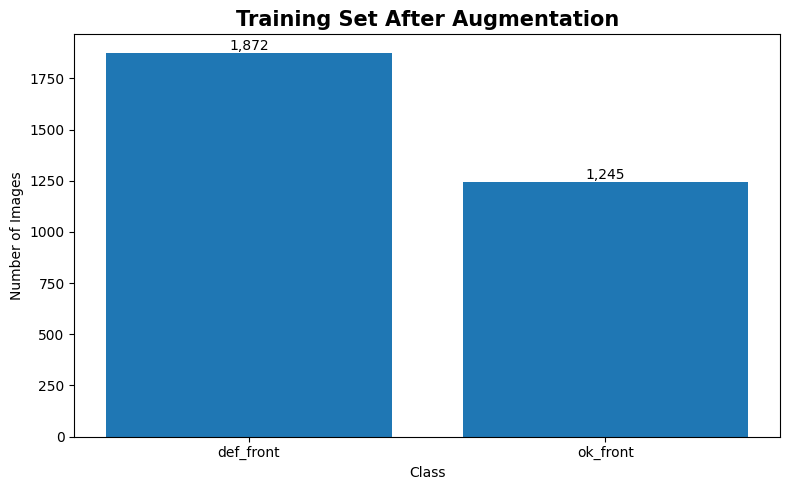

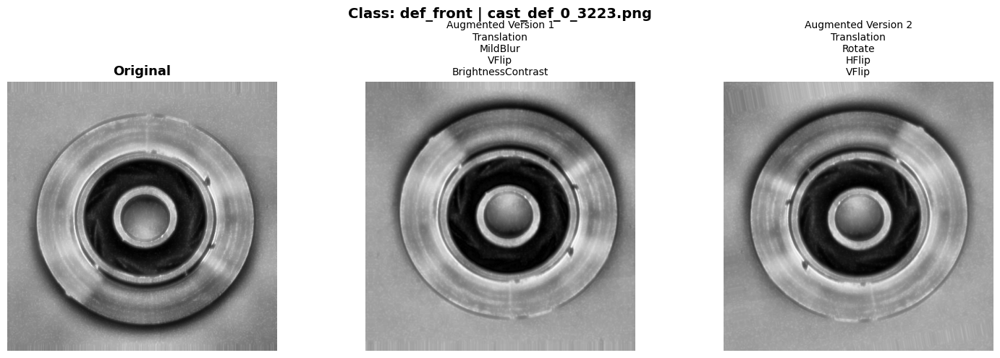

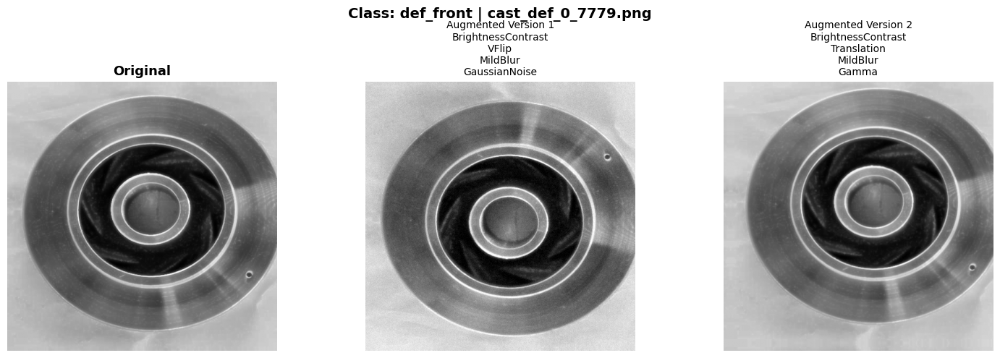

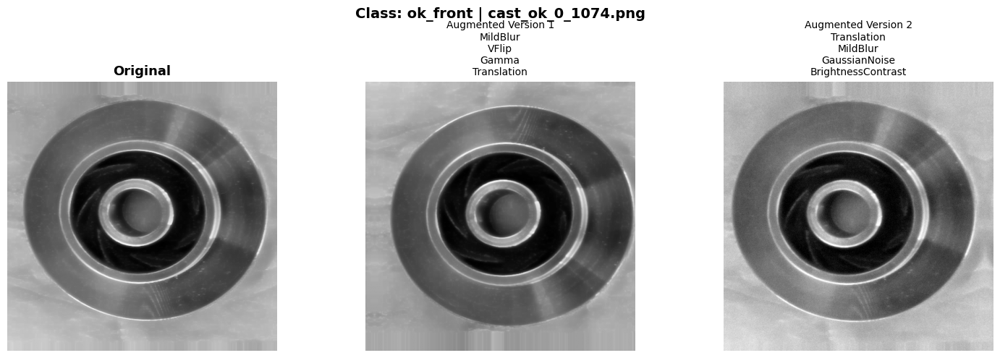

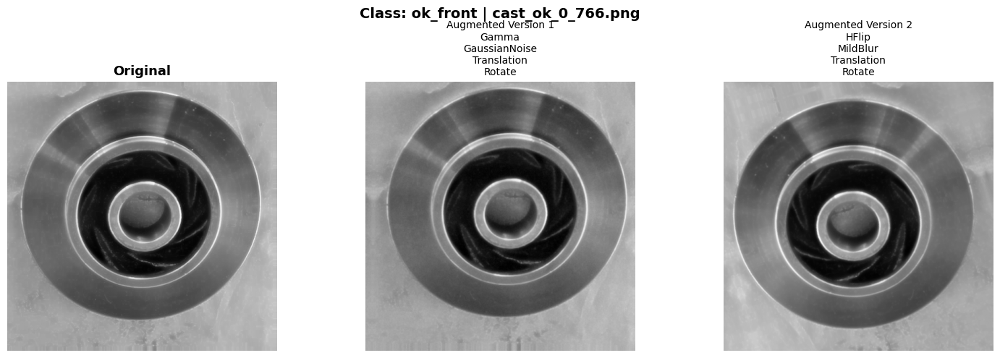


FINAL VERIFICATION
Original images     : 1,039
Augmented / original: 2
Expected total      : 3,117
Actually saved      : 3,117

Output path:
/kaggle/working/casting_train_augmented


In [5]:
# ============================================================
# TRAIN DATA AUGMENTATION
#
# For EACH original training image:
#   -> Generate 2 augmented images
#   -> Each augmented image uses 4 RANDOM augmentations
#
# Original images are ALSO copied to the output folder.
#
# Input:
# /kaggle/working/casting_512x512_split/train
#
# Output:
# /kaggle/working/casting_train_augmented
# ============================================================

import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm


# ============================================================
# 1. PATHS
# ============================================================

TRAIN_DIR = Path(
    "/kaggle/working/casting_512x512_split/train"
)

OUTPUT_DIR = Path(
    "/kaggle/working/casting_train_augmented"
)


# Remove old augmented folder if it exists
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. SETTINGS
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Two new images per original
AUGMENTED_PER_IMAGE = 2

# Four random operations for each augmented image
NUM_RANDOM_AUGS = 4

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


# ============================================================
# 3. AUGMENTATION FUNCTIONS
# ============================================================

# ------------------------------------------------------------
# Horizontal flip
# ------------------------------------------------------------

def horizontal_flip(img):

    return cv2.flip(
        img,
        1
    )


# ------------------------------------------------------------
# Vertical flip
# ------------------------------------------------------------

def vertical_flip(img):

    return cv2.flip(
        img,
        0
    )


# ------------------------------------------------------------
# Random rotation
# Mild rotation: -20 to +20 degrees
# ------------------------------------------------------------

def random_rotation(img):

    h, w = img.shape[:2]

    angle = random.uniform(
        -20,
        20
    )

    matrix = cv2.getRotationMatrix2D(
        (w / 2, h / 2),
        angle,
        1.0
    )

    rotated = cv2.warpAffine(
        img,
        matrix,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )

    return rotated


# ------------------------------------------------------------
# Brightness / Contrast
# ------------------------------------------------------------

def brightness_contrast(img):

    # Contrast
    alpha = random.uniform(
        0.85,
        1.15
    )

    # Brightness
    beta = random.randint(
        -15,
        15
    )

    result = cv2.convertScaleAbs(
        img,
        alpha=alpha,
        beta=beta
    )

    return result


# ------------------------------------------------------------
# Gamma adjustment
# ------------------------------------------------------------

def gamma_adjustment(img):

    gamma = random.uniform(
        0.85,
        1.15
    )

    table = np.array([
        ((i / 255.0) ** gamma) * 255
        for i in np.arange(256)
    ]).astype("uint8")

    return cv2.LUT(
        img,
        table
    )


# ------------------------------------------------------------
# Gaussian noise
# Very small noise only
# ------------------------------------------------------------

def gaussian_noise(img):

    sigma = random.uniform(
        2,
        6
    )

    noise = np.random.normal(
        0,
        sigma,
        img.shape
    )

    result = (
        img.astype(np.float32)
        + noise
    )

    return np.clip(
        result,
        0,
        255
    ).astype(np.uint8)


# ------------------------------------------------------------
# Mild Gaussian blur
# ------------------------------------------------------------

def mild_blur(img):

    return cv2.GaussianBlur(
        img,
        (3, 3),
        sigmaX=random.uniform(
            0.2,
            0.6
        )
    )


# ------------------------------------------------------------
# Small translation
# ------------------------------------------------------------

def random_translation(img):

    h, w = img.shape[:2]

    tx = random.uniform(
        -0.04,
        0.04
    ) * w

    ty = random.uniform(
        -0.04,
        0.04
    ) * h

    matrix = np.float32([
        [1, 0, tx],
        [0, 1, ty]
    ])

    result = cv2.warpAffine(
        img,
        matrix,
        (w, h),
        borderMode=cv2.BORDER_REFLECT_101
    )

    return result


# ============================================================
# 4. AUGMENTATION POOL
# ============================================================

AUGMENTATION_POOL = {

    "HFlip":
        horizontal_flip,

    "VFlip":
        vertical_flip,

    "Rotate":
        random_rotation,

    "BrightnessContrast":
        brightness_contrast,

    "Gamma":
        gamma_adjustment,

    "GaussianNoise":
        gaussian_noise,

    "MildBlur":
        mild_blur,

    "Translation":
        random_translation
}


print(
    "Available augmentations:"
)

for name in AUGMENTATION_POOL:
    print(" -", name)


# ============================================================
# 5. APPLY 4 RANDOM AUGMENTATIONS
# ============================================================

def apply_random_augmentations(
    image,
    num_aug=4
):

    # Randomly select 4 DIFFERENT transformations
    selected_names = random.sample(
        list(AUGMENTATION_POOL.keys()),
        num_aug
    )

    augmented = image.copy()

    # Apply sequentially
    for name in selected_names:

        function = AUGMENTATION_POOL[
            name
        ]

        augmented = function(
            augmented
        )

    return augmented, selected_names


# ============================================================
# 6. FIND TRAINING IMAGES
# ============================================================

train_images = sorted([
    p
    for p in TRAIN_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower()
    in IMAGE_EXTENSIONS
])


print("\n" + "=" * 65)
print("TRAINING DATA")
print("=" * 65)

print(
    f"Original training images: "
    f"{len(train_images):,}"
)


# ============================================================
# 7. DETECT CLASSES
# ============================================================

classes = sorted([
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
])

print(
    f"Classes detected: {classes}"
)


for class_name in classes:

    number = len([
        p
        for p in (
            TRAIN_DIR /
            class_name
        ).iterdir()
        if p.suffix.lower()
        in IMAGE_EXTENSIONS
    ])

    print(
        f"{class_name:<20}: "
        f"{number:,}"
    )


# ============================================================
# 8. COPY ORIGINAL + CREATE AUGMENTATIONS
# ============================================================

records = []

for image_path in tqdm(
    train_images,
    desc="Augmenting training data"
):

    # --------------------------------------------------------
    # Class
    # --------------------------------------------------------

    class_name = image_path.parent.name


    # --------------------------------------------------------
    # Destination class folder
    # --------------------------------------------------------

    class_output = (
        OUTPUT_DIR /
        class_name
    )

    class_output.mkdir(
        parents=True,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Read image
    # --------------------------------------------------------

    img = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:

        print(
            "Could not read:",
            image_path
        )

        continue


    # ========================================================
    # COPY ORIGINAL IMAGE
    # ========================================================

    original_output = (
        class_output /
        f"{image_path.stem}_original.png"
    )

    cv2.imwrite(
        str(original_output),
        img
    )


    records.append({
        "Class": class_name,
        "Type": "Original",
        "Filename":
            original_output.name,
        "Augmentations":
            "None"
    })


    # ========================================================
    # CREATE TWO AUGMENTED VERSIONS
    # ========================================================

    for version in range(
        1,
        AUGMENTED_PER_IMAGE + 1
    ):

        augmented_img, aug_names = (
            apply_random_augmentations(
                img,
                NUM_RANDOM_AUGS
            )
        )


        output_path = (
            class_output /
            (
                f"{image_path.stem}"
                f"_aug_v{version}.png"
            )
        )


        cv2.imwrite(
            str(output_path),
            augmented_img
        )


        records.append({

            "Class":
                class_name,

            "Type":
                f"Augmented V{version}",

            "Filename":
                output_path.name,

            "Augmentations":
                " + ".join(
                    aug_names
                )
        })


# ============================================================
# 9. DATAFRAME
# ============================================================

df_aug = pd.DataFrame(
    records
)


print("\n" + "=" * 65)
print("AUGMENTATION COMPLETED")
print("=" * 65)


print(
    f"Original train images : "
    f"{len(train_images):,}"
)

print(
    f"Augmented generated   : "
    f"{len(train_images) * AUGMENTED_PER_IMAGE:,}"
)

print(
    f"Total training images : "
    f"{len(df_aug):,}"
)


print(
    "\nSaved at:"
)

print(
    OUTPUT_DIR
)


# ============================================================
# 10. COUNT PER CLASS
# ============================================================

class_summary = (
    df_aug
    .groupby(
        ["Class", "Type"]
    )
    .size()
    .unstack(
        fill_value=0
    )
)


print("\nClass summary:")

display(
    class_summary
)


# ============================================================
# 11. FINAL CLASS COUNTS
# ============================================================

final_counts = (
    df_aug["Class"]
    .value_counts()
)


print("\nFinal number of training images:")

for class_name, count in (
    final_counts.items()
):

    print(
        f"{class_name:<20}: "
        f"{count:,}"
    )


# ============================================================
# 12. DISPLAY AUGMENTATION LOG
# ============================================================

print("\nExample augmentation records:")

display(
    df_aug[
        df_aug["Type"]
        != "Original"
    ].head(10)
)


# ============================================================
# 13. PLOT CLASS DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    final_counts.index,
    final_counts.values
)

plt.title(
    "Training Set After Augmentation",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Number of Images"
)


# Add numbers above bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        height,

        f"{int(height):,}",

        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()


# ============================================================
# 14. PLOT ORIGINAL + TWO AUGMENTED VERSIONS
# ============================================================

random.seed(100)

# Select examples from each class
SAMPLES_PER_CLASS = 2


for class_name in classes:

    class_images = [
        p for p in train_images
        if p.parent.name
        == class_name
    ]


    selected = random.sample(
        class_images,
        min(
            SAMPLES_PER_CLASS,
            len(class_images)
        )
    )


    for image_path in selected:

        img = cv2.imread(
            str(image_path),
            cv2.IMREAD_GRAYSCALE
        )


        # Version 1
        aug1, names1 = (
            apply_random_augmentations(
                img,
                NUM_RANDOM_AUGS
            )
        )


        # Version 2
        aug2, names2 = (
            apply_random_augmentations(
                img,
                NUM_RANDOM_AUGS
            )
        )


        # -----------------------------------------------
        # Plot
        # -----------------------------------------------

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(15, 5)
        )


        # Original
        axes[0].imshow(
            img,
            cmap="gray"
        )

        axes[0].set_title(
            "Original",
            fontsize=13,
            fontweight="bold"
        )

        axes[0].axis(
            "off"
        )


        # Augmented V1
        axes[1].imshow(
            aug1,
            cmap="gray"
        )

        axes[1].set_title(
            "Augmented Version 1\n"
            + "\n".join(names1),
            fontsize=10
        )

        axes[1].axis(
            "off"
        )


        # Augmented V2
        axes[2].imshow(
            aug2,
            cmap="gray"
        )

        axes[2].set_title(
            "Augmented Version 2\n"
            + "\n".join(names2),
            fontsize=10
        )

        axes[2].axis(
            "off"
        )


        plt.suptitle(
            f"Class: {class_name} | "
            f"{image_path.name}",
            fontsize=14,
            fontweight="bold"
        )


        plt.tight_layout()

        plt.show()


# ============================================================
# 15. FINAL CHECK
# ============================================================

saved_images = [
    p
    for p in OUTPUT_DIR.rglob("*.png")
]


expected = (
    len(train_images)
    *
    (
        1
        + AUGMENTED_PER_IMAGE
    )
)


print("\n" + "=" * 65)
print("FINAL VERIFICATION")
print("=" * 65)

print(
    f"Original images     : "
    f"{len(train_images):,}"
)

print(
    f"Augmented / original: "
    f"{AUGMENTED_PER_IMAGE}"
)

print(
    f"Expected total      : "
    f"{expected:,}"
)

print(
    f"Actually saved      : "
    f"{len(saved_images):,}"
)

print(
    "\nOutput path:"
)

print(
    OUTPUT_DIR
)


ENVIRONMENT
Device : cuda
PyTorch: 2.10.0+cu128
GPU    : Tesla T4
CUDA   : 12.8
GPU RAM: 14.56 GB

Dataset directories found.

DATASET
Classes: {'def_front': 0, 'ok_front': 1}
Train images : 3,117
Val images   : 129
Test images  : 132

Positive class: def_front

Training distribution:
def_front      : 1,872
ok_front       : 1,245

Class weights: [0.83253205 1.25180723]

Loaded ImageNet pretrained MaxViT-T.

FORWARD SHAPE CHECK
Logits: torch.Size([1, 2])
Scale gate: torch.Size([1, 3])

MODEL COMPLEXITY
Total parameters     : 30,535,752
Trainable parameters : 30,202,016
Frozen parameters    : 333,736
Total params (M)     : 30.536
Trainable params (M) : 30.202
FP32 model size      : 116.48 MB
GFLOPs @ 224x224: 11.283

TRAINING DEFECTMAXVIT-MSAF


Epoch 01/25 | Train Loss: 0.4694 | Val Loss: 0.2713 | Train Acc: 0.7895 | Val Acc: 0.9612 | Val F1: 0.9596
  -> Best checkpoint saved.


Epoch 02/25 | Train Loss: 0.2132 | Val Loss: 0.1777 | Train Acc: 0.9551 | Val Acc: 0.9845 | Val F1: 0.9839
  -> Best checkpoint saved.


Epoch 03/25 | Train Loss: 0.1586 | Val Loss: 0.1727 | Train Acc: 0.9849 | Val Acc: 0.9845 | Val F1: 0.9839
  -> No improvement: 1/2


Epoch 04/25 | Train Loss: 0.1437 | Val Loss: 0.1681 | Train Acc: 0.9929 | Val Acc: 0.9845 | Val F1: 0.9839
  -> No improvement: 2/2

Early stopping triggered.

TRAINING COMPLETED
Best epoch          : 2
Best validation F1  : 0.9839
Training time       : 4.20 minutes
Average sec/epoch   : 63.06
Peak GPU memory     : 1986.35 MB

Loaded best model from epoch: 2


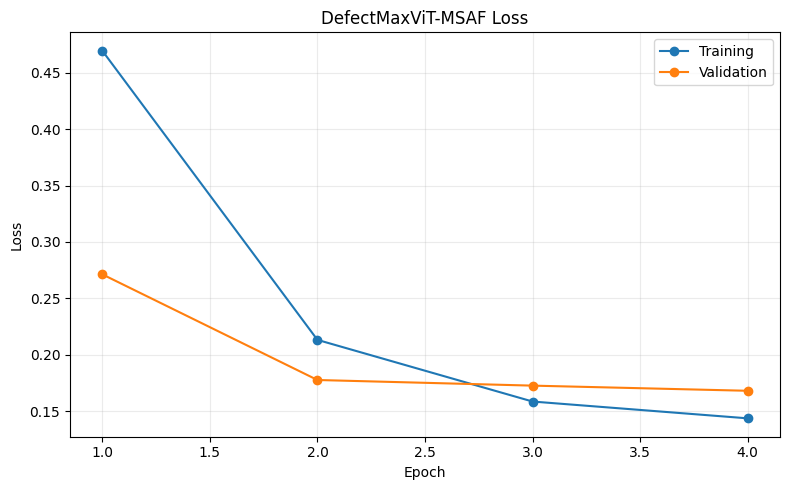

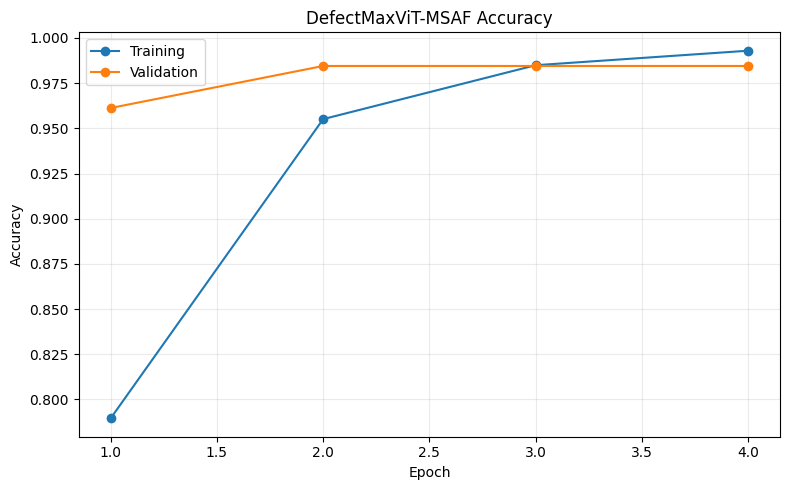

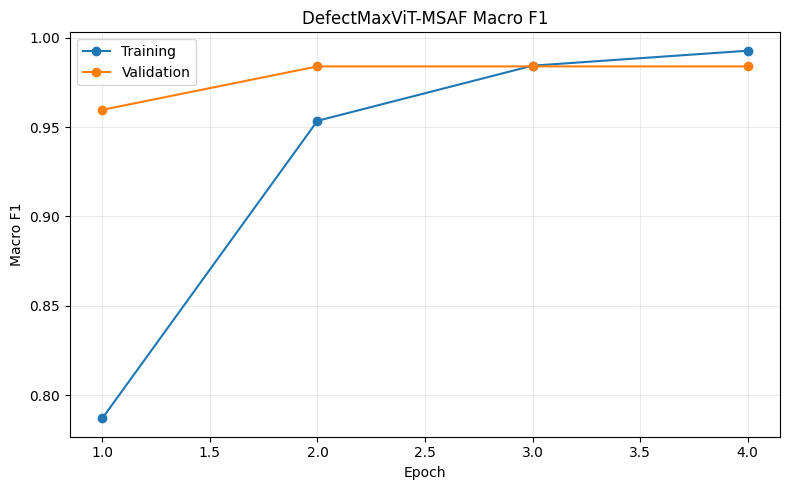

Independent test: 100%|███████████████████████████████████████████████| 9/9 [00:01<00:00,  5.15it/s]



INDEPENDENT TEST RESULTS
           Metric    Value
         Accuracy 0.992424
Balanced Accuracy 0.993671
        Precision 1.000000
      Sensitivity 0.987342
      Specificity 1.000000
         F1-score 0.993631
         Macro F1 0.992142
      Weighted F1 0.992436
              MCC 0.984407
      Cohen Kappa 0.984286
          ROC-AUC 1.000000
           PR-AUC 1.000000
              NPV 0.981481
      Brier Score 0.006339
              NLL 0.036187
              ECE 0.024713

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   def_front     1.0000    0.9873    0.9936        79
    ok_front     0.9815    1.0000    0.9907        53

    accuracy                         0.9924       132
   macro avg     0.9907    0.9937    0.9921       132
weighted avg     0.9926    0.9924    0.9924       132


Confusion matrix:
 [[78  1]
 [ 0 53]]


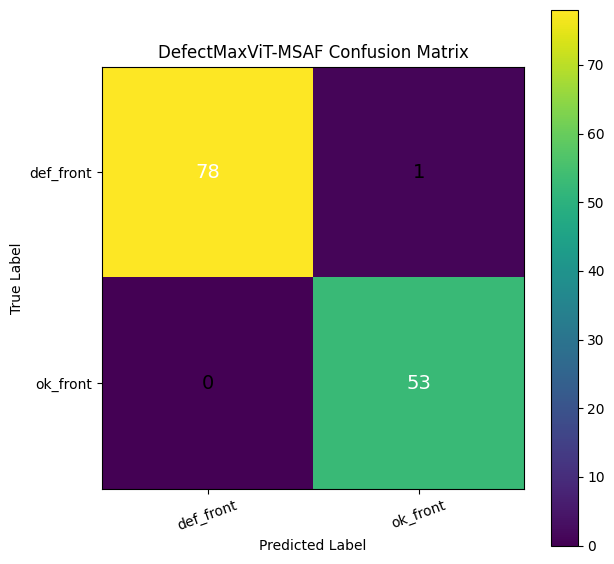

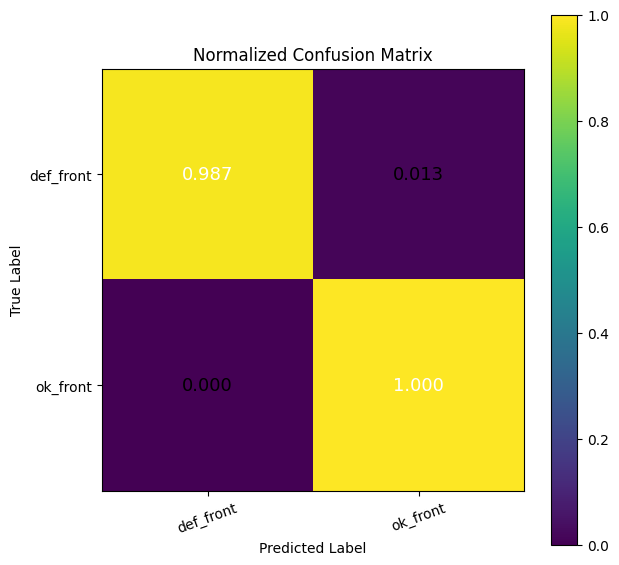

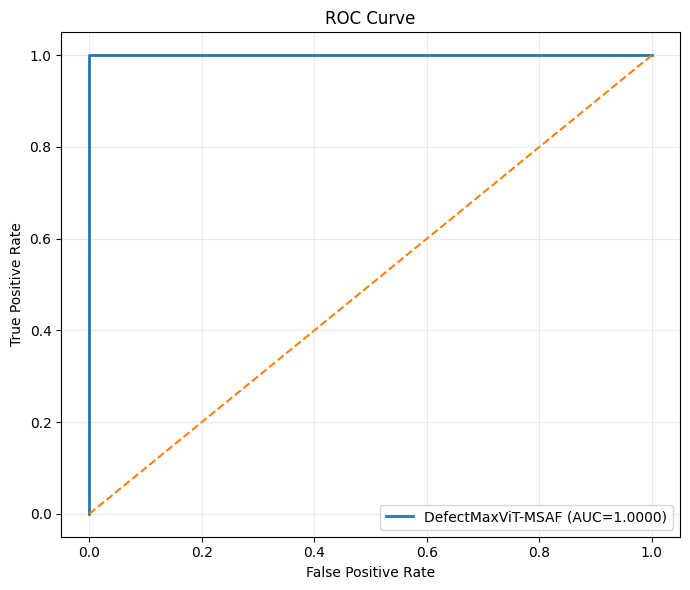

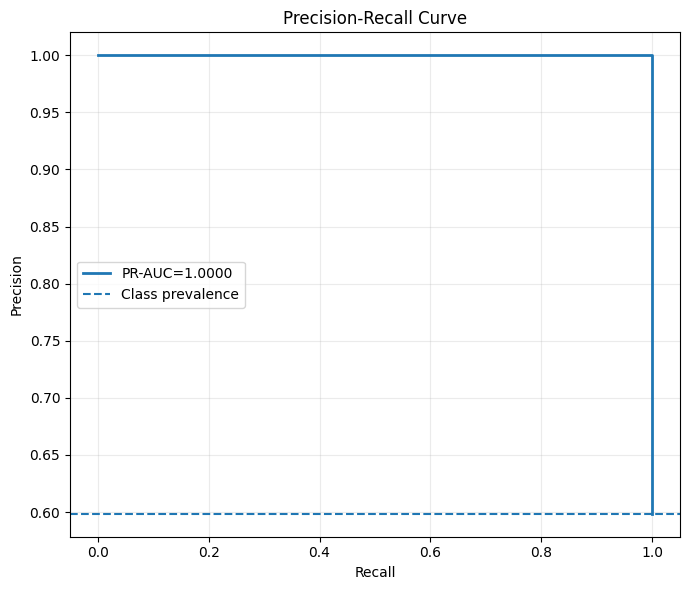

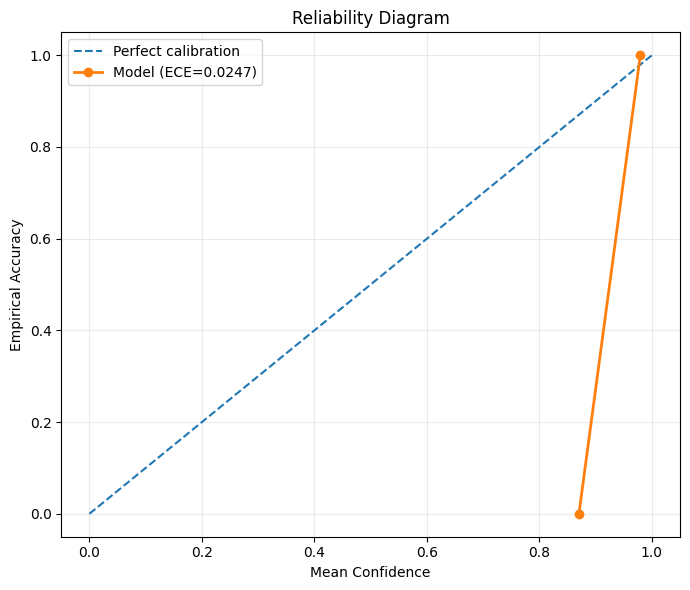

Bootstrap: 100%|███████████████████████████████████████████████| 1000/1000 [00:04<00:00, 206.88it/s]



BOOTSTRAP 95% CONFIDENCE INTERVAL
     Metric   Mean  CI Lower  CI Upper
   Accuracy 0.9925    0.9773       1.0
         F1 0.9936    0.9767       1.0
        MCC 0.9847    0.9492       1.0
    ROC-AUC 1.0000    1.0000       1.0
Sensitivity 0.9874    0.9545       1.0
Specificity 1.0000    1.0000       1.0

ADAPTIVE MULTI-SCALE CONTRIBUTION
 Feature Scale  Mean Weight    Std
MaxViT Block 1       0.2332 0.0268
MaxViT Block 2       0.5197 0.0367
MaxViT Block 3       0.2471 0.0125


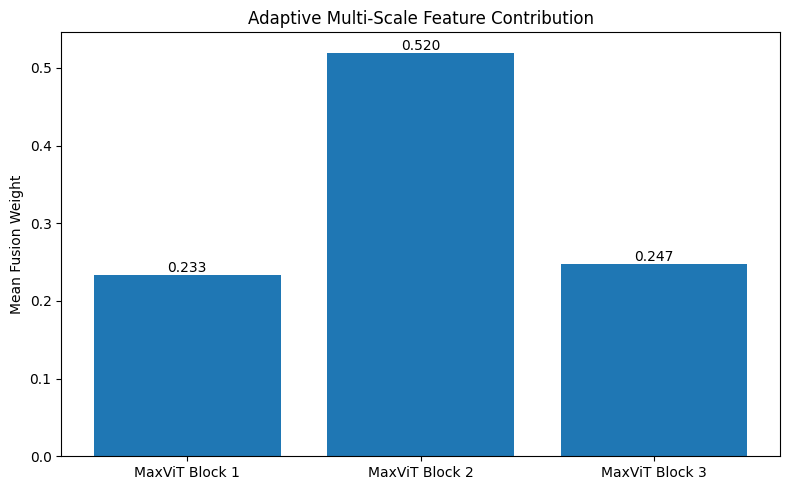


INFERENCE EFFICIENCY
 Batch  Latency_ms_image  Images_per_second  Peak_GPU_MB
     1            34.846             28.698      669.603
     8             4.553            219.656      737.848

ERROR ANALYSIS
Correct   : 131
Incorrect : 1

PAPER-READY SUMMARY
            Model   Input  Params_M  Trainable_M  GFLOPs  Accuracy  Balanced_Acc  Precision  Sensitivity  Specificity     F1  Macro_F1  ROC_AUC  PR_AUC    MCC  Kappa    ECE
DefectMaxViT-MSAF 224x224   30.5358       30.202 11.2831    0.9924        0.9937        1.0       0.9873          1.0 0.9936    0.9921      1.0     1.0 0.9844 0.9843 0.0247

DEFECTMAXVIT-MSAF FINAL RESULTS
Best Epoch           : 2
Best Val Macro-F1    : 0.9839
Total Parameters     : 30.536 M
Trainable Parameters : 30.202 M
GFLOPs               : 11.283
Model Size           : 116.48 MB
Accuracy             : 0.9924
Balanced Accuracy    : 0.9937
Precision            : 1.0000
Sensitivity          : 0.9873
Specificity          : 1.0000
F1-score             : 0.9936

In [ ]:
# ======================================================================
# DefectMaxViT-MSAF
# Modified MaxViT-T for Industrial Casting Defect Classification
#


# ======================================================================
# 1. IMPORTS
# ======================================================================

import os
import gc
import math
import time
import random
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.models import (
    maxvit_t,
    MaxVit_T_Weights
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    brier_score_loss,
    log_loss
)

from tqdm import tqdm


warnings.filterwarnings("ignore")


# ======================================================================
# 2. CONFIGURATION
# ======================================================================

TRAIN_DIR = Path(
    "/kaggle/working/casting_train_augmented"
)

VAL_DIR = Path(
    "/kaggle/working/casting_512x512_split/val"
)

TEST_DIR = Path(
    "/kaggle/working/casting_512x512_split/test"
)

RESULT_DIR = Path(
    "/kaggle/working/DefectMaxViT_MSAF_results"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SEED = 42

IMG_SIZE = 224

BATCH_SIZE = 16

EPOCHS = 25

BACKBONE_LR = 2e-5

HEAD_LR = 2e-4

WEIGHT_DECAY = 1e-4

LABEL_SMOOTHING = 0.05

DROPOUT = 0.4

GRAD_CLIP = 1.0

EARLY_STOPPING_PATIENCE = 2

NUM_WORKERS = 0

PROJECTION_DIM = 128

BOOTSTRAP_ITERATIONS = 1000

CALIBRATION_BINS = 15


# ======================================================================
# 3. REPRODUCIBILITY
# ======================================================================

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


try:
    torch.set_float32_matmul_precision("high")
except:
    pass


# ======================================================================
# 4. DEVICE
# ======================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = (
    DEVICE.type == "cuda"
)


print("\n" + "=" * 75)
print("ENVIRONMENT")
print("=" * 75)

print("Device :", DEVICE)

print(
    "PyTorch:",
    torch.__version__
)

if torch.cuda.is_available():

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA   :",
        torch.version.cuda
    )

    print(
        "GPU RAM:",
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )


# ======================================================================
# 5. CHECK PATHS
# ======================================================================

for path in [
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
]:

    if not path.exists():

        raise FileNotFoundError(
            f"Missing directory:\n{path}"
        )


print(
    "\nDataset directories found."
)


# ======================================================================
# 6. TRANSFORMS
#
# MaxViT pretrained weights expect ImageNet-like 3-channel input.
# Grayscale casting images are replicated into 3 channels.
#
# Offline augmentation has already been performed.
# ======================================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


# ======================================================================
# 7. DATASETS
# ======================================================================

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)


assert (
    train_dataset.class_to_idx
    ==
    val_dataset.class_to_idx
    ==
    test_dataset.class_to_idx
), "Class mapping mismatch."


CLASS_NAMES = (
    train_dataset.classes
)

NUM_CLASSES = len(
    CLASS_NAMES
)


print("\n" + "=" * 75)
print("DATASET")
print("=" * 75)

print(
    "Classes:",
    train_dataset.class_to_idx
)

print(
    f"Train images : {len(train_dataset):,}"
)

print(
    f"Val images   : {len(val_dataset):,}"
)

print(
    f"Test images  : {len(test_dataset):,}"
)


# ======================================================================
# 8. POSITIVE CLASS
# ======================================================================

DEFECT_IDX = None


for name, index in (
    train_dataset.class_to_idx.items()
):

    if (
        "def" in name.lower()
        or
        "defect" in name.lower()
    ):

        DEFECT_IDX = index

        break


if DEFECT_IDX is None:

    raise ValueError(
        "Could not detect defect class."
    )


print(
    "\nPositive class:",
    CLASS_NAMES[DEFECT_IDX]
)


# ======================================================================
# 9. CLASS DISTRIBUTION
# ======================================================================

train_targets = np.array(
    train_dataset.targets
)

class_counts = np.bincount(
    train_targets,
    minlength=NUM_CLASSES
)


print("\nTraining distribution:")


for i, name in enumerate(
    CLASS_NAMES
):

    print(
        f"{name:<15}: "
        f"{class_counts[i]:,}"
    )


# ======================================================================
# 10. CLASS WEIGHTS
# ======================================================================

class_weights_np = (

    len(train_dataset)

    /

    (
        NUM_CLASSES
        *
        class_counts
    )
)


class_weights = torch.tensor(

    class_weights_np,

    dtype=torch.float32,

    device=DEVICE
)


print(
    "\nClass weights:",
    class_weights_np
)


# ======================================================================
# 11. LOADERS
# ======================================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=USE_AMP
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=USE_AMP
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=USE_AMP
)


# ======================================================================
# 12. FEATURE PROJECTION BLOCK
# ======================================================================

class ProjectionBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()


        self.block = nn.Sequential(

            nn.Conv2d(

                in_channels,

                out_channels,

                kernel_size=1,

                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.SiLU(
                inplace=True
            )
        )


    def forward(
        self,
        x
    ):

        return self.block(x)


# ======================================================================
# 13. MULTI-KERNEL DEFECT ENHANCEMENT
#
# Parallel:
# 3x3
# 5x5
# 7x7
#
# Useful for different defect sizes.
# ======================================================================

class MultiKernelDefectEnhancement(
    nn.Module
):

    def __init__(
        self,
        channels
    ):

        super().__init__()


        self.dw3 = nn.Conv2d(

            channels,
            channels,

            kernel_size=3,

            padding=1,

            groups=channels,

            bias=False
        )


        self.dw5 = nn.Conv2d(

            channels,
            channels,

            kernel_size=5,

            padding=2,

            groups=channels,

            bias=False
        )


        self.dw7 = nn.Conv2d(

            channels,
            channels,

            kernel_size=7,

            padding=3,

            groups=channels,

            bias=False
        )


        self.fusion = nn.Sequential(

            nn.Conv2d(

                channels * 3,

                channels,

                kernel_size=1,

                bias=False
            ),

            nn.BatchNorm2d(
                channels
            ),

            nn.SiLU()
        )


    def forward(
        self,
        x
    ):

        f3 = self.dw3(x)

        f5 = self.dw5(x)

        f7 = self.dw7(x)


        combined = torch.cat(
            [
                f3,
                f5,
                f7
            ],
            dim=1
        )


        enhanced = self.fusion(
            combined
        )


        return (
            x
            +
            enhanced
        )


# ======================================================================
# 14. LITE CHANNEL ATTENTION
# ======================================================================

class ChannelAttention(
    nn.Module
):

    def __init__(
        self,
        channels,
        reduction=8
    ):

        super().__init__()


        hidden = max(
            channels // reduction,
            16
        )


        self.mlp = nn.Sequential(

            nn.Conv2d(
                channels,
                hidden,
                1,
                bias=False
            ),

            nn.SiLU(),

            nn.Conv2d(
                hidden,
                channels,
                1,
                bias=False
            )
        )


    def forward(
        self,
        x
    ):

        avg = (
            F.adaptive_avg_pool2d(
                x,
                1
            )
        )


        max_pool = (
            F.adaptive_max_pool2d(
                x,
                1
            )
        )


        attention = torch.sigmoid(

            self.mlp(avg)

            +

            self.mlp(
                max_pool
            )
        )


        return (
            x
            *
            attention
        )


# ======================================================================
# 15. MULTI-KERNEL SPATIAL ATTENTION
# ======================================================================

class MultiKernelSpatialAttention(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()


        self.conv3 = nn.Conv2d(
            2,
            1,
            kernel_size=3,
            padding=1,
            bias=False
        )


        self.conv5 = nn.Conv2d(
            2,
            1,
            kernel_size=5,
            padding=2,
            bias=False
        )


        self.conv7 = nn.Conv2d(
            2,
            1,
            kernel_size=7,
            padding=3,
            bias=False
        )


        self.fusion = nn.Conv2d(
            3,
            1,
            kernel_size=1,
            bias=False
        )


    def forward(
        self,
        x
    ):

        avg = torch.mean(
            x,
            dim=1,
            keepdim=True
        )


        maximum, _ = torch.max(
            x,
            dim=1,
            keepdim=True
        )


        descriptor = torch.cat(
            [
                avg,
                maximum
            ],
            dim=1
        )


        s3 = self.conv3(
            descriptor
        )


        s5 = self.conv5(
            descriptor
        )


        s7 = self.conv7(
            descriptor
        )


        attention = torch.sigmoid(

            self.fusion(

                torch.cat(
                    [
                        s3,
                        s5,
                        s7
                    ],
                    dim=1
                )
            )
        )


        return (
            x
            *
            attention
        )


# ======================================================================
# 16. DEFECT ATTENTION MODULE
# ======================================================================

class DefectAttentionBlock(
    nn.Module
):

    def __init__(
        self,
        channels
    ):

        super().__init__()


        self.detail = (
            MultiKernelDefectEnhancement(
                channels
            )
        )


        self.channel_attention = (
            ChannelAttention(
                channels
            )
        )


        self.spatial_attention = (
            MultiKernelSpatialAttention()
        )


    def forward(
        self,
        x
    ):

        identity = x


        x = self.detail(x)

        x = self.channel_attention(
            x
        )

        x = self.spatial_attention(
            x
        )


        return (
            identity
            +
            x
        )


# ======================================================================
# 17. ADAPTIVE MULTI-SCALE FUSION
# ======================================================================

class AdaptiveScaleFusion(
    nn.Module
):

    def __init__(
        self,
        feature_dim,
        num_scales=3,
        dropout=0.2
    ):

        super().__init__()


        self.num_scales = (
            num_scales
        )


        self.gate = nn.Sequential(

            nn.Linear(
                feature_dim * num_scales,
                feature_dim
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                feature_dim,
                num_scales
            )
        )


    def forward(
        self,
        features
    ):

        # features:
        # list of [B, D]

        concatenated = torch.cat(
            features,
            dim=1
        )


        weights = torch.softmax(

            self.gate(
                concatenated
            ),

            dim=1
        )


        stacked = torch.stack(
            features,
            dim=1
        )


        fused = (

            stacked

            *

            weights.unsqueeze(-1)

        ).sum(
            dim=1
        )


        return (
            fused,
            weights
        )


# ======================================================================
# 18. MODIFIED MAXVIT MODEL
# ======================================================================

class DefectMaxViTMSAF(
    nn.Module
):

    def __init__(
        self,
        num_classes=2,
        projection_dim=128,
        dropout=0.35,
        pretrained=True
    ):

        super().__init__()


        # --------------------------------------------------------------
        # Load pretrained MaxViT-T
        # --------------------------------------------------------------

        if pretrained:

            try:

                weights = (
                    MaxVit_T_Weights.DEFAULT
                )


                backbone = maxvit_t(
                    weights=weights
                )


                print(
                    "\nLoaded ImageNet pretrained MaxViT-T."
                )


            except Exception as e:

                print(
                    "\nCould not load pretrained weights."
                )

                print(
                    "Reason:",
                    str(e)[:200]
                )

                print(
                    "Using randomly initialized MaxViT-T."
                )


                backbone = maxvit_t(
                    weights=None
                )

        else:

            backbone = maxvit_t(
                weights=None
            )


        # --------------------------------------------------------------
        # Reuse MaxViT feature extractor
        # --------------------------------------------------------------

        self.stem = (
            backbone.stem
        )


        self.blocks = (
            backbone.blocks
        )


        # Original classifier is not used.
        del backbone


        # --------------------------------------------------------------
        # MaxViT-T feature dimensions:
        #
        # block 0 -> 64 channels
        # block 1 -> 128 channels
        # block 2 -> 256 channels
        # block 3 -> 512 channels
        #
        # We use stages 1,2,3.
        # --------------------------------------------------------------

        self.proj1 = ProjectionBlock(
            128,
            projection_dim
        )

        self.proj2 = ProjectionBlock(
            256,
            projection_dim
        )

        self.proj3 = ProjectionBlock(
            512,
            projection_dim
        )


        # --------------------------------------------------------------
        # Defect-aware attention at each scale
        # --------------------------------------------------------------

        self.att1 = DefectAttentionBlock(
            projection_dim
        )

        self.att2 = DefectAttentionBlock(
            projection_dim
        )

        self.att3 = DefectAttentionBlock(
            projection_dim
        )


        # --------------------------------------------------------------
        # Adaptive fusion
        # --------------------------------------------------------------

        self.scale_fusion = (
            AdaptiveScaleFusion(

                feature_dim=projection_dim,

                num_scales=3,

                dropout=0.20
            )
        )


        # --------------------------------------------------------------
        # Classification head
        # --------------------------------------------------------------

        self.classifier = nn.Sequential(

            nn.LayerNorm(
                projection_dim
            ),

            nn.Linear(
                projection_dim,
                256
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                256,
                num_classes
            )
        )


        # --------------------------------------------------------------
        # Freeze stem + first MaxViT stage
        # --------------------------------------------------------------

        for parameter in (
            self.stem.parameters()
        ):

            parameter.requires_grad = False


        for parameter in (
            self.blocks[0].parameters()
        ):

            parameter.requires_grad = False


    @staticmethod
    def pool(
        x
    ):

        return (

            F.adaptive_avg_pool2d(
                x,
                1
            )

            .flatten(1)
        )


    def forward_features(
        self,
        x
    ):

        # Stem
        x = self.stem(
            x
        )


        # MaxViT stage 0
        x = self.blocks[0](
            x
        )


        # --------------------------------------------------------------
        # Scale 1
        # --------------------------------------------------------------

        x1 = self.blocks[1](
            x
        )


        # --------------------------------------------------------------
        # Scale 2
        # --------------------------------------------------------------

        x2 = self.blocks[2](
            x1
        )


        # --------------------------------------------------------------
        # Scale 3
        # --------------------------------------------------------------

        x3 = self.blocks[3](
            x2
        )


        # --------------------------------------------------------------
        # Channel projection
        # --------------------------------------------------------------

        p1 = self.proj1(
            x1
        )

        p2 = self.proj2(
            x2
        )

        p3 = self.proj3(
            x3
        )


        # --------------------------------------------------------------
        # Defect-aware enhancement
        # --------------------------------------------------------------

        p1 = self.att1(
            p1
        )

        p2 = self.att2(
            p2
        )

        p3 = self.att3(
            p3
        )


        # --------------------------------------------------------------
        # Global pooling
        # --------------------------------------------------------------

        g1 = self.pool(
            p1
        )

        g2 = self.pool(
            p2
        )

        g3 = self.pool(
            p3
        )


        # --------------------------------------------------------------
        # Adaptive multi-scale fusion
        # --------------------------------------------------------------

        fused, scale_weights = (
            self.scale_fusion(
                [
                    g1,
                    g2,
                    g3
                ]
            )
        )


        return (
            fused,
            scale_weights
        )


    def forward(
        self,
        x,
        return_scale_weights=False
    ):

        fused, weights = (
            self.forward_features(
                x
            )
        )


        logits = self.classifier(
            fused
        )


        if return_scale_weights:

            return (
                logits,
                weights
            )


        return logits


# ======================================================================
# 19. CREATE MODEL
# ======================================================================

model = DefectMaxViTMSAF(

    num_classes=NUM_CLASSES,

    projection_dim=PROJECTION_DIM,

    dropout=DROPOUT,

    pretrained=True

).to(
    DEVICE
)


# ======================================================================
# 20. CHECK FEATURE DIMENSIONS
# ======================================================================

print("\n" + "=" * 75)
print("FORWARD SHAPE CHECK")
print("=" * 75)


with torch.no_grad():

    dummy = torch.randn(

        1,
        3,
        IMG_SIZE,
        IMG_SIZE,

        device=DEVICE
    )


    output, gate = model(

        dummy,

        return_scale_weights=True
    )


print(
    "Logits:",
    output.shape
)

print(
    "Scale gate:",
    gate.shape
)


# ======================================================================
# 21. PARAMETERS
# ======================================================================

TOTAL_PARAMS = sum(

    parameter.numel()

    for parameter in model.parameters()
)


TRAINABLE_PARAMS = sum(

    parameter.numel()

    for parameter in model.parameters()

    if parameter.requires_grad
)


FROZEN_PARAMS = (

    TOTAL_PARAMS

    -

    TRAINABLE_PARAMS
)


MODEL_SIZE_MB = (

    TOTAL_PARAMS

    *
    4

    /

    1024**2
)


print("\n" + "=" * 75)
print("MODEL COMPLEXITY")
print("=" * 75)

print(
    f"Total parameters     : {TOTAL_PARAMS:,}"
)

print(
    f"Trainable parameters : {TRAINABLE_PARAMS:,}"
)

print(
    f"Frozen parameters    : {FROZEN_PARAMS:,}"
)

print(
    f"Total params (M)     : {TOTAL_PARAMS / 1e6:.3f}"
)

print(
    f"Trainable params (M) : {TRAINABLE_PARAMS / 1e6:.3f}"
)

print(
    f"FP32 model size      : {MODEL_SIZE_MB:.2f} MB"
)


# ======================================================================
# 22. FLOPs
# ======================================================================

def calculate_flops(
    model
):

    dummy = torch.randn(

        1,
        3,
        IMG_SIZE,
        IMG_SIZE,

        device=DEVICE
    )


    try:

        from torch.utils.flop_counter import (
            FlopCounterMode
        )


        model.eval()


        with torch.inference_mode():

            with FlopCounterMode(
                display=False
            ) as counter:

                _ = model(
                    dummy
                )


        return float(
            counter.get_total_flops()
        )


    except Exception as e:

        print(
            "FLOP counter unavailable:",
            str(e)[:200]
        )


        return np.nan


FLOPS = calculate_flops(
    model
)


if np.isfinite(
    FLOPS
):

    print(
        f"GFLOPs @ {IMG_SIZE}x{IMG_SIZE}: "
        f"{FLOPS / 1e9:.3f}"
    )


# ======================================================================
# 23. LOSS
# ======================================================================

criterion = nn.CrossEntropyLoss(

    weight=class_weights,

    label_smoothing=LABEL_SMOOTHING
)


# ======================================================================
# 24. PARAMETER GROUPS
#
# Lower LR for pretrained MaxViT.
# Higher LR for proposed modules.
# ======================================================================

backbone_parameters = []

head_parameters = []


for name, parameter in (
    model.named_parameters()
):

    if not parameter.requires_grad:

        continue


    if (
        name.startswith(
            "blocks"
        )
        or
        name.startswith(
            "stem"
        )
    ):

        backbone_parameters.append(
            parameter
        )

    else:

        head_parameters.append(
            parameter
        )


optimizer = torch.optim.AdamW(

    [
        {
            "params":
                backbone_parameters,

            "lr":
                BACKBONE_LR
        },

        {
            "params":
                head_parameters,

            "lr":
                HEAD_LR
        }
    ],

    weight_decay=WEIGHT_DECAY
)


# ======================================================================
# 25. SCHEDULER
# ======================================================================

scheduler = (
    torch.optim.lr_scheduler.OneCycleLR(

        optimizer,

        max_lr=[
            BACKBONE_LR,
            HEAD_LR
        ],

        epochs=EPOCHS,

        steps_per_epoch=len(
            train_loader
        ),

        pct_start=0.10,

        anneal_strategy="cos",

        div_factor=5.0,

        final_div_factor=100.0
    )
)


# ======================================================================
# 26. AMP SCALER
# ======================================================================

scaler = torch.amp.GradScaler(

    "cuda",

    enabled=USE_AMP
)


# ======================================================================
# 27. TRAIN ONE EPOCH
# ======================================================================

def train_one_epoch(
    model,
    loader
):

    model.train()


    running_loss = 0.0


    targets_all = []

    predictions_all = []


    progress = tqdm(

        loader,

        desc="Training",

        ncols=100,

        leave=False
    )


    for images, targets in progress:

        images = images.to(

            DEVICE,

            non_blocking=True
        )


        targets = targets.to(

            DEVICE,

            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=USE_AMP
        ):

            logits = model(
                images
            )


            loss = criterion(
                logits,
                targets
            )


        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            GRAD_CLIP
        )


        scaler.step(
            optimizer
        )


        scaler.update()


        scheduler.step()


        running_loss += (

            loss.item()

            *

            images.size(0)
        )


        predictions = torch.argmax(
            logits,
            dim=1
        )


        targets_all.extend(

            targets.detach()
            .cpu()
            .tolist()
        )


        predictions_all.extend(

            predictions.detach()
            .cpu()
            .tolist()
        )


    epoch_loss = (

        running_loss

        /

        len(loader.dataset)
    )


    accuracy = accuracy_score(

        targets_all,

        predictions_all
    )


    macro_f1 = f1_score(

        targets_all,

        predictions_all,

        average="macro",

        zero_division=0
    )


    return {
        "loss":
            epoch_loss,

        "accuracy":
            accuracy,

        "macro_f1":
            macro_f1
    }


# ======================================================================
# 28. VALIDATE
# ======================================================================

@torch.inference_mode()
def validate_model(
    model,
    loader
):

    model.eval()


    running_loss = 0.0


    targets_all = []

    predictions_all = []


    for images, targets in tqdm(

        loader,

        desc="Validation",

        ncols=100,

        leave=False
    ):

        images = images.to(

            DEVICE,

            non_blocking=True
        )


        targets = targets.to(

            DEVICE,

            non_blocking=True
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=USE_AMP
        ):

            logits = model(
                images
            )


            loss = criterion(
                logits,
                targets
            )


        running_loss += (

            loss.item()

            *

            images.size(0)
        )


        predictions = torch.argmax(
            logits,
            dim=1
        )


        targets_all.extend(

            targets.cpu()
            .tolist()
        )


        predictions_all.extend(

            predictions.cpu()
            .tolist()
        )


    val_loss = (

        running_loss

        /

        len(loader.dataset)
    )


    val_accuracy = (
        accuracy_score(

            targets_all,

            predictions_all
        )
    )


    val_macro_f1 = (
        f1_score(

            targets_all,

            predictions_all,

            average="macro",

            zero_division=0
        )
    )


    return {

        "loss":
            val_loss,

        "accuracy":
            val_accuracy,

        "macro_f1":
            val_macro_f1
    }


# ======================================================================
# 29. TRAINING
# ======================================================================

CHECKPOINT_PATH = (

    RESULT_DIR

    /

    "best_DefectMaxViT_MSAF.pth"
)


history = []


best_val_f1 = (
    -float("inf")
)


best_epoch = 0

patience_counter = 0


print("\n" + "=" * 75)
print("TRAINING DEFECTMAXVIT-MSAF")
print("=" * 75)


if DEVICE.type == "cuda":

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()

    torch.cuda.synchronize()


start_time = time.perf_counter()


for epoch in range(
    1,
    EPOCHS + 1
):


    train_metrics = train_one_epoch(

        model,

        train_loader
    )


    val_metrics = validate_model(

        model,

        val_loader
    )


    history.append({

        "epoch":
            epoch,

        "train_loss":
            train_metrics["loss"],

        "val_loss":
            val_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "val_accuracy":
            val_metrics["accuracy"],

        "train_macro_f1":
            train_metrics["macro_f1"],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "backbone_lr":
            optimizer.param_groups[0]["lr"],

        "head_lr":
            optimizer.param_groups[1]["lr"]
    })


    print(

        f"Epoch {epoch:02d}/{EPOCHS} | "

        f"Train Loss: "
        f"{train_metrics['loss']:.4f} | "

        f"Val Loss: "
        f"{val_metrics['loss']:.4f} | "

        f"Train Acc: "
        f"{train_metrics['accuracy']:.4f} | "

        f"Val Acc: "
        f"{val_metrics['accuracy']:.4f} | "

        f"Val F1: "
        f"{val_metrics['macro_f1']:.4f}"
    )


    # --------------------------------------------------------------
    # Best validation macro-F1 checkpoint
    # --------------------------------------------------------------

    if (
        val_metrics[
            "macro_f1"
        ]
        >
        best_val_f1
    ):

        best_val_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )


        best_epoch = epoch


        patience_counter = 0


        torch.save({

            "model_state_dict":
                model.state_dict(),

            "epoch":
                best_epoch,

            "best_val_macro_f1":
                best_val_f1,

            "class_to_idx":
                train_dataset.class_to_idx,

            "classes":
                CLASS_NAMES,

            "img_size":
                IMG_SIZE,

            "projection_dim":
                PROJECTION_DIM

        }, CHECKPOINT_PATH)


        print(
            "  -> Best checkpoint saved."
        )


    else:

        patience_counter += 1


        print(

            f"  -> No improvement: "
            f"{patience_counter}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )


    if (
        patience_counter
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


if DEVICE.type == "cuda":

    torch.cuda.synchronize()


TRAINING_TIME = (

    time.perf_counter()

    -

    start_time
)


if DEVICE.type == "cuda":

    PEAK_TRAIN_MEMORY = (

        torch.cuda
        .max_memory_allocated()

        /

        1024**2
    )

else:

    PEAK_TRAIN_MEMORY = (
        np.nan
    )


print("\n" + "=" * 75)
print("TRAINING COMPLETED")
print("=" * 75)

print(
    f"Best epoch          : {best_epoch}"
)

print(
    f"Best validation F1  : {best_val_f1:.4f}"
)

print(
    f"Training time       : "
    f"{TRAINING_TIME / 60:.2f} minutes"
)

print(
    f"Average sec/epoch   : "
    f"{TRAINING_TIME / len(history):.2f}"
)


if np.isfinite(
    PEAK_TRAIN_MEMORY
):

    print(
        f"Peak GPU memory     : "
        f"{PEAK_TRAIN_MEMORY:.2f} MB"
    )


# ======================================================================
# 30. SAVE HISTORY
# ======================================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(

    RESULT_DIR /
    "training_history.csv",

    index=False
)


# ======================================================================
# 31. LOAD BEST MODEL
# ======================================================================

checkpoint = torch.load(

    CHECKPOINT_PATH,

    map_location=DEVICE,

    weights_only=False
)


model.load_state_dict(

    checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print(
    "\nLoaded best model from epoch:",
    checkpoint["epoch"]
)


# ======================================================================
# 32. LEARNING CURVES
# ======================================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    history_df["epoch"],

    history_df["train_loss"],

    marker="o",

    label="Training"
)


plt.plot(

    history_df["epoch"],

    history_df["val_loss"],

    marker="o",

    label="Validation"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "DefectMaxViT-MSAF Loss"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "loss_curve.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


plt.figure(
    figsize=(8, 5)
)


plt.plot(

    history_df["epoch"],

    history_df["train_accuracy"],

    marker="o",

    label="Training"
)


plt.plot(

    history_df["epoch"],

    history_df["val_accuracy"],

    marker="o",

    label="Validation"
)


plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "DefectMaxViT-MSAF Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "accuracy_curve.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


plt.figure(
    figsize=(8, 5)
)


plt.plot(

    history_df["epoch"],

    history_df["train_macro_f1"],

    marker="o",

    label="Training"
)


plt.plot(

    history_df["epoch"],

    history_df["val_macro_f1"],

    marker="o",

    label="Validation"
)


plt.xlabel("Epoch")

plt.ylabel("Macro F1")

plt.title(
    "DefectMaxViT-MSAF Macro F1"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "f1_curve.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 33. TEST INFERENCE
# ======================================================================

@torch.inference_mode()
def predict_dataset(
    model,
    loader
):

    model.eval()


    all_targets = []

    all_probabilities = []

    all_scale_weights = []

    all_paths = []


    running_index = 0


    for images, targets in tqdm(

        loader,

        desc="Independent test",

        ncols=100
    ):

        images = images.to(

            DEVICE,

            non_blocking=True
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=USE_AMP
        ):

            logits, weights = model(

                images,

                return_scale_weights=True
            )


        probabilities = (

            torch.softmax(

                logits.float(),

                dim=1
            )

            .cpu()
            .numpy()
        )


        all_targets.append(
            targets.numpy()
        )


        all_probabilities.append(
            probabilities
        )


        all_scale_weights.append(

            weights.float()
            .cpu()
            .numpy()
        )


        batch_size = (
            len(targets)
        )


        for i in range(
            batch_size
        ):

            all_paths.append(

                loader.dataset.samples[
                    running_index + i
                ][0]
            )


        running_index += (
            batch_size
        )


    return (

        np.concatenate(
            all_targets
        ),

        np.concatenate(
            all_probabilities
        ),

        np.concatenate(
            all_scale_weights
        ),

        all_paths
    )


(
    y_true,
    y_prob,
    scale_weights,
    test_paths

) = predict_dataset(

    model,

    test_loader
)


y_pred = np.argmax(
    y_prob,
    axis=1
)


# ======================================================================
# 34. DEFECT BINARY REPRESENTATION
# ======================================================================

y_true_binary = (

    y_true
    ==
    DEFECT_IDX

).astype(int)


y_pred_binary = (

    y_pred
    ==
    DEFECT_IDX

).astype(int)


p_defect = y_prob[
    :,
    DEFECT_IDX
]


# ======================================================================
# 35. CONFUSION VALUES
# ======================================================================

binary_cm = confusion_matrix(

    y_true_binary,

    y_pred_binary,

    labels=[
        0,
        1
    ]
)


tn, fp, fn, tp = (
    binary_cm.ravel()
)


sensitivity = (

    tp
    /
    (tp + fn)

    if (
        tp + fn
    ) > 0

    else 0
)


specificity = (

    tn
    /
    (tn + fp)

    if (
        tn + fp
    ) > 0

    else 0
)


npv = (

    tn
    /
    (tn + fn)

    if (
        tn + fn
    ) > 0

    else 0
)


# ======================================================================
# 36. ECE
# ======================================================================

def calculate_ece(
    probabilities,
    labels,
    n_bins=15
):

    confidence = np.max(
        probabilities,
        axis=1
    )


    predictions = np.argmax(
        probabilities,
        axis=1
    )


    correct = (

        predictions
        ==
        labels

    ).astype(float)


    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )


    ece = 0.0


    for i in range(
        n_bins
    ):

        if i == 0:

            mask = (

                confidence
                >=
                edges[i]

            ) & (

                confidence
                <=
                edges[i + 1]
            )

        else:

            mask = (

                confidence
                >
                edges[i]

            ) & (

                confidence
                <=
                edges[i + 1]
            )


        if mask.sum() == 0:

            continue


        accuracy_bin = (
            correct[
                mask
            ].mean()
        )


        confidence_bin = (
            confidence[
                mask
            ].mean()
        )


        ece += (

            mask.mean()

            *

            abs(
                accuracy_bin
                -
                confidence_bin
            )
        )


    return float(
        ece
    )


ECE = calculate_ece(

    y_prob,

    y_true,

    CALIBRATION_BINS
)


# ======================================================================
# 37. METRICS
# ======================================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)


balanced_accuracy = (
    balanced_accuracy_score(
        y_true,
        y_pred
    )
)


precision = precision_score(

    y_true_binary,

    y_pred_binary,

    zero_division=0
)


recall = recall_score(

    y_true_binary,

    y_pred_binary,

    zero_division=0
)


f1 = f1_score(

    y_true_binary,

    y_pred_binary,

    zero_division=0
)


macro_f1 = f1_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0
)


weighted_f1 = f1_score(

    y_true,

    y_pred,

    average="weighted",

    zero_division=0
)


mcc = matthews_corrcoef(
    y_true,
    y_pred
)


kappa = cohen_kappa_score(
    y_true,
    y_pred
)


roc_auc = roc_auc_score(

    y_true_binary,

    p_defect
)


pr_auc = average_precision_score(

    y_true_binary,

    p_defect
)


brier = brier_score_loss(

    y_true_binary,

    p_defect
)


nll = log_loss(

    y_true,

    y_prob,

    labels=list(
        range(
            NUM_CLASSES
        )
    )
)


metrics = {

    "Accuracy":
        accuracy,

    "Balanced Accuracy":
        balanced_accuracy,

    "Precision":
        precision,

    "Sensitivity":
        sensitivity,

    "Specificity":
        specificity,

    "F1-score":
        f1,

    "Macro F1":
        macro_f1,

    "Weighted F1":
        weighted_f1,

    "MCC":
        mcc,

    "Cohen Kappa":
        kappa,

    "ROC-AUC":
        roc_auc,

    "PR-AUC":
        pr_auc,

    "NPV":
        npv,

    "Brier Score":
        brier,

    "NLL":
        nll,

    "ECE":
        ECE
}


metrics_df = pd.DataFrame({

    "Metric":
        list(
            metrics.keys()
        ),

    "Value":
        list(
            metrics.values()
        )
})


print("\n" + "=" * 75)
print("INDEPENDENT TEST RESULTS")
print("=" * 75)


print(

    metrics_df.to_string(

        index=False,

        formatters={

            "Value":
                lambda x:
                f"{x:.6f}"
        }
    )
)


metrics_df.to_csv(

    RESULT_DIR /
    "test_metrics.csv",

    index=False
)


# ======================================================================
# 38. CLASSIFICATION REPORT
# ======================================================================

print("\n" + "=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)


print(

    classification_report(

        y_true,

        y_pred,

        target_names=CLASS_NAMES,

        digits=4,

        zero_division=0
    )
)


report_df = pd.DataFrame(

    classification_report(

        y_true,

        y_pred,

        target_names=CLASS_NAMES,

        output_dict=True,

        zero_division=0
    )

).transpose()


report_df.to_csv(

    RESULT_DIR /
    "classification_report.csv"
)


# ======================================================================
# 39. CONFUSION MATRIX
# ======================================================================

cm = confusion_matrix(
    y_true,
    y_pred
)


print(
    "\nConfusion matrix:\n",
    cm
)


plt.figure(
    figsize=(6.5, 6)
)


plt.imshow(
    cm
)

plt.colorbar()


ticks = np.arange(
    NUM_CLASSES
)


plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=20
)

plt.yticks(
    ticks,
    CLASS_NAMES
)


threshold = (
    cm.max() / 2
)


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(

            j,
            i,

            str(
                cm[i, j]
            ),

            ha="center",

            va="center",

            fontsize=14,

            color=(
                "white"
                if
                cm[i, j]
                >
                threshold
                else
                "black"
            )
        )


plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "DefectMaxViT-MSAF Confusion Matrix"
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 40. NORMALIZED CONFUSION MATRIX
# ======================================================================

cm_norm = (

    cm.astype(float)

    /

    cm.sum(
        axis=1,
        keepdims=True
    )
)


plt.figure(
    figsize=(6.5, 6)
)


plt.imshow(

    cm_norm,

    vmin=0,

    vmax=1
)


plt.colorbar()


plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=20
)

plt.yticks(
    ticks,
    CLASS_NAMES
)


for i in range(
    cm_norm.shape[0]
):

    for j in range(
        cm_norm.shape[1]
    ):

        value = (
            cm_norm[i, j]
        )


        plt.text(

            j,
            i,

            f"{value:.3f}",

            ha="center",

            va="center",

            fontsize=13,

            color=(
                "white"
                if
                value > 0.5
                else
                "black"
            )
        )


plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "Normalized Confusion Matrix"
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "confusion_matrix_normalized.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 41. ROC
# ======================================================================

fpr, tpr, _ = roc_curve(

    y_true_binary,

    p_defect
)


plt.figure(
    figsize=(7, 6)
)


plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=(
        f"DefectMaxViT-MSAF "
        f"(AUC={roc_auc:.4f})"
    )
)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "roc_curve.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 42. PRECISION-RECALL
# ======================================================================

pr_precision, pr_recall, _ = (
    precision_recall_curve(

        y_true_binary,

        p_defect
    )
)


plt.figure(
    figsize=(7, 6)
)


plt.plot(

    pr_recall,

    pr_precision,

    linewidth=2,

    label=(
        f"PR-AUC={pr_auc:.4f}"
    )
)


plt.axhline(

    y_true_binary.mean(),

    linestyle="--",

    label="Class prevalence"
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "precision_recall_curve.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 43. RELIABILITY DIAGRAM
# ======================================================================

def reliability_points(
    probabilities,
    labels,
    bins=10
):

    confidence = probabilities.max(
        axis=1
    )


    predictions = probabilities.argmax(
        axis=1
    )


    correctness = (

        predictions
        ==
        labels

    ).astype(float)


    edges = np.linspace(
        0,
        1,
        bins + 1
    )


    conf_list = []

    acc_list = []


    for i in range(
        bins
    ):

        if i == 0:

            mask = (

                confidence
                >=
                edges[i]

            ) & (

                confidence
                <=
                edges[i + 1]
            )

        else:

            mask = (

                confidence
                >
                edges[i]

            ) & (

                confidence
                <=
                edges[i + 1]
            )


        if mask.sum() > 0:

            conf_list.append(

                confidence[
                    mask
                ].mean()
            )


            acc_list.append(

                correctness[
                    mask
                ].mean()
            )


    return (
        np.array(conf_list),
        np.array(acc_list)
    )


cal_conf, cal_acc = reliability_points(

    y_prob,

    y_true
)


plt.figure(
    figsize=(7, 6)
)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    label="Perfect calibration"
)


plt.plot(

    cal_conf,

    cal_acc,

    marker="o",

    linewidth=2,

    label=(
        f"Model (ECE={ECE:.4f})"
    )
)


plt.xlabel(
    "Mean Confidence"
)

plt.ylabel(
    "Empirical Accuracy"
)

plt.title(
    "Reliability Diagram"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "reliability_diagram.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 44. BOOTSTRAP 95% CI
# ======================================================================

def bootstrap_ci(
    iterations=1000
):

    rng = np.random.default_rng(
        SEED
    )


    n = len(
        y_true
    )


    storage = {

        "Accuracy": [],

        "F1": [],

        "MCC": [],

        "ROC-AUC": [],

        "Sensitivity": [],

        "Specificity": []
    }


    for _ in tqdm(

        range(iterations),

        desc="Bootstrap",

        ncols=100
    ):

        indices = rng.integers(
            0,
            n,
            n
        )


        yt = y_true[
            indices
        ]

        yp = y_pred[
            indices
        ]


        ytb = y_true_binary[
            indices
        ]

        ypb = y_pred_binary[
            indices
        ]


        prob = p_defect[
            indices
        ]


        storage[
            "Accuracy"
        ].append(

            accuracy_score(
                yt,
                yp
            )
        )


        storage[
            "F1"
        ].append(

            f1_score(

                ytb,
                ypb,

                zero_division=0
            )
        )


        storage[
            "MCC"
        ].append(

            matthews_corrcoef(
                yt,
                yp
            )
        )


        if len(
            np.unique(
                ytb
            )
        ) == 2:

            storage[
                "ROC-AUC"
            ].append(

                roc_auc_score(
                    ytb,
                    prob
                )
            )


        temp_cm = confusion_matrix(

            ytb,

            ypb,

            labels=[
                0,
                1
            ]
        )


        tn_b, fp_b, fn_b, tp_b = (
            temp_cm.ravel()
        )


        sens = (

            tp_b
            /
            (tp_b + fn_b)

            if (
                tp_b + fn_b
            ) > 0

            else np.nan
        )


        spec = (

            tn_b
            /
            (tn_b + fp_b)

            if (
                tn_b + fp_b
            ) > 0

            else np.nan
        )


        storage[
            "Sensitivity"
        ].append(
            sens
        )


        storage[
            "Specificity"
        ].append(
            spec
        )


    rows = []


    for metric, values in (
        storage.items()
    ):

        values = np.asarray(
            values
        )


        values = values[
            np.isfinite(values)
        ]


        rows.append({

            "Metric":
                metric,

            "Mean":
                np.mean(values),

            "CI Lower":
                np.percentile(
                    values,
                    2.5
                ),

            "CI Upper":
                np.percentile(
                    values,
                    97.5
                )
        })


    return pd.DataFrame(
        rows
    )


bootstrap_df = bootstrap_ci(
    BOOTSTRAP_ITERATIONS
)


print("\n" + "=" * 75)
print("BOOTSTRAP 95% CONFIDENCE INTERVAL")
print("=" * 75)


print(

    bootstrap_df
    .round(4)
    .to_string(
        index=False
    )
)


bootstrap_df.to_csv(

    RESULT_DIR /
    "bootstrap_95CI.csv",

    index=False
)


# ======================================================================
# 45. SCALE-FUSION ANALYSIS
# ======================================================================

mean_scale = (
    scale_weights.mean(
        axis=0
    )
)


std_scale = (
    scale_weights.std(
        axis=0
    )
)


scale_df = pd.DataFrame({

    "Feature Scale": [

        "MaxViT Block 1",

        "MaxViT Block 2",

        "MaxViT Block 3"
    ],

    "Mean Weight":
        mean_scale,

    "Std":
        std_scale
})


print("\n" + "=" * 75)
print("ADAPTIVE MULTI-SCALE CONTRIBUTION")
print("=" * 75)


print(

    scale_df
    .round(4)
    .to_string(
        index=False
    )
)


scale_df.to_csv(

    RESULT_DIR /
    "scale_weights.csv",

    index=False
)


plt.figure(
    figsize=(8, 5)
)


bars = plt.bar(

    scale_df[
        "Feature Scale"
    ],

    scale_df[
        "Mean Weight"
    ]
)


for bar, value in zip(
    bars,
    mean_scale
):

    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height(),

        f"{value:.3f}",

        ha="center",

        va="bottom"
    )


plt.ylabel(
    "Mean Fusion Weight"
)

plt.title(
    "Adaptive Multi-Scale Feature Contribution"
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "scale_weights.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 46. INFERENCE BENCHMARK
# ======================================================================

@torch.inference_mode()
def benchmark(
    batch_size,
    repetitions=50,
    warmup=20
):

    model.eval()


    dummy = torch.randn(

        batch_size,

        3,

        IMG_SIZE,

        IMG_SIZE,

        device=DEVICE
    )


    if DEVICE.type == "cuda":

        torch.cuda.empty_cache()

        torch.cuda.reset_peak_memory_stats()


    for _ in range(
        warmup
    ):

        with torch.autocast(

            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=USE_AMP
        ):

            _ = model(
                dummy
            )


    if DEVICE.type == "cuda":

        torch.cuda.synchronize()


        starter = torch.cuda.Event(
            enable_timing=True
        )

        ender = torch.cuda.Event(
            enable_timing=True
        )


        starter.record()


        for _ in range(
            repetitions
        ):

            with torch.autocast(

                device_type=DEVICE.type,

                dtype=torch.float16,

                enabled=USE_AMP
            ):

                _ = model(
                    dummy
                )


        ender.record()


        torch.cuda.synchronize()


        elapsed_ms = starter.elapsed_time(
            ender
        )


    else:

        start = time.perf_counter()


        for _ in range(
            repetitions
        ):

            _ = model(
                dummy
            )


        elapsed_ms = (

            time.perf_counter()
            -
            start

        ) * 1000


    total_images = (

        batch_size

        *

        repetitions
    )


    latency = (

        elapsed_ms

        /

        total_images
    )


    throughput = (

        total_images

        /

        (
            elapsed_ms / 1000
        )
    )


    if DEVICE.type == "cuda":

        peak_gpu = (

            torch.cuda
            .max_memory_allocated()

            /

            1024**2
        )

    else:

        peak_gpu = np.nan


    return {

        "Batch":
            batch_size,

        "Latency_ms_image":
            latency,

        "Images_per_second":
            throughput,

        "Peak_GPU_MB":
            peak_gpu
    }


benchmark_results = []


for batch_size in [
    1,
    8
]:

    try:

        benchmark_results.append(

            benchmark(
                batch_size
            )
        )

    except RuntimeError as e:

        print(
            "Benchmark failed for batch",
            batch_size,
            str(e)[:150]
        )


        torch.cuda.empty_cache()


benchmark_df = pd.DataFrame(
    benchmark_results
)


print("\n" + "=" * 75)
print("INFERENCE EFFICIENCY")
print("=" * 75)


print(

    benchmark_df
    .round(3)
    .to_string(
        index=False
    )
)


benchmark_df.to_csv(

    RESULT_DIR /
    "inference_benchmark.csv",

    index=False
)


# ======================================================================
# 47. SAVE TEST PREDICTIONS
# ======================================================================

prediction_data = {

    "Path":
        test_paths,

    "True":
        [
            CLASS_NAMES[i]
            for i in y_true
        ],

    "Predicted":
        [
            CLASS_NAMES[i]
            for i in y_pred
        ],

    "Correct":
        (
            y_true == y_pred
        ).astype(int),

    "Defect_Probability":
        p_defect
}


for i, name in enumerate(
    CLASS_NAMES
):

    prediction_data[
        f"P_{name}"
    ] = (
        y_prob[
            :,
            i
        ]
    )


prediction_df = pd.DataFrame(
    prediction_data
)


prediction_df.to_csv(

    RESULT_DIR /
    "test_predictions.csv",

    index=False
)


# ======================================================================
# 48. ERROR ANALYSIS
# ======================================================================

incorrect_indices = np.where(

    y_true
    !=
    y_pred

)[0]


print("\n" + "=" * 75)
print("ERROR ANALYSIS")
print("=" * 75)


print(
    f"Correct   : {(y_true == y_pred).sum()}"
)

print(
    f"Incorrect : {len(incorrect_indices)}"
)


if len(
    incorrect_indices
) > 0:

    errors_df = (
        prediction_df.iloc[
            incorrect_indices
        ]
    )


    errors_df.to_csv(

        RESULT_DIR /
        "misclassified_images.csv",

        index=False
    )


# ======================================================================
# 49. PAPER-READY SUMMARY
# ======================================================================

paper_summary = pd.DataFrame({

    "Model": [
        "DefectMaxViT-MSAF"
    ],

    "Input": [
        f"{IMG_SIZE}x{IMG_SIZE}"
    ],

    "Params_M": [
        TOTAL_PARAMS / 1e6
    ],

    "Trainable_M": [
        TRAINABLE_PARAMS / 1e6
    ],

    "GFLOPs": [

        FLOPS / 1e9

        if np.isfinite(
            FLOPS
        )

        else np.nan
    ],

    "Accuracy": [
        accuracy
    ],

    "Balanced_Acc": [
        balanced_accuracy
    ],

    "Precision": [
        precision
    ],

    "Sensitivity": [
        sensitivity
    ],

    "Specificity": [
        specificity
    ],

    "F1": [
        f1
    ],

    "Macro_F1": [
        macro_f1
    ],

    "ROC_AUC": [
        roc_auc
    ],

    "PR_AUC": [
        pr_auc
    ],

    "MCC": [
        mcc
    ],

    "Kappa": [
        kappa
    ],

    "ECE": [
        ECE
    ]
})


paper_summary.to_csv(

    RESULT_DIR /
    "paper_ready_summary.csv",

    index=False
)


print("\n" + "=" * 75)
print("PAPER-READY SUMMARY")
print("=" * 75)


print(

    paper_summary
    .round(4)
    .to_string(
        index=False
    )
)


# ======================================================================
# 50. FINAL RESULTS
# ======================================================================

print("\n" + "=" * 75)
print("DEFECTMAXVIT-MSAF FINAL RESULTS")
print("=" * 75)


print(
    f"Best Epoch           : {best_epoch}"
)

print(
    f"Best Val Macro-F1    : {best_val_f1:.4f}"
)

print(
    f"Total Parameters     : {TOTAL_PARAMS / 1e6:.3f} M"
)

print(
    f"Trainable Parameters : {TRAINABLE_PARAMS / 1e6:.3f} M"
)


if np.isfinite(
    FLOPS
):

    print(
        f"GFLOPs               : {FLOPS / 1e9:.3f}"
    )


print(
    f"Model Size           : {MODEL_SIZE_MB:.2f} MB"
)

print(
    f"Accuracy             : {accuracy:.4f}"
)

print(
    f"Balanced Accuracy    : {balanced_accuracy:.4f}"
)

print(
    f"Precision            : {precision:.4f}"
)

print(
    f"Sensitivity          : {sensitivity:.4f}"
)

print(
    f"Specificity          : {specificity:.4f}"
)

print(
    f"F1-score             : {f1:.4f}"
)

print(
    f"Macro F1             : {macro_f1:.4f}"
)

print(
    f"MCC                  : {mcc:.4f}"
)

print(
    f"Kappa                : {kappa:.4f}"
)

print(
    f"ROC-AUC              : {roc_auc:.4f}"
)

print(
    f"PR-AUC               : {pr_auc:.4f}"
)

print(
    f"Brier Score          : {brier:.4f}"
)

print(
    f"NLL                  : {nll:.4f}"
)

print(
    f"ECE                  : {ECE:.4f}"
)

print(
    f"Training Time        : "
    f"{TRAINING_TIME / 60:.2f} min"
)


if np.isfinite(
    PEAK_TRAIN_MEMORY
):

    print(
        f"Peak Training GPU    : "
        f"{PEAK_TRAIN_MEMORY:.2f} MB"
    )


print(
    "\nBest checkpoint:"
)

print(
    CHECKPOINT_PATH
)


print(
    "\nAll results:"
)

print(
    RESULT_DIR
)


print("\nGenerated files:")


for file_path in sorted(
    RESULT_DIR.iterdir()
):

    print(
        " -",
        file_path.name
    )


print("\n" + "=" * 75)
print("EXPERIMENT COMPLETED")
print("=" * 75)


ROBUSTNESS EVALUATION
Device: cuda
GPU: Tesla T4

Best checkpoint loaded:
/kaggle/working/DefectMaxViT_MSAF_results/best_DefectMaxViT_MSAF.pth
Checkpoint epoch: 2

Classes: {'def_front': 0, 'ok_front': 1}
Positive class: def_front
Test images: 132

1. CLEAN TEST PERFORMANCE



Clean performance:
Accuracy            : 0.9924
Balanced_Accuracy   : 0.9937
Precision           : 1.0000
Sensitivity         : 0.9873
Specificity         : 1.0000
F1                  : 0.9936
Macro_F1            : 0.9921
MCC                 : 0.9844
Kappa               : 0.9843
ROC_AUC             : 1.0000
PR_AUC              : 1.0000

2. RUNNING PERTURBATION ROBUSTNESS TEST

 ---------------------------------------------------------------------------
Gaussian Noise
---------------------------------------------------------------------------


S1 | Acc=0.9848 | F1=0.9872 | MCC=0.9691 | AUC=0.9976


S2 | Acc=0.7500 | F1=0.7360 | MCC=0.5990 | AUC=0.9611


S3 | Acc=0.4697 | F1=0.2045 | MCC=0.2216 | AUC=0.7873

 ---------------------------------------------------------------------------
Salt Pepper Noise
---------------------------------------------------------------------------


...

S2 | Acc=0.9924 | F1=0.9936 | MCC=0.9844 | AUC=0.9990


S3 | Acc=0.9924 | F1=0.9936 | MCC=0.9844 | AUC=0.9995

 ---------------------------------------------------------------------------
JPEG Compression
---------------------------------------------------------------------------


S1 | Acc=1.0000 | F1=1.0000 | MCC=1.0000 | AUC=1.0000


S2 | Acc=0.9848 | F1=0.9875 | MCC=0.9688 | AUC=1.0000


S3 | Acc=0.9470 | F1=0.9576 | MCC=0.8929 | AUC=0.9981

3. FULL ROBUSTNESS RESULTS
        Perturbation  Severity  Accuracy  Balanced_Accuracy  Precision  Sensitivity  Specificity     F1  Macro_F1    MCC  ROC_AUC  PR_AUC
               Clean         0    0.9924             0.9937     1.0000       0.9873       1.0000 0.9936    0.9921 0.9844   1.0000  1.0000
      Gaussian Noise         1    0.9848             0.9873     1.0000       0.9747       1.0000 0.9872    0.9843 0.9691   0.9976  0.9986
      Gaussian Noise         2    0.7500             0.7911     1.0000       0.5823       1.0000 0.7360    0.7493 0.5990   0.9611  0.9770
      Gaussian Noise         3    0.4697             0.5570     1.0000       0.1139       1.0000 0.2045    0.4034 0.2216   0.7873  0.8584
   Salt Pepper Noise         1    0.9697             0.9747     1.0000       0.9494       1.0000 0.9740    0.9688 0.9395   0.9916  0.9953
   Salt Pepper Noise         2    0.6364             0.6962     1.0000       0.3924       

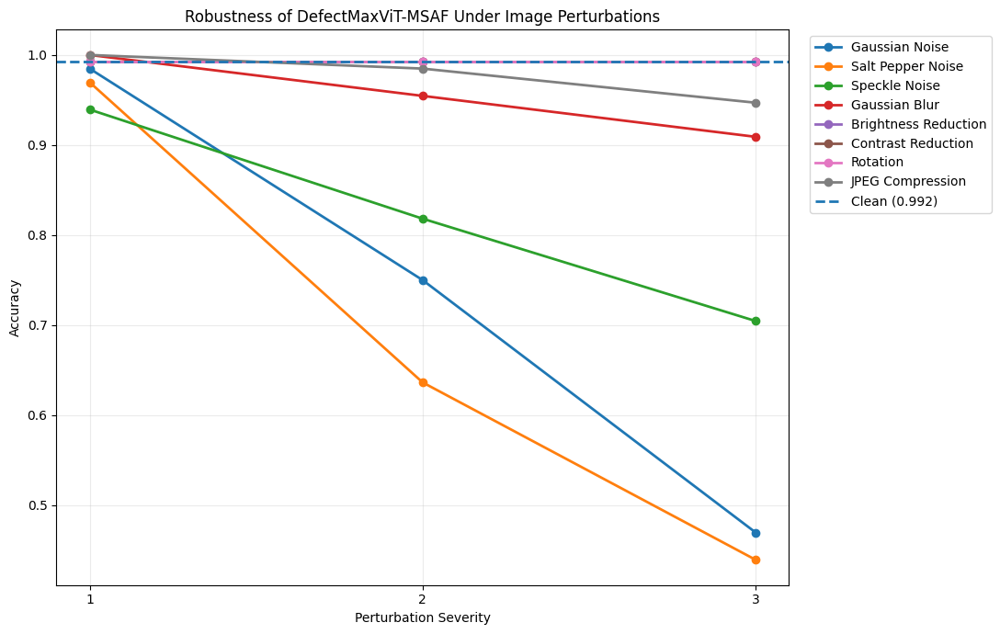

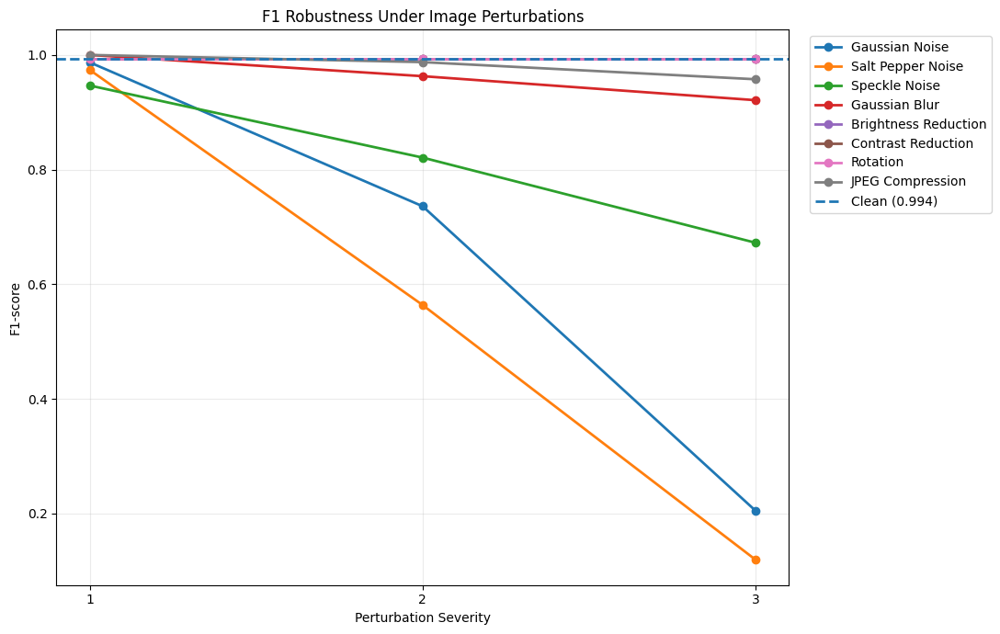

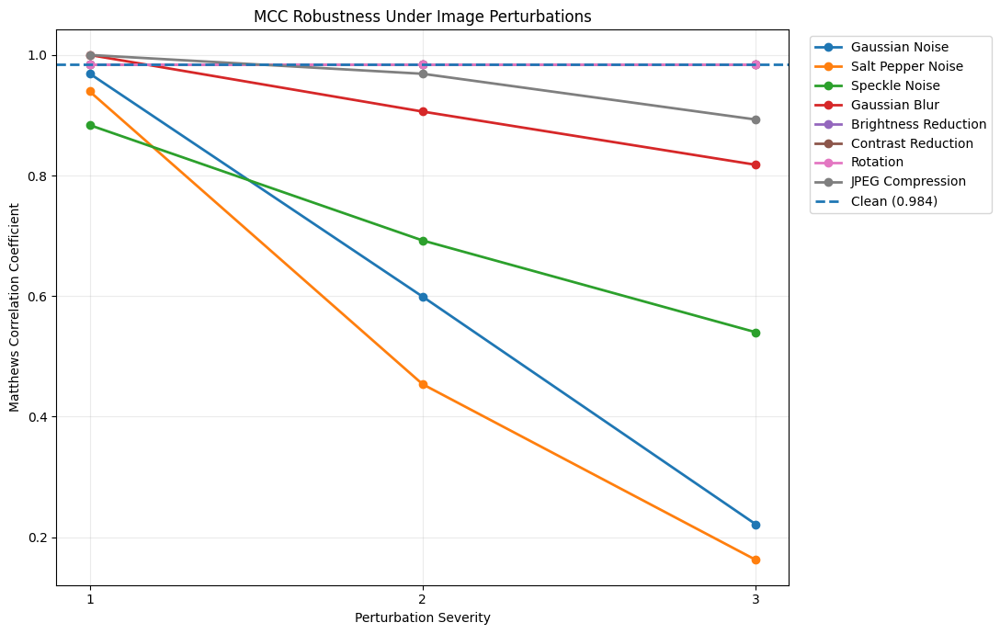

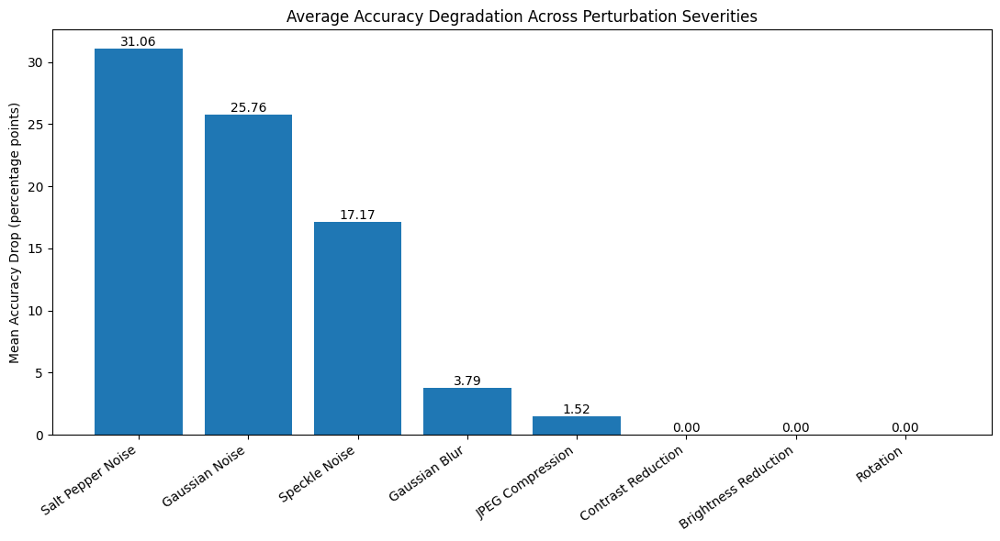

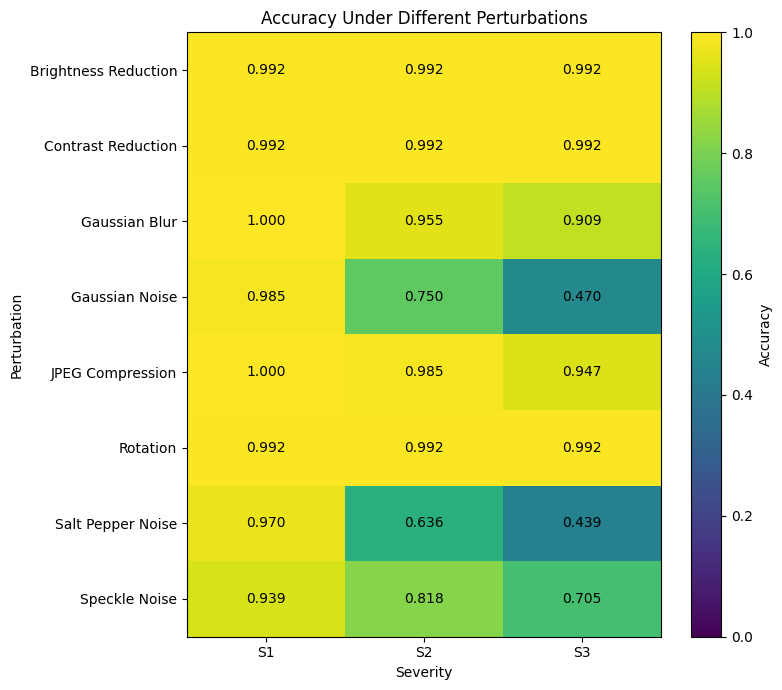

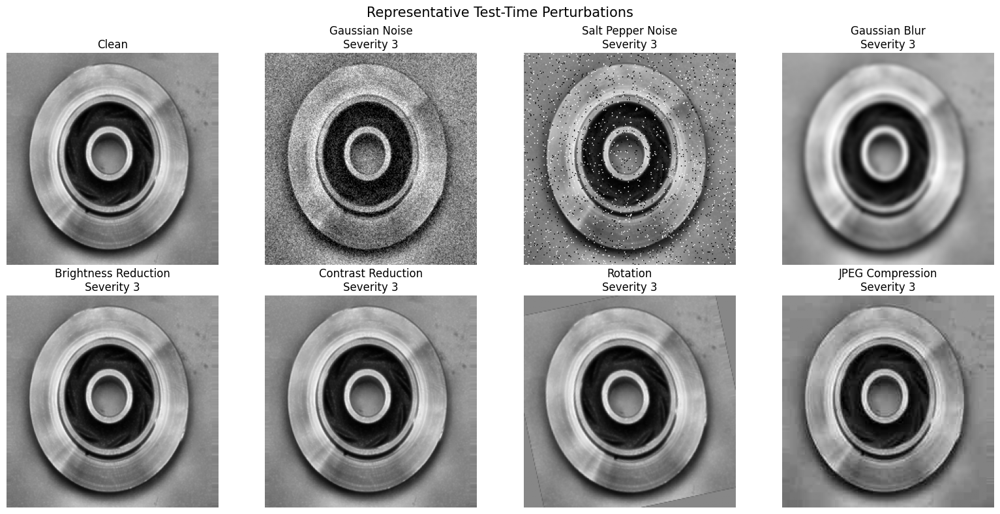


8. PAPER-READY ROBUSTNESS TABLE
        Perturbation  Severity  Accuracy     F1    MCC  ROC_AUC  Accuracy_Drop  F1_Drop  MCC_Drop  ROC_AUC_Drop
               Clean         0    0.9924 0.9936 0.9844   1.0000         0.0000   0.0000    0.0000        0.0000
      Gaussian Noise         1    0.9848 0.9872 0.9691   0.9976         0.0076   0.0065    0.0153        0.0024
      Gaussian Noise         2    0.7500 0.7360 0.5990   0.9611         0.2424   0.2576    0.3854        0.0389
      Gaussian Noise         3    0.4697 0.2045 0.2216   0.7873         0.5227   0.7891    0.7628        0.2127
   Salt Pepper Noise         1    0.9697 0.9740 0.9395   0.9916         0.0227   0.0196    0.0449        0.0084
   Salt Pepper Noise         2    0.6364 0.5636 0.4538   0.9618         0.3561   0.4300    0.5306        0.0382
   Salt Pepper Noise         3    0.4394 0.1190 0.1625   0.8889         0.5530   0.8746    0.8219        0.1111
       Speckle Noise         1    0.9394 0.9467 0.8837   0.9998        

In [ ]:
# ======================================================================
# ROBUSTNESS / PERTURBATION ANALYSIS FOR DefectMaxViT-MSAF

# 1. IMPORTS
# ======================================================================

import io
import gc
import random
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.transforms import functional as TF

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

from tqdm import tqdm


warnings.filterwarnings("ignore")


# ======================================================================
# 2. SETTINGS
# ======================================================================

SEED = 42

IMG_SIZE = 224

BATCH_SIZE = 8

NUM_WORKERS = 0


TEST_DIR = Path(
    "/kaggle/working/casting_512x512_split/test"
)


CHECKPOINT_PATH = Path(
    "/kaggle/working/DefectMaxViT_MSAF_results/"
    "best_DefectMaxViT_MSAF.pth"
)


ROBUSTNESS_DIR = Path(
    "/kaggle/working/DefectMaxViT_MSAF_results/"
    "robustness_analysis"
)


ROBUSTNESS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406]
).view(
    3, 1, 1
)


IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225]
).view(
    3, 1, 1
)


# ======================================================================
# 3. SEED
# ======================================================================

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)


seed_everything(SEED)


# ======================================================================
# 4. DEVICE
# ======================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


USE_AMP = (
    DEVICE.type == "cuda"
)


print("\n" + "=" * 80)
print("ROBUSTNESS EVALUATION")
print("=" * 80)

print(
    "Device:",
    DEVICE
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ======================================================================
# 5. LOAD BEST MODEL
#
# model must already have been created using:
# model = DefectMaxViTMSAF(...)
# ======================================================================

if "model" not in globals():

    raise RuntimeError(
        "\n'model' is not defined.\n"
        "Run the DefectMaxViT-MSAF model-definition cell first."
    )


if not CHECKPOINT_PATH.exists():

    raise FileNotFoundError(
        f"Checkpoint not found:\n{CHECKPOINT_PATH}"
    )


checkpoint = torch.load(

    CHECKPOINT_PATH,

    map_location=DEVICE,

    weights_only=False
)


model.load_state_dict(

    checkpoint[
        "model_state_dict"
    ]
)


model = model.to(
    DEVICE
)


model.eval()


print(
    "\nBest checkpoint loaded:"
)

print(
    CHECKPOINT_PATH
)


print(
    "Checkpoint epoch:",
    checkpoint.get(
        "epoch",
        "N/A"
    )
)


# ======================================================================
# 6. GET CLASS INFORMATION
# ======================================================================

base_dataset = datasets.ImageFolder(
    TEST_DIR
)


CLASS_NAMES = (
    base_dataset.classes
)


CLASS_TO_IDX = (
    base_dataset.class_to_idx
)


NUM_CLASSES = len(
    CLASS_NAMES
)


DEFECT_IDX = None


for class_name, idx in (
    CLASS_TO_IDX.items()
):

    if (
        "def" in class_name.lower()
        or
        "defect" in class_name.lower()
    ):

        DEFECT_IDX = idx

        break


if DEFECT_IDX is None:

    raise ValueError(
        "Defect class could not be detected."
    )


print(
    "\nClasses:",
    CLASS_TO_IDX
)


print(
    "Positive class:",
    CLASS_NAMES[DEFECT_IDX]
)


print(
    "Test images:",
    len(base_dataset)
)


# ======================================================================
# 7. JPEG COMPRESSION
# ======================================================================

def jpeg_compression(
    image,
    quality
):

    buffer = io.BytesIO()


    image.save(

        buffer,

        format="JPEG",

        quality=int(
            quality
        )
    )


    buffer.seek(0)


    compressed = Image.open(
        buffer
    ).convert(
        "L"
    )


    return compressed.copy()


# ======================================================================
# 8. PERTURBATION CONFIGURATION
#
# Severity values deliberately fixed before evaluation.
# ======================================================================

PERTURBATIONS = {

    "Gaussian Noise": {

        1: 0.03,

        2: 0.06,

        3: 0.10
    },


    "Salt Pepper Noise": {

        1: 0.01,

        2: 0.03,

        3: 0.05
    },


    "Speckle Noise": {

        1: 0.04,

        2: 0.08,

        3: 0.12
    },


    "Gaussian Blur": {

        1: 0.6,

        2: 1.2,

        3: 2.0
    },


    "Brightness Reduction": {

        1: 0.90,

        2: 0.75,

        3: 0.60
    },


    "Contrast Reduction": {

        1: 0.90,

        2: 0.70,

        3: 0.50
    },


    "Rotation": {

        1: 3,

        2: 7,

        3: 12
    },


    "JPEG Compression": {

        1: 80,

        2: 50,

        3: 25
    }
}


# ======================================================================
# 9. PERTURBATION TRANSFORM
#
# Corruption occurs BEFORE ImageNet normalization.
# ======================================================================

class RobustnessTransform:

    def __init__(

        self,

        perturbation="Clean",

        severity=0
    ):

        self.perturbation = (
            perturbation
        )

        self.severity = (
            severity
        )


    def __call__(
        self,
        image
    ):

        # --------------------------------------------------------------
        # Force grayscale
        # --------------------------------------------------------------

        image = image.convert(
            "L"
        )


        # --------------------------------------------------------------
        # Resize first
        # --------------------------------------------------------------

        image = TF.resize(

            image,

            [
                IMG_SIZE,
                IMG_SIZE
            ],

            interpolation=(
                transforms
                .InterpolationMode
                .BICUBIC
            )
        )


        # ==============================================================
        # JPEG perturbation must operate on PIL
        # ==============================================================

        if (
            self.perturbation
            ==
            "JPEG Compression"
        ):

            quality = (
                PERTURBATIONS[
                    self.perturbation
                ][
                    self.severity
                ]
            )


            image = jpeg_compression(

                image,

                quality
            )


        # --------------------------------------------------------------
        # Convert to tensor
        # 1 x H x W
        # --------------------------------------------------------------

        tensor = TF.to_tensor(
            image
        )


        # ==============================================================
        # GAUSSIAN NOISE
        # ==============================================================

        if (
            self.perturbation
            ==
            "Gaussian Noise"
        ):

            sigma = (
                PERTURBATIONS[
                    self.perturbation
                ][
                    self.severity
                ]
            )


            noise = torch.randn_like(
                tensor
            ) * sigma


            tensor = (
                tensor
                +
                noise
            )


        # ==============================================================
        # SALT-PEPPER NOISE
        # ==============================================================

        elif (
            self.perturbation
            ==
            "Salt Pepper Noise"
        ):

            amount = (
                PERTURBATIONS[
                    self.perturbation
                ][
                    self.severity
                ]
            )


            random_map = torch.rand_like(
                tensor
            )


            salt_mask = (
                random_map
                <
                (
                    amount / 2
                )
            )


            pepper_mask = (

                random_map
                >=
                (
                    amount / 2
                )

            ) & (

                random_map
                <
                amount
            )


            tensor[
                salt_mask
            ] = 1.0


            tensor[
                pepper_mask
            ] = 0.0


        # ==============================================================
        # SPECKLE NOISE
        # ==============================================================

        elif (
            self.perturbation
            ==
            "Speckle Noise"
        ):

            sigma = (
                PERTURBATIONS[
                    self.perturbation
                ][
                    self.severity
                ]
            )


            noise = torch.randn_like(
                tensor
            )


            tensor = (

                tensor

                +

                tensor
                *
                noise
                *
                sigma
            )


        # ==============================================================
        # GAUSSIAN BLUR
        # ==============================================================

        elif (
            self.perturbation
            ==
            "Gaussian Blur"
        ):

            sigma = (
                PERTURBATIONS[
                    self.perturbation
                ][
                    self.severity
                ]
            )


            tensor = TF.gaussian_blur(

                tensor,

                kernel_size=[
                    7,
                    7
                ],

                sigma=[
                    sigma,
                    sigma
                ]
            )


        # ==============================================================
        # BRIGHTNESS REDUCTION
        # ==============================================================

        elif (
            self.perturbation
            ==
            "Brightness Reduction"
        ):

            factor = (
                PERTURBATIONS[
                    self.perturbation
                ][
                    self.severity
                ]
            )


            tensor = (
                tensor
                *
                factor
            )


        # ==============================================================
        # CONTRAST REDUCTION
        # ==============================================================

        elif (
            self.perturbation
            ==
            "Contrast Reduction"
        ):

            factor = (
                PERTURBATIONS[
                    self.perturbation
                ][
                    self.severity
                ]
            )


            mean = tensor.mean(
                dim=[
                    1,
                    2
                ],
                keepdim=True
            )


            tensor = (

                mean

                +

                factor
                *
                (
                    tensor
                    -
                    mean
                )
            )


        # ==============================================================
        # ROTATION
        # ==============================================================

        elif (
            self.perturbation
            ==
            "Rotation"
        ):

            degrees = (
                PERTURBATIONS[
                    self.perturbation
                ][
                    self.severity
                ]
            )


            # Deterministic positive rotation.
            # Same corruption level for every image.
            tensor = TF.rotate(

                tensor,

                angle=float(
                    degrees
                ),

                interpolation=(
                    transforms
                    .InterpolationMode
                    .BILINEAR
                ),

                fill=0.5
            )


        # --------------------------------------------------------------
        # Clamp all corruption outputs
        # --------------------------------------------------------------

        tensor = torch.clamp(
            tensor,
            0.0,
            1.0
        )


        # --------------------------------------------------------------
        # Convert grayscale -> RGB-style 3 channels
        # --------------------------------------------------------------

        tensor = tensor.repeat(
            3,
            1,
            1
        )


        # --------------------------------------------------------------
        # ImageNet normalization
        # --------------------------------------------------------------

        tensor = (

            tensor
            -
            IMAGENET_MEAN

        ) / IMAGENET_STD


        return tensor


# ======================================================================
# 10. EVALUATE ONE CONDITION
# ======================================================================

@torch.inference_mode()
def evaluate_condition(

    perturbation="Clean",

    severity=0
):

    # Re-seed so random corruption is reproducible
    seed_everything(
        SEED
        +
        severity
    )


    transform = RobustnessTransform(

        perturbation=perturbation,

        severity=severity
    )


    dataset = datasets.ImageFolder(

        TEST_DIR,

        transform=transform
    )


    loader = DataLoader(

        dataset,

        batch_size=BATCH_SIZE,

        shuffle=False,

        num_workers=NUM_WORKERS,

        pin_memory=USE_AMP
    )


    all_true = []

    all_prob = []


    for images, targets in tqdm(

        loader,

        desc=(
            f"{perturbation} S{severity}"
            if severity > 0
            else "Clean"
        ),

        ncols=110,

        leave=False
    ):

        images = images.to(

            DEVICE,

            non_blocking=True
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=USE_AMP
        ):

            logits = model(
                images
            )


        probability = (

            torch.softmax(

                logits.float(),

                dim=1
            )

            .cpu()
            .numpy()
        )


        all_prob.append(
            probability
        )


        all_true.append(
            targets.numpy()
        )


    y_true = np.concatenate(
        all_true
    )


    y_prob = np.concatenate(
        all_prob
    )


    y_pred = np.argmax(
        y_prob,
        axis=1
    )


    y_true_binary = (

        y_true
        ==
        DEFECT_IDX

    ).astype(int)


    y_pred_binary = (

        y_pred
        ==
        DEFECT_IDX

    ).astype(int)


    defect_probability = (

        y_prob[
            :,
            DEFECT_IDX
        ]
    )


    # --------------------------------------------------------------
    # Binary confusion
    # --------------------------------------------------------------

    cm_binary = confusion_matrix(

        y_true_binary,

        y_pred_binary,

        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = (
        cm_binary.ravel()
    )


    sensitivity = (

        tp
        /
        (tp + fn)

        if (
            tp + fn
        ) > 0

        else 0.0
    )


    specificity = (

        tn
        /
        (tn + fp)

        if (
            tn + fp
        ) > 0

        else 0.0
    )


    # --------------------------------------------------------------
    # Metrics
    # --------------------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )


    precision = precision_score(

        y_true_binary,

        y_pred_binary,

        zero_division=0
    )


    f1 = f1_score(

        y_true_binary,

        y_pred_binary,

        zero_division=0
    )


    macro_f1 = f1_score(

        y_true,

        y_pred,

        average="macro",

        zero_division=0
    )


    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )


    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )


    try:

        roc_auc = roc_auc_score(

            y_true_binary,

            defect_probability
        )

    except:

        roc_auc = np.nan


    try:

        pr_auc = (
            average_precision_score(

                y_true_binary,

                defect_probability
            )
        )

    except:

        pr_auc = np.nan


    return {

        "Perturbation":
            perturbation,

        "Severity":
            severity,

        "Accuracy":
            accuracy,

        "Balanced_Accuracy":
            balanced_accuracy,

        "Precision":
            precision,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "F1":
            f1,

        "Macro_F1":
            macro_f1,

        "MCC":
            mcc,

        "Kappa":
            kappa,

        "ROC_AUC":
            roc_auc,

        "PR_AUC":
            pr_auc
    }


# ======================================================================
# 11. CLEAN BASELINE
# ======================================================================

print("\n" + "=" * 80)
print("1. CLEAN TEST PERFORMANCE")
print("=" * 80)


clean_result = evaluate_condition(

    perturbation="Clean",

    severity=0
)


print(
    "\nClean performance:"
)


for key, value in (
    clean_result.items()
):

    if key not in [
        "Perturbation",
        "Severity"
    ]:

        print(
            f"{key:<20}: "
            f"{value:.4f}"
        )


# ======================================================================
# 12. RUN ALL PERTURBATIONS
# ======================================================================

print("\n" + "=" * 80)
print("2. RUNNING PERTURBATION ROBUSTNESS TEST")
print("=" * 80)


results = [
    clean_result
]


for perturbation_name in (
    PERTURBATIONS.keys()
):

    print(
        "\n",
        "-" * 75
    )

    print(
        perturbation_name
    )

    print(
        "-" * 75
    )


    for severity in [
        1,
        2,
        3
    ]:

        result = evaluate_condition(

            perturbation=(
                perturbation_name
            ),

            severity=severity
        )


        results.append(
            result
        )


        print(

            f"S{severity} | "

            f"Acc={result['Accuracy']:.4f} | "

            f"F1={result['F1']:.4f} | "

            f"MCC={result['MCC']:.4f} | "

            f"AUC={result['ROC_AUC']:.4f}"
        )


# ======================================================================
# 13. DATAFRAME
# ======================================================================

results_df = pd.DataFrame(
    results
)


# ======================================================================
# 14. CALCULATE METRIC DROPS
# ======================================================================

clean_accuracy = (
    clean_result[
        "Accuracy"
    ]
)

clean_balanced = (
    clean_result[
        "Balanced_Accuracy"
    ]
)

clean_f1 = (
    clean_result[
        "F1"
    ]
)

clean_macro_f1 = (
    clean_result[
        "Macro_F1"
    ]
)

clean_mcc = (
    clean_result[
        "MCC"
    ]
)

clean_auc = (
    clean_result[
        "ROC_AUC"
    ]
)

clean_pr_auc = (
    clean_result[
        "PR_AUC"
    ]
)


results_df[
    "Accuracy_Drop"
] = (

    clean_accuracy

    -

    results_df[
        "Accuracy"
    ]
)


results_df[
    "Balanced_Acc_Drop"
] = (

    clean_balanced

    -

    results_df[
        "Balanced_Accuracy"
    ]
)


results_df[
    "F1_Drop"
] = (

    clean_f1

    -

    results_df[
        "F1"
    ]
)


results_df[
    "Macro_F1_Drop"
] = (

    clean_macro_f1

    -

    results_df[
        "Macro_F1"
    ]
)


results_df[
    "MCC_Drop"
] = (

    clean_mcc

    -

    results_df[
        "MCC"
    ]
)


results_df[
    "ROC_AUC_Drop"
] = (

    clean_auc

    -

    results_df[
        "ROC_AUC"
    ]
)


results_df[
    "PR_AUC_Drop"
] = (

    clean_pr_auc

    -

    results_df[
        "PR_AUC"
    ]
)


# Percentage-point drops
results_df[
    "Accuracy_Drop_pp"
] = (

    results_df[
        "Accuracy_Drop"
    ]

    *
    100
)


results_df[
    "F1_Drop_pp"
] = (

    results_df[
        "F1_Drop"
    ]

    *
    100
)


results_df[
    "ROC_AUC_Drop_pp"
] = (

    results_df[
        "ROC_AUC_Drop"
    ]

    *
    100
)


# ======================================================================
# 15. PRINT COMPLETE RESULTS
# ======================================================================

print("\n" + "=" * 80)
print("3. FULL ROBUSTNESS RESULTS")
print("=" * 80)


columns_to_print = [

    "Perturbation",

    "Severity",

    "Accuracy",

    "Balanced_Accuracy",

    "Precision",

    "Sensitivity",

    "Specificity",

    "F1",

    "Macro_F1",

    "MCC",

    "ROC_AUC",

    "PR_AUC"
]


print(

    results_df[
        columns_to_print
    ]
    .round(4)
    .to_string(
        index=False
    )
)


# ======================================================================
# 16. PRINT PERFORMANCE DROP TABLE
# ======================================================================

print("\n" + "=" * 80)
print("4. PERFORMANCE DROP FROM CLEAN TEST SET")
print("=" * 80)


drop_columns = [

    "Perturbation",

    "Severity",

    "Accuracy",

    "Accuracy_Drop",

    "F1",

    "F1_Drop",

    "MCC",

    "MCC_Drop",

    "ROC_AUC",

    "ROC_AUC_Drop"
]


drop_df = (

    results_df[
        results_df[
            "Perturbation"
        ]
        !=
        "Clean"
    ][
        drop_columns
    ]
)


print(

    drop_df
    .round(4)
    .to_string(
        index=False
    )
)


# ======================================================================
# 17. SAVE FULL CSV
# ======================================================================

results_df.to_csv(

    ROBUSTNESS_DIR /
    "all_perturbation_results.csv",

    index=False
)


drop_df.to_csv(

    ROBUSTNESS_DIR /
    "metric_drops.csv",

    index=False
)


# ======================================================================
# 18. AVERAGE ROBUSTNESS BY PERTURBATION
# ======================================================================

corrupted_df = results_df[
    results_df[
        "Perturbation"
    ]
    !=
    "Clean"
].copy()


average_robustness = (

    corrupted_df

    .groupby(
        "Perturbation"
    )

    .agg({

        "Accuracy":
            "mean",

        "Balanced_Accuracy":
            "mean",

        "F1":
            "mean",

        "Macro_F1":
            "mean",

        "MCC":
            "mean",

        "ROC_AUC":
            "mean",

        "PR_AUC":
            "mean",

        "Accuracy_Drop":
            "mean",

        "F1_Drop":
            "mean",

        "MCC_Drop":
            "mean",

        "ROC_AUC_Drop":
            "mean"
    })

    .reset_index()
)


print("\n" + "=" * 80)
print("5. AVERAGE ROBUSTNESS ACROSS THREE SEVERITY LEVELS")
print("=" * 80)


print(

    average_robustness
    .round(4)
    .to_string(
        index=False
    )
)


average_robustness.to_csv(

    ROBUSTNESS_DIR /
    "average_robustness.csv",

    index=False
)


# ======================================================================
# 19. WORST-SEVERITY RESULTS
# ======================================================================

severity3_df = (

    corrupted_df[
        corrupted_df[
            "Severity"
        ]
        ==
        3
    ]
    .copy()
)


print("\n" + "=" * 80)
print("6. STRONG PERTURBATION RESULTS (SEVERITY 3)")
print("=" * 80)


print(

    severity3_df[
        [
            "Perturbation",
            "Accuracy",
            "Accuracy_Drop",
            "F1",
            "F1_Drop",
            "MCC",
            "MCC_Drop",
            "ROC_AUC",
            "ROC_AUC_Drop"
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)


severity3_df.to_csv(

    ROBUSTNESS_DIR /
    "severity3_results.csv",

    index=False
)


# ======================================================================
# 20. GLOBAL ROBUSTNESS SUMMARY
# ======================================================================

mean_corrupted_accuracy = (
    corrupted_df[
        "Accuracy"
    ].mean()
)


mean_corrupted_f1 = (
    corrupted_df[
        "F1"
    ].mean()
)


mean_corrupted_mcc = (
    corrupted_df[
        "MCC"
    ].mean()
)


mean_corrupted_auc = (
    corrupted_df[
        "ROC_AUC"
    ].mean()
)


mean_accuracy_drop = (
    corrupted_df[
        "Accuracy_Drop"
    ].mean()
)


mean_f1_drop = (
    corrupted_df[
        "F1_Drop"
    ].mean()
)


mean_mcc_drop = (
    corrupted_df[
        "MCC_Drop"
    ].mean()
)


mean_auc_drop = (
    corrupted_df[
        "ROC_AUC_Drop"
    ].mean()
)


print("\n" + "=" * 80)
print("7. OVERALL CORRUPTION ROBUSTNESS")
print("=" * 80)


print(
    f"Clean Accuracy       : "
    f"{clean_accuracy:.4f}"
)

print(
    f"Mean Corrupt Acc     : "
    f"{mean_corrupted_accuracy:.4f}"
)

print(
    f"Mean Accuracy Drop   : "
    f"{mean_accuracy_drop:.4f} "
    f"({mean_accuracy_drop*100:.2f} pp)"
)


print()


print(
    f"Clean F1             : "
    f"{clean_f1:.4f}"
)

print(
    f"Mean Corrupt F1      : "
    f"{mean_corrupted_f1:.4f}"
)

print(
    f"Mean F1 Drop         : "
    f"{mean_f1_drop:.4f} "
    f"({mean_f1_drop*100:.2f} pp)"
)


print()


print(
    f"Clean MCC            : "
    f"{clean_mcc:.4f}"
)

print(
    f"Mean Corrupt MCC     : "
    f"{mean_corrupted_mcc:.4f}"
)

print(
    f"Mean MCC Drop        : "
    f"{mean_mcc_drop:.4f}"
)


print()


print(
    f"Clean ROC-AUC        : "
    f"{clean_auc:.4f}"
)

print(
    f"Mean Corrupt ROC-AUC : "
    f"{mean_corrupted_auc:.4f}"
)

print(
    f"Mean AUC Drop        : "
    f"{mean_auc_drop:.4f}"
)


# ======================================================================
# 21. PLOT ACCURACY VS SEVERITY
# ======================================================================

plt.figure(
    figsize=(11, 7)
)


for perturbation in (
    PERTURBATIONS.keys()
):

    temp = corrupted_df[
        corrupted_df[
            "Perturbation"
        ]
        ==
        perturbation
    ]


    plt.plot(

        temp[
            "Severity"
        ],

        temp[
            "Accuracy"
        ],

        marker="o",

        linewidth=2,

        label=perturbation
    )


plt.axhline(

    clean_accuracy,

    linestyle="--",

    linewidth=2,

    label=(
        f"Clean ({clean_accuracy:.3f})"
    )
)


plt.xlabel(
    "Perturbation Severity"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Robustness of DefectMaxViT-MSAF Under Image Perturbations"
)

plt.xticks(
    [
        1,
        2,
        3
    ]
)

plt.legend(

    bbox_to_anchor=(
        1.02,
        1
    ),

    loc="upper left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    ROBUSTNESS_DIR /
    "accuracy_vs_severity.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 22. F1 VS SEVERITY
# ======================================================================

plt.figure(
    figsize=(11, 7)
)


for perturbation in (
    PERTURBATIONS.keys()
):

    temp = corrupted_df[
        corrupted_df[
            "Perturbation"
        ]
        ==
        perturbation
    ]


    plt.plot(

        temp[
            "Severity"
        ],

        temp[
            "F1"
        ],

        marker="o",

        linewidth=2,

        label=perturbation
    )


plt.axhline(

    clean_f1,

    linestyle="--",

    linewidth=2,

    label=(
        f"Clean ({clean_f1:.3f})"
    )
)


plt.xlabel(
    "Perturbation Severity"
)

plt.ylabel(
    "F1-score"
)

plt.title(
    "F1 Robustness Under Image Perturbations"
)

plt.xticks(
    [
        1,
        2,
        3
    ]
)

plt.legend(

    bbox_to_anchor=(
        1.02,
        1
    ),

    loc="upper left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    ROBUSTNESS_DIR /
    "f1_vs_severity.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 23. MCC VS SEVERITY
# ======================================================================

plt.figure(
    figsize=(11, 7)
)


for perturbation in (
    PERTURBATIONS.keys()
):

    temp = corrupted_df[
        corrupted_df[
            "Perturbation"
        ]
        ==
        perturbation
    ]


    plt.plot(

        temp[
            "Severity"
        ],

        temp[
            "MCC"
        ],

        marker="o",

        linewidth=2,

        label=perturbation
    )


plt.axhline(

    clean_mcc,

    linestyle="--",

    linewidth=2,

    label=(
        f"Clean ({clean_mcc:.3f})"
    )
)


plt.xlabel(
    "Perturbation Severity"
)

plt.ylabel(
    "Matthews Correlation Coefficient"
)

plt.title(
    "MCC Robustness Under Image Perturbations"
)

plt.xticks(
    [
        1,
        2,
        3
    ]
)

plt.legend(

    bbox_to_anchor=(
        1.02,
        1
    ),

    loc="upper left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    ROBUSTNESS_DIR /
    "mcc_vs_severity.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 24. AVERAGE ACCURACY DROP BAR PLOT
# ======================================================================

plot_average = (
    average_robustness
    .sort_values(
        "Accuracy_Drop",
        ascending=False
    )
)


plt.figure(
    figsize=(11, 6)
)


bars = plt.bar(

    plot_average[
        "Perturbation"
    ],

    plot_average[
        "Accuracy_Drop"
    ] * 100
)


plt.ylabel(
    "Mean Accuracy Drop (percentage points)"
)

plt.title(
    "Average Accuracy Degradation Across Perturbation Severities"
)

plt.xticks(
    rotation=35,
    ha="right"
)


for bar in bars:

    value = (
        bar.get_height()
    )


    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        value,

        f"{value:.2f}",

        ha="center",

        va="bottom"
    )


plt.tight_layout()


plt.savefig(

    ROBUSTNESS_DIR /
    "average_accuracy_drop.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 25. ROBUSTNESS HEATMAP — ACCURACY
# ======================================================================

accuracy_matrix = (

    corrupted_df

    .pivot(

        index="Perturbation",

        columns="Severity",

        values="Accuracy"
    )
)


fig, ax = plt.subplots(
    figsize=(8, 7)
)


image = ax.imshow(
    accuracy_matrix.values,
    aspect="auto",
    vmin=0,
    vmax=1
)


plt.colorbar(
    image,
    ax=ax,
    label="Accuracy"
)


ax.set_xticks(
    np.arange(
        len(
            accuracy_matrix.columns
        )
    )
)


ax.set_xticklabels(

    [
        f"S{x}"
        for x in
        accuracy_matrix.columns
    ]
)


ax.set_yticks(
    np.arange(
        len(
            accuracy_matrix.index
        )
    )
)


ax.set_yticklabels(
    accuracy_matrix.index
)


for i in range(
    accuracy_matrix.shape[0]
):

    for j in range(
        accuracy_matrix.shape[1]
    ):

        value = (
            accuracy_matrix.iloc[
                i,
                j
            ]
        )


        ax.text(

            j,
            i,

            f"{value:.3f}",

            ha="center",

            va="center"
        )


ax.set_xlabel(
    "Severity"
)

ax.set_ylabel(
    "Perturbation"
)

ax.set_title(
    "Accuracy Under Different Perturbations"
)


plt.tight_layout()


plt.savefig(

    ROBUSTNESS_DIR /
    "accuracy_robustness_heatmap.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 26. PLOT EXAMPLE PERTURBED IMAGES
# ======================================================================

sample_path = (
    base_dataset.samples[0][0]
)


sample_original = Image.open(
    sample_path
).convert(
    "L"
)


selected_examples = [

    ("Clean", 0),

    ("Gaussian Noise", 3),

    ("Salt Pepper Noise", 3),

    ("Gaussian Blur", 3),

    ("Brightness Reduction", 3),

    ("Contrast Reduction", 3),

    ("Rotation", 3),

    ("JPEG Compression", 3)
]


fig, axes = plt.subplots(

    2,
    4,

    figsize=(
        16,
        8
    )
)


axes = axes.flatten()


for ax, (
    perturbation,
    severity
) in zip(
    axes,
    selected_examples
):


    seed_everything(
        SEED
    )


    transform = RobustnessTransform(

        perturbation=perturbation,

        severity=severity
    )


    tensor = transform(
        sample_original
    )


    # Undo ImageNet normalization for display
    display_tensor = (

        tensor
        *
        IMAGENET_STD
        +
        IMAGENET_MEAN
    )


    display_image = (

        display_tensor[0]
        .clamp(
            0,
            1
        )
        .numpy()
    )


    ax.imshow(
        display_image,
        cmap="gray"
    )


    if perturbation == "Clean":

        title = "Clean"

    else:

        title = (
            f"{perturbation}\n"
            f"Severity {severity}"
        )


    ax.set_title(
        title
    )


    ax.axis(
        "off"
    )


plt.suptitle(
    "Representative Test-Time Perturbations",
    fontsize=15
)


plt.tight_layout()


plt.savefig(

    ROBUSTNESS_DIR /
    "perturbation_examples.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 27. PAPER-READY TABLE
# ======================================================================

paper_table = results_df[

    [
        "Perturbation",
        "Severity",
        "Accuracy",
        "F1",
        "MCC",
        "ROC_AUC",
        "Accuracy_Drop",
        "F1_Drop",
        "MCC_Drop",
        "ROC_AUC_Drop"
    ]

].copy()


paper_table.to_csv(

    ROBUSTNESS_DIR /
    "paper_ready_robustness_table.csv",

    index=False
)


print("\n" + "=" * 80)
print("8. PAPER-READY ROBUSTNESS TABLE")
print("=" * 80)


print(

    paper_table
    .round(4)
    .to_string(
        index=False
    )
)


# ======================================================================
# 28. FINAL SUMMARY
# ======================================================================

print("\n" + "=" * 80)
print("ROBUSTNESS ANALYSIS COMPLETE")
print("=" * 80)


print(
    f"Clean Accuracy : {clean_accuracy:.4f}"
)

print(
    f"Clean F1       : {clean_f1:.4f}"
)

print(
    f"Clean MCC      : {clean_mcc:.4f}"
)

print(
    f"Clean ROC-AUC  : {clean_auc:.4f}"
)


print("\nAverage across all perturbation/severity combinations:")


print(
    f"Accuracy       : "
    f"{mean_corrupted_accuracy:.4f}"
)

print(
    f"F1             : "
    f"{mean_corrupted_f1:.4f}"
)

print(
    f"MCC            : "
    f"{mean_corrupted_mcc:.4f}"
)

print(
    f"ROC-AUC        : "
    f"{mean_corrupted_auc:.4f}"
)


print("\nAverage degradation from clean:")


print(
    f"Accuracy drop  : "
    f"{mean_accuracy_drop:.4f} "
    f"({mean_accuracy_drop*100:.2f} pp)"
)

print(
    f"F1 drop        : "
    f"{mean_f1_drop:.4f} "
    f"({mean_f1_drop*100:.2f} pp)"
)

print(
    f"MCC drop       : "
    f"{mean_mcc_drop:.4f}"
)

print(
    f"ROC-AUC drop   : "
    f"{mean_auc_drop:.4f}"
)


print(
    "\nResults saved at:"
)

print(
    ROBUSTNESS_DIR
)


print("\nGenerated files:")


for file in sorted(
    ROBUSTNESS_DIR.iterdir()
):

    print(
        " -",
        file.name
    )


print("=" * 80)

SLIC superpixels available for LIME.

LOADING BEST DefectMaxViT-MSAF
Checkpoint epoch: 2
Device: cuda

Classes: {'def_front': 0, 'ok_front': 1}
Defect class: def_front
Defect index: 0
Total test images: 132

Generating test predictions...


Test prediction: 100%|████████████████████████████████████████████| 132/132 [00:05<00:00, 24.01it/s]



Prediction completed.

DEF_FRONT SAMPLE SELECTION
Total def_front test images   : 79
Correct def_front predictions : 78
Samples selected for XAI     : 20
Explanation target           : def_front

RUNNING XAI — def_front ONLY


def_front XAI: 100%|████████████████████████████████████████████████| 20/20 [01:09<00:00,  3.50s/it]



Per-image metrics saved:
/kaggle/working/DefectMaxViT_MSAF_results/xai_def_front_only/def_front_xai_per_image_metrics.csv

QUANTITATIVE XAI RESULTS — def_front ONLY
   Method  Insertion_AUC  Deletion_AUC  Faithfulness_Gap  Confidence_Drop_Top20  Relative_Confidence_Drop_Top20  Localization_IoU
     LIME         0.9341        0.5435            0.3906                 0.2685                          0.2760               NaN
Score-CAM         0.8779        0.5821            0.2958                 0.1927                          0.1985               NaN
Eigen-CAM         0.7196        0.7275           -0.0079                 0.1774                          0.1839               NaN
 Saliency         0.4940        0.5092           -0.0152                 0.3318                          0.3424               NaN

BOOTSTRAP 95% CONFIDENCE INTERVALS

LIME
Insertion AUC : 0.9341 [0.9255, 0.9411]
Deletion AUC  : 0.5435 [0.4733, 0.6075]
Faithfulness  : 0.3906 [0.3258, 0.4636]
Confidence Drop@20% : 

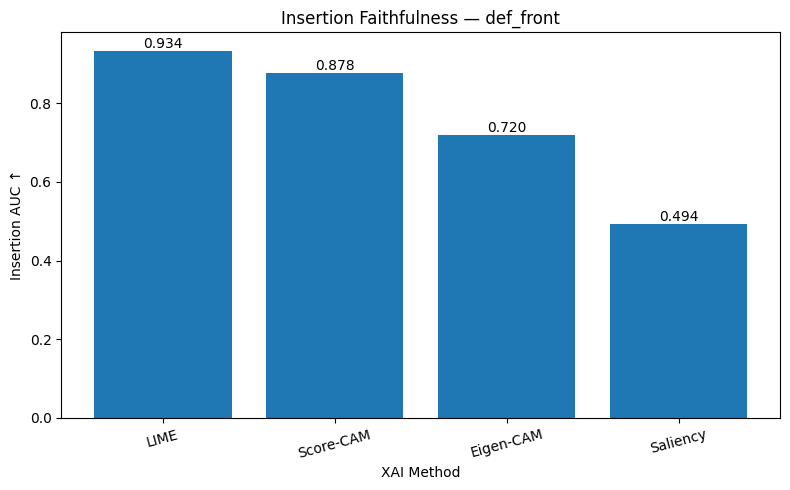

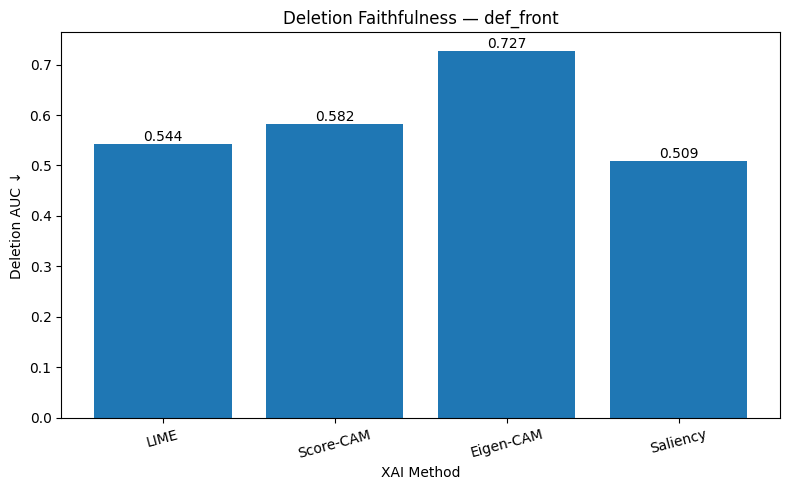

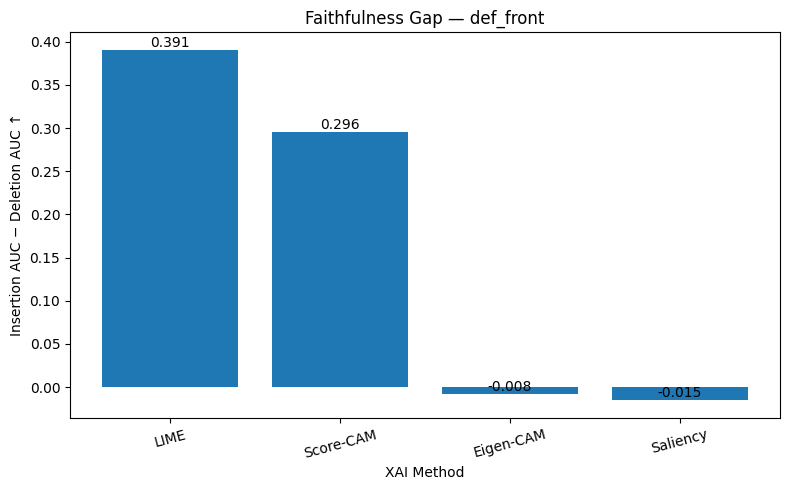

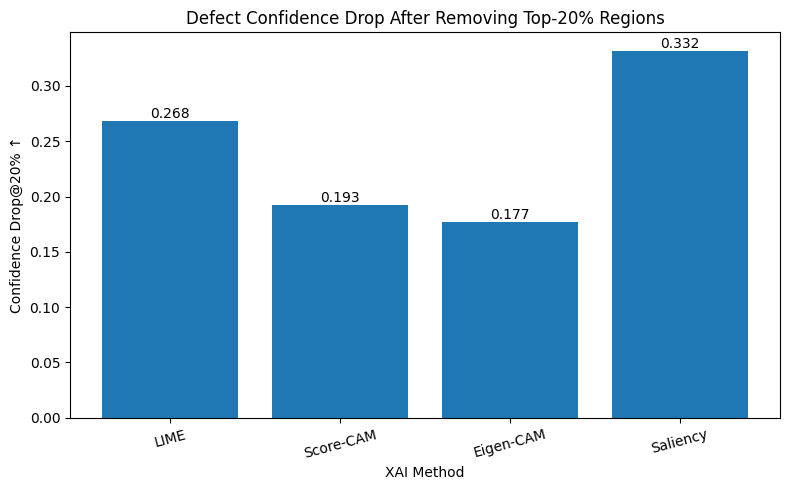


Generating def_front XAI figures...


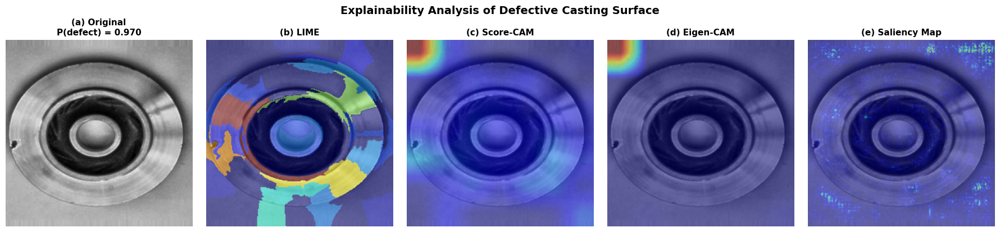

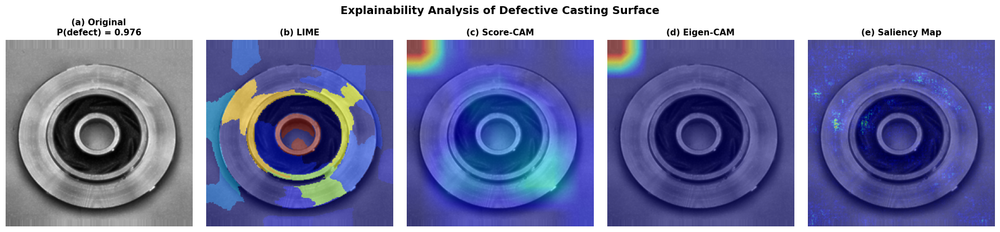

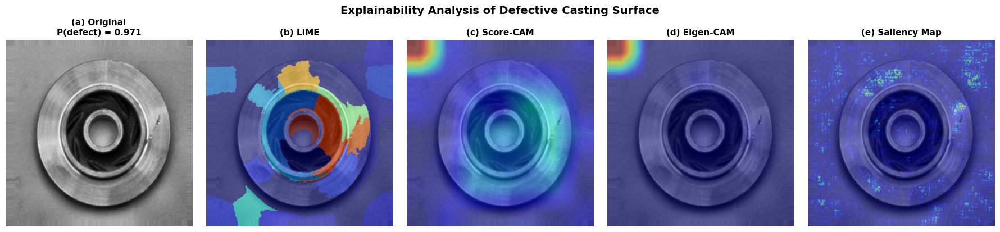

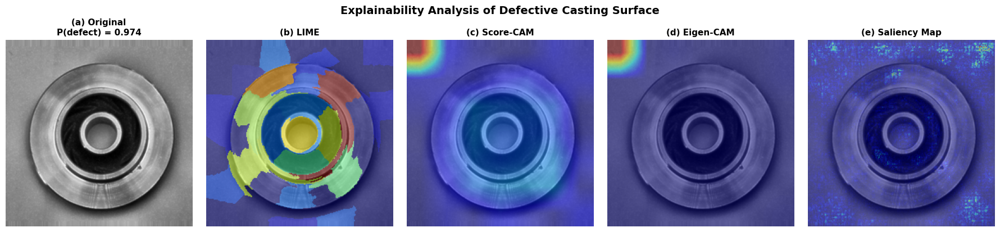

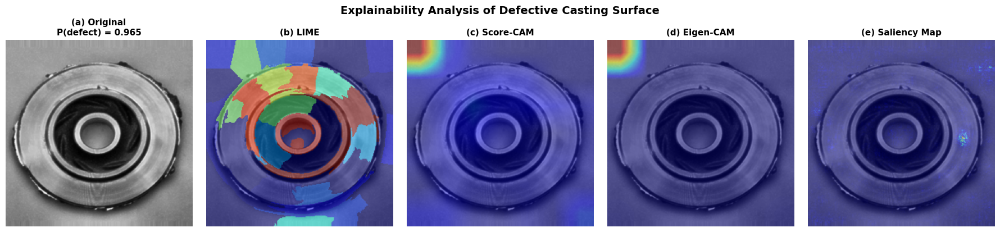

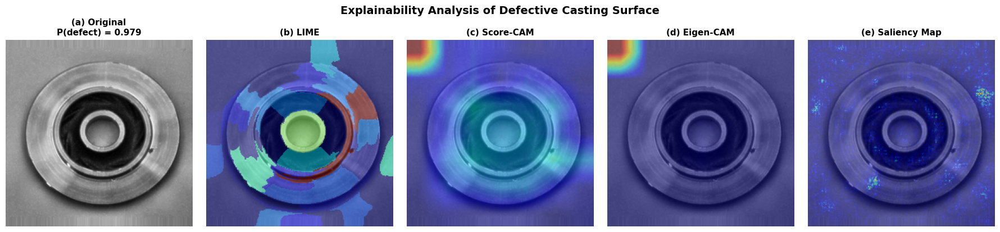


FINAL PAPER-READY XAI TABLE — def_front ONLY
   Method  Insertion AUC ↑  Deletion AUC ↓  Faithfulness Gap ↑  Confidence Drop@20% ↑  Relative Drop@20% ↑
     LIME           0.9341          0.5435              0.3906                 0.2685               0.2760
Score-CAM           0.8779          0.5821              0.2958                 0.1927               0.1985
Eigen-CAM           0.7196          0.7275             -0.0079                 0.1774               0.1839
 Saliency           0.4940          0.5092             -0.0152                 0.3318               0.3424

DEF_FRONT XAI ANALYSIS COMPLETE
True class evaluated       : def_front
XAI samples evaluated      : 20
LIME samples/image         : 250
Insertion/deletion steps   : 20
Important region threshold : Top 20%

Methods:
  1. LIME
  2. Score-CAM
  3. Eigen-CAM
  4. Saliency Map

Metric interpretation:
Insertion AUC       ↑ higher is better
Deletion AUC        ↓ lower is better
Faithfulness Gap    ↑ higher is better
Confi

In [ ]:
# ======================================================================
# DefectMaxViT-MSAF
# COMPLETE XAI ANALYSIS — def_front ONLY
#
# METHODS:
#   1. LIME
#   2. Score-CAM
#   3. Eigen-CAM
#   4. Saliency Map
#



# ======================================================================
# 1. IMPORTS
# ======================================================================

import gc
import math
import random
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn.functional as F

from torchvision import datasets, transforms
from torchvision.transforms import functional as TF

from sklearn.linear_model import Ridge

from tqdm import tqdm


warnings.filterwarnings("ignore")


# ======================================================================
# 2. OPTIONAL SLIC FOR LIME
# ======================================================================

try:

    from skimage.segmentation import slic

    SKIMAGE_AVAILABLE = True

    print(
        "SLIC superpixels available for LIME."
    )

except Exception:

    SKIMAGE_AVAILABLE = False

    print(
        "scikit-image unavailable. "
        "Grid regions will be used for LIME."
    )


# ======================================================================
# 3. CONFIGURATION
# ======================================================================

SEED = 42

IMG_SIZE = 224


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


USE_AMP = (
    DEVICE.type == "cuda"
)


TEST_DIR = Path(
    "/kaggle/working/casting_512x512_split/test"
)


CHECKPOINT_PATH = Path(
    "/kaggle/working/DefectMaxViT_MSAF_results/"
    "best_DefectMaxViT_MSAF.pth"
)


XAI_DIR = Path(
    "/kaggle/working/DefectMaxViT_MSAF_results/"
    "xai_def_front_only"
)


XAI_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ----------------------------------------------------------------------
# OPTIONAL PIXEL-LEVEL DEFECT MASKS
#
# Keep None if no segmentation masks exist.
#
# Example:
#
# MASK_DIR = Path("/kaggle/input/casting-masks")
# ----------------------------------------------------------------------

MASK_DIR = None


# ----------------------------------------------------------------------
# Number of def_front samples
#
# Set:
#
# XAI_NUM_SAMPLES = 20
#
# or:
#
# XAI_NUM_SAMPLES = None
#
# to evaluate ALL correctly classified def_front test samples.
# ----------------------------------------------------------------------

XAI_NUM_SAMPLES = 20


# ----------------------------------------------------------------------
# Number of qualitative figures
# ----------------------------------------------------------------------

NUM_VISUAL_EXAMPLES = 6


# ----------------------------------------------------------------------
# LIME
# ----------------------------------------------------------------------

LIME_NUM_SAMPLES = 250

LIME_NUM_SEGMENTS = 50

LIME_KERNEL_WIDTH = 0.25

LIME_BATCH_SIZE = 16


# ----------------------------------------------------------------------
# Score-CAM
# ----------------------------------------------------------------------

SCORECAM_BATCH_SIZE = 32


# ----------------------------------------------------------------------
# Quantitative faithfulness
# ----------------------------------------------------------------------

PERTURBATION_STEPS = 20


# ----------------------------------------------------------------------
# Top attribution region
# ----------------------------------------------------------------------

TOP_PERCENT = 0.20


# ----------------------------------------------------------------------
# Bootstrap
# ----------------------------------------------------------------------

BOOTSTRAP_ITERATIONS = 1000


# ======================================================================
# 4. REPRODUCIBILITY
# ======================================================================

def seed_everything(
    seed=42
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    torch.cuda.manual_seed(
        seed
    )

    torch.cuda.manual_seed_all(
        seed
    )


seed_everything(
    SEED
)


# ======================================================================
# 5. IMAGENET NORMALIZATION
# ======================================================================

IMAGENET_MEAN = torch.tensor(

    [
        0.485,
        0.456,
        0.406
    ],

    dtype=torch.float32

).view(
    1,
    3,
    1,
    1
)


IMAGENET_STD = torch.tensor(

    [
        0.229,
        0.224,
        0.225
    ],

    dtype=torch.float32

).view(
    1,
    3,
    1,
    1
)


def normalize_batch(
    images
):

    mean = IMAGENET_MEAN.to(
        images.device
    )

    std = IMAGENET_STD.to(
        images.device
    )


    return (

        images
        -
        mean

    ) / std


# ======================================================================
# 6. LOAD BEST MODEL
# ======================================================================

print(
    "\n" + "=" * 80
)

print(
    "LOADING BEST DefectMaxViT-MSAF"
)

print(
    "=" * 80
)


if (
    "DefectMaxViTMSAF"
    not in globals()
):

    raise RuntimeError(

        "DefectMaxViTMSAF is not defined.\n"
        "Run your MaxViT model-definition cell first."
    )


if not CHECKPOINT_PATH.exists():

    raise FileNotFoundError(

        f"Checkpoint not found:\n"
        f"{CHECKPOINT_PATH}"
    )


model = DefectMaxViTMSAF(

    num_classes=2,

    projection_dim=128,

    dropout=0.35,

    pretrained=False

).to(
    DEVICE
)


checkpoint = torch.load(

    CHECKPOINT_PATH,

    map_location=DEVICE,

    weights_only=False
)


model.load_state_dict(

    checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print(
    "Checkpoint epoch:",
    checkpoint.get(
        "epoch",
        "N/A"
    )
)


print(
    "Device:",
    DEVICE
)


# ======================================================================
# 7. LOAD TEST DATASET
# ======================================================================

base_dataset = datasets.ImageFolder(
    TEST_DIR
)


CLASS_NAMES = (
    base_dataset.classes
)


CLASS_TO_IDX = (
    base_dataset.class_to_idx
)


NUM_CLASSES = len(
    CLASS_NAMES
)


print(
    "\nClasses:",
    CLASS_TO_IDX
)


# ======================================================================
# 8. FIND def_front CLASS
# ======================================================================

DEFECT_IDX = None


for class_name, class_idx in (
    CLASS_TO_IDX.items()
):

    if (
        class_name.lower()
        ==
        "def_front"
    ):

        DEFECT_IDX = (
            class_idx
        )

        break


if DEFECT_IDX is None:

    raise RuntimeError(

        "Class 'def_front' was not found."
    )


print(
    "Defect class:",
    CLASS_NAMES[
        DEFECT_IDX
    ]
)


print(
    "Defect index:",
    DEFECT_IDX
)


print(
    "Total test images:",
    len(
        base_dataset
    )
)


# ======================================================================
# 9. LOAD RAW IMAGE
#
# Output:
# [3,224,224], range 0-1
# ======================================================================

def load_raw_image(
    image_path
):

    image = Image.open(
        image_path
    ).convert(
        "L"
    )


    image = TF.resize(

        image,

        [
            IMG_SIZE,
            IMG_SIZE
        ],

        interpolation=(
            transforms
            .InterpolationMode
            .BICUBIC
        )
    )


    tensor = TF.to_tensor(
        image
    )


    tensor = tensor.repeat(
        3,
        1,
        1
    )


    return tensor


# ======================================================================
# 10. PREDICT RAW IMAGE
# ======================================================================

@torch.inference_mode()
def predict_raw(
    raw_tensor
):

    if raw_tensor.ndim == 3:

        raw_tensor = (
            raw_tensor.unsqueeze(
                0
            )
        )


    raw_tensor = raw_tensor.to(
        DEVICE
    )


    normalized = normalize_batch(
        raw_tensor
    )


    with torch.autocast(

        device_type=DEVICE.type,

        dtype=torch.float16,

        enabled=USE_AMP
    ):

        logits = model(
            normalized
        )


    probabilities = torch.softmax(

        logits.float(),

        dim=1
    )


    return probabilities


# ======================================================================
# 11. CLEAN TEST PREDICTIONS
# ======================================================================

print(
    "\nGenerating test predictions..."
)


all_true = []

all_pred = []

all_prob = []


for image_path, label in tqdm(

    base_dataset.samples,

    desc="Test prediction",

    ncols=100
):

    raw_image = load_raw_image(
        image_path
    )


    probability = predict_raw(
        raw_image
    )[0]


    prediction = int(
        probability.argmax().item()
    )


    all_true.append(
        label
    )


    all_pred.append(
        prediction
    )


    all_prob.append(

        probability
        .cpu()
        .numpy()
    )


all_true = np.asarray(
    all_true
)


all_pred = np.asarray(
    all_pred
)


all_prob = np.asarray(
    all_prob
)


print(
    "\nPrediction completed."
)


# ======================================================================
# 12. SELECT ONLY def_front
# ======================================================================

defect_indices = np.where(

    all_true
    ==
    DEFECT_IDX

)[0]


correct_defect_indices = defect_indices[

    all_pred[
        defect_indices
    ]

    ==
    DEFECT_IDX
]


print(
    "\n" + "=" * 80
)

print(
    "DEF_FRONT SAMPLE SELECTION"
)

print(
    "=" * 80
)


print(
    f"Total def_front test images   : "
    f"{len(defect_indices)}"
)


print(
    f"Correct def_front predictions : "
    f"{len(correct_defect_indices)}"
)


if (
    len(
        correct_defect_indices
    )
    ==
    0
):

    raise RuntimeError(

        "No correctly predicted "
        "def_front test samples."
    )


rng = np.random.default_rng(
    SEED
)


if XAI_NUM_SAMPLES is None:

    selected_indices = (
        correct_defect_indices.copy()
    )


else:

    number_to_select = min(

        XAI_NUM_SAMPLES,

        len(
            correct_defect_indices
        )
    )


    selected_indices = rng.choice(

        correct_defect_indices,

        size=number_to_select,

        replace=False
    )


selected_indices = np.sort(
    selected_indices
)


print(
    f"Samples selected for XAI     : "
    f"{len(selected_indices)}"
)


print(
    "Explanation target           : def_front"
)


# ======================================================================
# 13. NORMALIZE HEATMAP
# ======================================================================

def normalize_map(
    attribution
):

    attribution = np.asarray(

        attribution,

        dtype=np.float32
    )


    attribution = np.nan_to_num(
        attribution
    )


    attribution = (

        attribution
        -
        attribution.min()
    )


    maximum = (
        attribution.max()
    )


    if maximum > 1e-12:

        attribution = (

            attribution

            /

            maximum
        )


    return attribution


# ======================================================================
# 14. FEATURE HOOK
#
# We use model.att3, i.e. the final modified multi-scale MaxViT feature
# before pooling/fusion.
# ======================================================================

class FeatureHook:

    def __init__(
        self,
        layer
    ):

        self.activations = None


        self.handle = (
            layer.register_forward_hook(
                self._hook
            )
        )


    def _hook(
        self,
        module,
        inputs,
        output
    ):

        self.activations = (
            output.detach()
        )


    def remove(
        self
    ):

        self.handle.remove()


if not hasattr(
    model,
    "att3"
):

    raise RuntimeError(

        "model.att3 does not exist. "
        "Check your DefectMaxViTMSAF architecture."
    )


feature_hook = FeatureHook(
    model.att3
)


# ======================================================================
# 15. GET DEEP FEATURE ACTIVATION
# ======================================================================

@torch.inference_mode()
def get_target_activations(
    raw_image
):

    normalized = normalize_batch(

        raw_image
        .unsqueeze(0)
        .to(
            DEVICE
        )
    )


    with torch.autocast(

        device_type=DEVICE.type,

        dtype=torch.float16,

        enabled=USE_AMP
    ):

        logits = model(
            normalized
        )


    activations = (

        feature_hook
        .activations
        .float()
        .clone()
    )


    probabilities = torch.softmax(

        logits.float(),

        dim=1
    )


    return (
        activations,
        probabilities
    )


# ======================================================================
# 16. SALIENCY MAP
# ======================================================================

def generate_saliency(

    raw_image,

    target_class
):

    model.zero_grad(
        set_to_none=True
    )


    normalized = normalize_batch(

        raw_image
        .unsqueeze(0)
        .to(
            DEVICE
        )
    )


    input_tensor = (

        normalized
        .clone()
        .detach()
        .requires_grad_(
            True
        )
    )


    # Use full precision for gradient calculation
    logits = model(
        input_tensor
    )


    target_score = logits[

        0,

        target_class
    ]


    target_score.backward()


    gradients = (

        input_tensor
        .grad
        .detach()
        .abs()
    )


    saliency = (

        gradients
        .max(
            dim=1
        )[0][0]
        .cpu()
        .numpy()
    )


    return normalize_map(
        saliency
    )


# ======================================================================
# 17. EIGEN-CAM
# ======================================================================

def generate_eigencam(
    raw_image
):

    activations, _ = (
        get_target_activations(
            raw_image
        )
    )


    # [1,C,H,W]
    activation = (
        activations[
            0
        ]
    )


    C, H, W = (
        activation.shape
    )


    # [H*W,C]
    matrix = (

        activation
        .permute(
            1,
            2,
            0
        )
        .reshape(
            -1,
            C
        )
    )


    matrix = (

        matrix

        -

        matrix.mean(
            dim=0,
            keepdim=True
        )
    )


    # --------------------------------------------------------------
    # Principal component
    # --------------------------------------------------------------

    try:

        U, S, Vh = torch.linalg.svd(

            matrix,

            full_matrices=False
        )


        projection = (

            U[
                :,
                0
            ]

            *
            S[0]
        )


    except Exception:

        covariance = (

            matrix.T

            @

            matrix
        )


        eigenvalues, eigenvectors = (
            torch.linalg.eigh(
                covariance
            )
        )


        principal_component = (
            eigenvectors[
                :,
                -1
            ]
        )


        projection = (

            matrix

            @

            principal_component
        )


    # PCA sign is arbitrary.
    # Flip sign if required to make dominant response positive.
    if projection.mean() < 0:

        projection = (
            -
            projection
        )


    cam = projection.reshape(
        H,
        W
    )


    cam = F.relu(
        cam
    )


    cam = (

        cam
        .unsqueeze(0)
        .unsqueeze(0)
    )


    cam = F.interpolate(

        cam,

        size=(
            IMG_SIZE,
            IMG_SIZE
        ),

        mode="bilinear",

        align_corners=False
    )


    cam = (

        cam[
            0,
            0
        ]
        .cpu()
        .numpy()
    )


    return normalize_map(
        cam
    )


# ======================================================================
# 18. SCORE-CAM
# ======================================================================

@torch.inference_mode()
def generate_scorecam(

    raw_image,

    target_class,

    batch_size=32
):

    activations, clean_probabilities = (
        get_target_activations(
            raw_image
        )
    )


    # clone because future model forward passes overwrite hook output
    activation = (

        activations[
            0
        ]
        .float()
        .clone()
    )


    C, H, W = (
        activation.shape
    )


    # --------------------------------------------------------------
    # Upsample each feature map
    # --------------------------------------------------------------

    upsampled = F.interpolate(

        activation.unsqueeze(1),

        size=(
            IMG_SIZE,
            IMG_SIZE
        ),

        mode="bilinear",

        align_corners=False
    )[
        :,
        0
    ]


    # --------------------------------------------------------------
    # Normalize each map independently
    # --------------------------------------------------------------

    flat = upsampled.reshape(
        C,
        -1
    )


    minimum = (

        flat.min(
            dim=1
        )[0]
        .view(
            C,
            1,
            1
        )
    )


    maximum = (

        flat.max(
            dim=1
        )[0]
        .view(
            C,
            1,
            1
        )
    )


    ranges = (

        maximum

        -

        minimum
    )


    valid = (

        ranges
        .view(-1)

        >
        1e-6
    )


    normalized_maps = (

        (
            upsampled
            -
            minimum
        )

        /

        (
            ranges
            +
            1e-8
        )
    )


    normalized_maps = (
        normalized_maps[
            valid
        ]
    )


    activation_valid = (
        activation[
            valid
        ]
    )


    if (
        normalized_maps.shape[0]
        ==
        0
    ):

        return np.zeros(

            (
                IMG_SIZE,
                IMG_SIZE
            ),

            dtype=np.float32
        )


    scores = []


    for start in range(

        0,

        normalized_maps.shape[0],

        batch_size
    ):

        current_masks = (

            normalized_maps[
                start:
                start + batch_size
            ]

            .unsqueeze(1)

            .to(
                DEVICE
            )
        )


        # raw_image: 3,H,W
        masked_images = (

            raw_image
            .unsqueeze(0)
            .to(
                DEVICE
            )

            *

            current_masks
        )


        normalized_inputs = (
            normalize_batch(
                masked_images
            )
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=USE_AMP
        ):

            logits = model(
                normalized_inputs
            )


        target_probabilities = (

            torch.softmax(
                logits.float(),
                dim=1
            )[
                :,
                target_class
            ]
        )


        scores.append(

            target_probabilities
            .cpu()
        )


    scores = torch.cat(
        scores
    )


    # --------------------------------------------------------------
    # Weighted deep feature maps
    # --------------------------------------------------------------

    scorecam = (

        scores
        .view(
            -1,
            1,
            1
        )
        .to(
            activation_valid.device
        )

        *

        activation_valid

    ).sum(
        dim=0
    )


    scorecam = F.relu(
        scorecam
    )


    scorecam = (

        scorecam
        .unsqueeze(0)
        .unsqueeze(0)
    )


    scorecam = F.interpolate(

        scorecam,

        size=(
            IMG_SIZE,
            IMG_SIZE
        ),

        mode="bilinear",

        align_corners=False
    )


    scorecam = (

        scorecam[
            0,
            0
        ]
        .cpu()
        .numpy()
    )


    return normalize_map(
        scorecam
    )


# ======================================================================
# 19. GRID FALLBACK FOR LIME
# ======================================================================

def grid_segments(

    height,

    width,

    approximately=49
):

    side = max(

        int(
            math.sqrt(
                approximately
            )
        ),

        2
    )


    row_edges = np.linspace(

        0,

        height,

        side + 1,

        dtype=int
    )


    column_edges = np.linspace(

        0,

        width,

        side + 1,

        dtype=int
    )


    segments = np.zeros(

        (
            height,
            width
        ),

        dtype=np.int32
    )


    label = 0


    for row in range(
        side
    ):

        for col in range(
            side
        ):

            segments[

                row_edges[row]:
                row_edges[row + 1],

                column_edges[col]:
                column_edges[col + 1]

            ] = label


            label += 1


    return segments


# ======================================================================
# 20. TARGET CLASS PROBABILITY FOR BATCH
# ======================================================================

@torch.inference_mode()
def target_probability_batch(

    raw_batch,

    target_class,

    batch_size=16
):

    probabilities = []


    for start in range(

        0,

        len(
            raw_batch
        ),

        batch_size
    ):

        batch = raw_batch[

            start:
            start + batch_size

        ].to(
            DEVICE
        )


        normalized = normalize_batch(
            batch
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=USE_AMP
        ):

            logits = model(
                normalized
            )


        probability = (

            torch.softmax(
                logits.float(),
                dim=1
            )[
                :,
                target_class
            ]
        )


        probabilities.extend(

            probability
            .cpu()
            .numpy()
            .tolist()
        )


    return np.asarray(
        probabilities
    )


# ======================================================================
# 21. LIME
# ======================================================================

def generate_lime(

    raw_image,

    target_class,

    num_samples=250,

    num_segments=50
):

    raw_numpy = (

        raw_image
        .permute(
            1,
            2,
            0
        )
        .cpu()
        .numpy()
    )


    H, W, _ = (
        raw_numpy.shape
    )


    # --------------------------------------------------------------
    # Superpixels
    # --------------------------------------------------------------

    if SKIMAGE_AVAILABLE:

        segments = slic(

            raw_numpy,

            n_segments=num_segments,

            compactness=10,

            sigma=1,

            start_label=0,

            channel_axis=-1
        )


    else:

        segments = grid_segments(

            H,

            W,

            approximately=num_segments
        )


    number_segments = (

        int(
            segments.max()
        )

        +
        1
    )


    rng_local = np.random.default_rng(

        SEED
        +
        target_class
    )


    perturbations = rng_local.integers(

        0,

        2,

        size=(
            num_samples,
            number_segments
        ),

        dtype=np.int8
    )


    # first sample = complete original image
    perturbations[
        0,
        :
    ] = 1


    # --------------------------------------------------------------
    # Blurred replacement region
    # --------------------------------------------------------------

    baseline = TF.gaussian_blur(

        raw_image,

        kernel_size=[
            31,
            31
        ],

        sigma=[
            10,
            10
        ]
    )


    segment_tensor = torch.from_numpy(
        segments
    ).long()


    prediction_values = []


    # --------------------------------------------------------------
    # Generate LIME samples
    # --------------------------------------------------------------

    for start in range(

        0,

        num_samples,

        LIME_BATCH_SIZE
    ):

        current = perturbations[

            start:
            start + LIME_BATCH_SIZE

        ]


        current_tensor = torch.from_numpy(

            current.astype(
                np.float32
            )
        )


        pixel_masks = (

            current_tensor[
                :,
                segment_tensor
            ]

            .unsqueeze(1)
        )


        perturbed_images = (

            raw_image
            .unsqueeze(0)

            *
            pixel_masks

            +

            baseline
            .unsqueeze(0)

            *
            (
                1
                -
                pixel_masks
            )
        )


        probability = (
            target_probability_batch(

                perturbed_images,

                target_class,

                batch_size=LIME_BATCH_SIZE
            )
        )


        prediction_values.extend(

            probability.tolist()
        )


    prediction_values = np.asarray(
        prediction_values
    )


    # --------------------------------------------------------------
    # LIME locality kernel
    # --------------------------------------------------------------

    distances = (

        1.0

        -

        perturbations.mean(
            axis=1
        )
    )


    sample_weights = np.exp(

        -

        (
            distances ** 2
        )

        /

        (
            LIME_KERNEL_WIDTH ** 2

            +
            1e-12
        )
    )


    # --------------------------------------------------------------
    # Local surrogate
    # --------------------------------------------------------------

    surrogate = Ridge(

        alpha=1e-3,

        fit_intercept=True
    )


    surrogate.fit(

        perturbations,

        prediction_values,

        sample_weight=sample_weights
    )


    coefficients = (
        surrogate.coef_
    )


    # positive support for def_front
    positive_coefficients = np.maximum(

        coefficients,

        0
    )


    if (
        positive_coefficients.max()
        <
        1e-12
    ):

        positive_coefficients = np.abs(
            coefficients
        )


    lime_map = positive_coefficients[
        segments
    ]


    return normalize_map(
        lime_map
    )


# ======================================================================
# 22. BLURRED BASELINE
# ======================================================================

def create_baseline(
    raw_image
):

    return TF.gaussian_blur(

        raw_image,

        kernel_size=[
            31,
            31
        ],

        sigma=[
            10,
            10
        ]
    )


# ======================================================================
# 23. INSERTION / DELETION AUC
#
# Insertion AUC:
# blurred -> progressively reveal most important pixels.
# Higher is better.
#
# Deletion AUC:
# original -> progressively remove most important pixels.
# Lower is better.
# ======================================================================

def insertion_deletion_metrics(

    raw_image,

    attribution,

    target_class,

    steps=20
):

    attribution = normalize_map(
        attribution
    )


    H, W = (
        attribution.shape
    )


    baseline = create_baseline(
        raw_image
    )


    ranking = np.argsort(

        attribution.reshape(
            -1
        )

    )[::-1]


    total_pixels = (
        H * W
    )


    fractions = np.linspace(

        0,

        1,

        steps + 1
    )


    insertion_images = []

    deletion_images = []


    for fraction in fractions:

        number_pixels = int(

            fraction

            *

            total_pixels
        )


        mask_flat = np.zeros(

            total_pixels,

            dtype=np.float32
        )


        if number_pixels > 0:

            mask_flat[

                ranking[
                    :number_pixels
                ]

            ] = 1.0


        mask = torch.from_numpy(

            mask_flat.reshape(
                H,
                W
            )

        ).float().unsqueeze(
            0
        )


        # ----------------------------------------------------------
        # Insertion
        # ----------------------------------------------------------

        inserted = (

            baseline

            *
            (
                1
                -
                mask
            )

            +

            raw_image

            *
            mask
        )


        # ----------------------------------------------------------
        # Deletion
        # ----------------------------------------------------------

        deleted = (

            raw_image

            *
            (
                1
                -
                mask
            )

            +

            baseline

            *
            mask
        )


        insertion_images.append(
            inserted
        )


        deletion_images.append(
            deleted
        )


    insertion_batch = torch.stack(
        insertion_images
    )


    deletion_batch = torch.stack(
        deletion_images
    )


    insertion_scores = (
        target_probability_batch(

            insertion_batch,

            target_class,

            batch_size=8
        )
    )


    deletion_scores = (
        target_probability_batch(

            deletion_batch,

            target_class,

            batch_size=8
        )
    )


    insertion_auc = np.trapezoid(

        insertion_scores,

        fractions
    )


    deletion_auc = np.trapezoid(

        deletion_scores,

        fractions
    )


    faithfulness_gap = (

        insertion_auc

        -

        deletion_auc
    )


    return {

        "Insertion_AUC":
            float(
                insertion_auc
            ),

        "Deletion_AUC":
            float(
                deletion_auc
            ),

        "Faithfulness_Gap":
            float(
                faithfulness_gap
            )
    }


# ======================================================================
# 24. TOP FRACTION MASK
# ======================================================================

def top_fraction_mask(

    attribution,

    fraction=0.20
):

    attribution = normalize_map(
        attribution
    )


    threshold = np.quantile(

        attribution,

        1.0
        -
        fraction
    )


    binary_mask = (

        attribution

        >=

        threshold
    )


    return binary_mask.astype(
        np.uint8
    )


# ======================================================================
# 25. CONFIDENCE DROP @ TOP 20%
# ======================================================================

def confidence_drop(

    raw_image,

    attribution,

    target_class,

    fraction=0.20
):

    baseline = create_baseline(
        raw_image
    )


    binary_mask = top_fraction_mask(

        attribution,

        fraction=fraction
    )


    mask = torch.from_numpy(

        binary_mask

    ).float().unsqueeze(
        0
    )


    deleted_image = (

        raw_image

        *
        (
            1
            -
            mask
        )

        +

        baseline

        *
        mask
    )


    original_probability = float(

        predict_raw(
            raw_image
        )[
            0,
            target_class
        ].item()
    )


    deleted_probability = float(

        predict_raw(
            deleted_image
        )[
            0,
            target_class
        ].item()
    )


    absolute_drop = (

        original_probability

        -

        deleted_probability
    )


    relative_drop = (

        absolute_drop

        /

        max(
            original_probability,
            1e-8
        )
    )


    return (
        absolute_drop,
        relative_drop
    )


# ======================================================================
# 26. OPTIONAL IoU
# ======================================================================

def calculate_iou(

    predicted_mask,

    ground_truth_mask
):

    predicted_mask = (
        predicted_mask > 0
    )


    ground_truth_mask = (
        ground_truth_mask > 0
    )


    intersection = np.logical_and(

        predicted_mask,

        ground_truth_mask

    ).sum()


    union = np.logical_or(

        predicted_mask,

        ground_truth_mask

    ).sum()


    if union == 0:

        return np.nan


    return float(

        intersection

        /

        union
    )


# ======================================================================
# 27. LOAD OPTIONAL TRUE DEFECT MASK
# ======================================================================

def load_gt_mask(
    image_path
):

    if MASK_DIR is None:

        return None


    mask_directory = Path(
        MASK_DIR
    )


    if not mask_directory.exists():

        return None


    stem = Path(
        image_path
    ).stem


    extensions = [

        ".png",

        ".jpg",

        ".jpeg",

        ".bmp",

        ".tif",

        ".tiff"
    ]


    for extension in extensions:

        candidate = (

            mask_directory

            /

            (
                stem
                +
                extension
            )
        )


        if candidate.exists():

            mask = Image.open(
                candidate
            ).convert(
                "L"
            )


            mask = mask.resize(

                (
                    IMG_SIZE,
                    IMG_SIZE
                ),

                resample=Image.NEAREST
            )


            mask = np.asarray(
                mask
            )


            return (

                mask > 0

            ).astype(
                np.uint8
            )


    return None


# ======================================================================
# 28. BOOTSTRAP CI
# ======================================================================

def bootstrap_ci(

    values,

    iterations=1000,

    seed=42
):

    values = np.asarray(

        values,

        dtype=float
    )


    values = values[

        np.isfinite(
            values
        )

    ]


    if len(values) == 0:

        return (
            np.nan,
            np.nan,
            np.nan
        )


    rng_boot = np.random.default_rng(
        seed
    )


    bootstrap_means = []


    for _ in range(
        iterations
    ):

        sample = rng_boot.choice(

            values,

            size=len(
                values
            ),

            replace=True
        )


        bootstrap_means.append(

            sample.mean()
        )


    bootstrap_means = np.asarray(
        bootstrap_means
    )


    return (

        float(
            values.mean()
        ),

        float(
            np.percentile(
                bootstrap_means,
                2.5
            )
        ),

        float(
            np.percentile(
                bootstrap_means,
                97.5
            )
        )
    )


# ======================================================================
# 29. XAI METHODS
# ======================================================================

METHODS = [

    "LIME",

    "Score-CAM",

    "Eigen-CAM",

    "Saliency"
]


records = []

visual_examples = []


# ======================================================================
# 30. RUN def_front XAI
# ======================================================================

print(
    "\n" + "=" * 80
)

print(
    "RUNNING XAI — def_front ONLY"
)

print(
    "=" * 80
)


for sample_number, dataset_index in enumerate(

    tqdm(

        selected_indices,

        desc="def_front XAI",

        ncols=100
    )
):

    image_path, true_class = (
        base_dataset.samples[
            dataset_index
        ]
    )


    # --------------------------------------------------------------
    # Safety check
    # --------------------------------------------------------------

    if true_class != DEFECT_IDX:

        continue


    raw_image = load_raw_image(
        image_path
    )


    probabilities = predict_raw(
        raw_image
    )[0]


    predicted_class = int(

        probabilities
        .argmax()
        .item()
    )


    # ==============================================================
    # IMPORTANT:
    #
    # Always explain def_front.
    # ==============================================================

    target_class = (
        DEFECT_IDX
    )


    defect_probability = float(

        probabilities[
            DEFECT_IDX
        ].item()
    )


    # ==============================================================
    # LIME
    # ==============================================================

    lime_map = generate_lime(

        raw_image,

        target_class,

        num_samples=LIME_NUM_SAMPLES,

        num_segments=LIME_NUM_SEGMENTS
    )


    # ==============================================================
    # SCORE-CAM
    # ==============================================================

    scorecam_map = generate_scorecam(

        raw_image,

        target_class,

        batch_size=SCORECAM_BATCH_SIZE
    )


    # ==============================================================
    # EIGEN-CAM
    # ==============================================================

    eigencam_map = generate_eigencam(
        raw_image
    )


    # ==============================================================
    # SALIENCY MAP
    # ==============================================================

    saliency_map = generate_saliency(

        raw_image,

        target_class
    )


    explanation_maps = {

        "LIME":
            lime_map,

        "Score-CAM":
            scorecam_map,

        "Eigen-CAM":
            eigencam_map,

        "Saliency":
            saliency_map
    }


    # --------------------------------------------------------------
    # Optional mask
    # --------------------------------------------------------------

    ground_truth_mask = (
        load_gt_mask(
            image_path
        )
    )


    # ==============================================================
    # QUANTITATIVE EVALUATION
    # ==============================================================

    for method_name, attribution in (
        explanation_maps.items()
    ):

        # ----------------------------------------------------------
        # Insertion / deletion
        # ----------------------------------------------------------

        faithfulness = (
            insertion_deletion_metrics(

                raw_image,

                attribution,

                target_class,

                steps=PERTURBATION_STEPS
            )
        )


        # ----------------------------------------------------------
        # Top-20% confidence drop
        # ----------------------------------------------------------

        (
            absolute_drop,
            relative_drop

        ) = confidence_drop(

            raw_image,

            attribution,

            target_class,

            fraction=TOP_PERCENT
        )


        # ----------------------------------------------------------
        # Optional localization IoU
        # ----------------------------------------------------------

        localization_iou = (
            np.nan
        )


        if ground_truth_mask is not None:

            attribution_mask = (
                top_fraction_mask(

                    attribution,

                    fraction=TOP_PERCENT
                )
            )


            localization_iou = (
                calculate_iou(

                    attribution_mask,

                    ground_truth_mask
                )
            )


        records.append({

            "Image":
                Path(
                    image_path
                ).name,

            "Index":
                int(
                    dataset_index
                ),

            "True_Class":
                "def_front",

            "Predicted_Class":
                CLASS_NAMES[
                    predicted_class
                ],

            "Correct":
                int(

                    predicted_class

                    ==
                    DEFECT_IDX
                ),

            "Defect_Probability":
                defect_probability,

            "Method":
                method_name,

            "Insertion_AUC":
                faithfulness[
                    "Insertion_AUC"
                ],

            "Deletion_AUC":
                faithfulness[
                    "Deletion_AUC"
                ],

            "Faithfulness_Gap":
                faithfulness[
                    "Faithfulness_Gap"
                ],

            "Confidence_Drop_Top20":
                float(
                    absolute_drop
                ),

            "Relative_Confidence_Drop_Top20":
                float(
                    relative_drop
                ),

            "Localization_IoU":
                localization_iou
        })


    # ==============================================================
    # SAVE QUALITATIVE EXAMPLES
    # ==============================================================

    if (

        len(
            visual_examples
        )

        <
        NUM_VISUAL_EXAMPLES
    ):

        visual_examples.append({

            "path":
                image_path,

            "raw":
                raw_image.cpu(),

            "true":
                DEFECT_IDX,

            "pred":
                predicted_class,

            "confidence":
                defect_probability,

            "maps":
                explanation_maps
        })


    gc.collect()


    if DEVICE.type == "cuda":

        torch.cuda.empty_cache()


# ======================================================================
# 31. RESULTS DATAFRAME
# ======================================================================

results_df = pd.DataFrame(
    records
)


# Safety filter
results_df = results_df[

    results_df[
        "True_Class"
    ]

    ==
    "def_front"

].copy()


results_path = (

    XAI_DIR

    /

    "def_front_xai_per_image_metrics.csv"
)


results_df.to_csv(

    results_path,

    index=False
)


print(
    "\nPer-image metrics saved:"
)

print(
    results_path
)


# ======================================================================
# 32. METHOD SUMMARY
# ======================================================================

summary_rows = []


for method in METHODS:

    method_df = results_df[

        results_df[
            "Method"
        ]

        ==
        method
    ]


    row = {

        "Method":
            method
    }


    quantitative_metrics = [

        "Insertion_AUC",

        "Deletion_AUC",

        "Faithfulness_Gap",

        "Confidence_Drop_Top20",

        "Relative_Confidence_Drop_Top20",

        "Localization_IoU"
    ]


    for metric in (
        quantitative_metrics
    ):

        mean, lower, upper = (
            bootstrap_ci(

                method_df[
                    metric
                ].values,

                iterations=(
                    BOOTSTRAP_ITERATIONS
                ),

                seed=SEED
            )
        )


        row[
            metric
        ] = mean


        row[
            metric
            +
            "_CI_Lower"
        ] = lower


        row[
            metric
            +
            "_CI_Upper"
        ] = upper


    summary_rows.append(
        row
    )


summary_df = pd.DataFrame(
    summary_rows
)


summary_df.to_csv(

    XAI_DIR /
    "def_front_xai_method_summary.csv",

    index=False
)


# ======================================================================
# 33. PRINT PAPER-READY QUANTITATIVE RESULTS
# ======================================================================

print(
    "\n" + "=" * 115
)

print(
    "QUANTITATIVE XAI RESULTS — def_front ONLY"
)

print(
    "=" * 115
)


paper_table = summary_df[
    [
        "Method",

        "Insertion_AUC",

        "Deletion_AUC",

        "Faithfulness_Gap",

        "Confidence_Drop_Top20",

        "Relative_Confidence_Drop_Top20",

        "Localization_IoU"
    ]
]


print(

    paper_table
    .round(4)
    .to_string(
        index=False
    )
)


paper_table.to_csv(

    XAI_DIR /
    "def_front_paper_ready_xai_table.csv",

    index=False
)


# ======================================================================
# 34. BOOTSTRAP 95% CI
# ======================================================================

print(
    "\n" + "=" * 115
)

print(
    "BOOTSTRAP 95% CONFIDENCE INTERVALS"
)

print(
    "=" * 115
)


for _, row in (
    summary_df.iterrows()
):

    print(
        f"\n{row['Method']}"
    )


    print(

        f"Insertion AUC : "
        f"{row['Insertion_AUC']:.4f} "
        f"["
        f"{row['Insertion_AUC_CI_Lower']:.4f}, "
        f"{row['Insertion_AUC_CI_Upper']:.4f}"
        f"]"
    )


    print(

        f"Deletion AUC  : "
        f"{row['Deletion_AUC']:.4f} "
        f"["
        f"{row['Deletion_AUC_CI_Lower']:.4f}, "
        f"{row['Deletion_AUC_CI_Upper']:.4f}"
        f"]"
    )


    print(

        f"Faithfulness  : "
        f"{row['Faithfulness_Gap']:.4f} "
        f"["
        f"{row['Faithfulness_Gap_CI_Lower']:.4f}, "
        f"{row['Faithfulness_Gap_CI_Upper']:.4f}"
        f"]"
    )


    print(

        f"Confidence Drop@20% : "
        f"{row['Confidence_Drop_Top20']:.4f}"
    )


# ======================================================================
# 35. LOCALIZATION IoU STATUS
# ======================================================================

valid_iou_count = (

    results_df[
        "Localization_IoU"
    ]
    .notna()
    .sum()
)


print(
    "\n" + "=" * 80
)

print(
    "LOCALIZATION IoU"
)

print(
    "=" * 80
)


if valid_iou_count == 0:

    print(
        "Localization IoU: N/A"
    )


    print(
        "No pixel-level ground-truth defect masks were supplied."
    )


    print(
        "Do not report localization IoU as a localization metric "
        "unless actual defect masks are available."
    )


else:

    print(
        "IoU evaluated samples:",
        valid_iou_count
    )


# ======================================================================
# 36. PLOT INSERTION AUC
# ======================================================================

plt.figure(
    figsize=(
        8,
        5
    )
)


bars = plt.bar(

    summary_df[
        "Method"
    ],

    summary_df[
        "Insertion_AUC"
    ]
)


for bar in bars:

    value = bar.get_height()


    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        value,

        f"{value:.3f}",

        ha="center",

        va="bottom"
    )


plt.ylabel(
    "Insertion AUC ↑"
)

plt.xlabel(
    "XAI Method"
)

plt.title(
    "Insertion Faithfulness — def_front"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()


plt.savefig(

    XAI_DIR /
    "def_front_insertion_auc.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 37. PLOT DELETION AUC
# ======================================================================

plt.figure(
    figsize=(
        8,
        5
    )
)


bars = plt.bar(

    summary_df[
        "Method"
    ],

    summary_df[
        "Deletion_AUC"
    ]
)


for bar in bars:

    value = bar.get_height()


    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        value,

        f"{value:.3f}",

        ha="center",

        va="bottom"
    )


plt.ylabel(
    "Deletion AUC ↓"
)

plt.xlabel(
    "XAI Method"
)

plt.title(
    "Deletion Faithfulness — def_front"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()


plt.savefig(

    XAI_DIR /
    "def_front_deletion_auc.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 38. PLOT FAITHFULNESS GAP
# ======================================================================

plt.figure(
    figsize=(
        8,
        5
    )
)


bars = plt.bar(

    summary_df[
        "Method"
    ],

    summary_df[
        "Faithfulness_Gap"
    ]
)


for bar in bars:

    value = bar.get_height()


    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        value,

        f"{value:.3f}",

        ha="center",

        va="bottom"
    )


plt.ylabel(
    "Insertion AUC − Deletion AUC ↑"
)

plt.xlabel(
    "XAI Method"
)

plt.title(
    "Faithfulness Gap — def_front"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()


plt.savefig(

    XAI_DIR /
    "def_front_faithfulness_gap.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 39. PLOT CONFIDENCE DROP
# ======================================================================

plt.figure(
    figsize=(
        8,
        5
    )
)


bars = plt.bar(

    summary_df[
        "Method"
    ],

    summary_df[
        "Confidence_Drop_Top20"
    ]
)


for bar in bars:

    value = bar.get_height()


    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        value,

        f"{value:.3f}",

        ha="center",

        va="bottom"
    )


plt.ylabel(
    "Confidence Drop@20% ↑"
)

plt.xlabel(
    "XAI Method"
)

plt.title(
    "Defect Confidence Drop After Removing Top-20% Regions"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()


plt.savefig(

    XAI_DIR /
    "def_front_confidence_drop.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

plt.close()


# ======================================================================
# 40. QUALITATIVE XAI FIGURES
#
# ONLY def_front
#
# Original | LIME | Score-CAM | Eigen-CAM | Saliency
# ======================================================================

print(
    "\nGenerating def_front XAI figures..."
)


for figure_number, example in enumerate(

    visual_examples,

    start=1
):

    if (
        example[
            "true"
        ]
        !=
        DEFECT_IDX
    ):

        continue


    original = (

        example[
            "raw"
        ][0]
        .cpu()
        .numpy()
    )


    maps = (
        example[
            "maps"
        ]
    )


    fig, axes = plt.subplots(

        1,

        5,

        figsize=(
            18,
            4
        )
    )


    # ==============================================================
    # ORIGINAL
    # ==============================================================

    axes[0].imshow(

        original,

        cmap="gray"
    )


    axes[0].set_title(

        "(a) Original\n"

        f"P(defect) = "
        f"{example['confidence']:.3f}",

        fontsize=11,

        fontweight="bold"
    )


    axes[0].axis(
        "off"
    )


    # ==============================================================
    # LIME
    # ==============================================================

    axes[1].imshow(

        original,

        cmap="gray"
    )


    axes[1].imshow(

        maps[
            "LIME"
        ],

        cmap="jet",

        alpha=0.48,

        vmin=0,

        vmax=1
    )


    axes[1].set_title(

        "(b) LIME",

        fontsize=11,

        fontweight="bold"
    )


    axes[1].axis(
        "off"
    )


    # ==============================================================
    # SCORE-CAM
    # ==============================================================

    axes[2].imshow(

        original,

        cmap="gray"
    )


    axes[2].imshow(

        maps[
            "Score-CAM"
        ],

        cmap="jet",

        alpha=0.48,

        vmin=0,

        vmax=1
    )


    axes[2].set_title(

        "(c) Score-CAM",

        fontsize=11,

        fontweight="bold"
    )


    axes[2].axis(
        "off"
    )


    # ==============================================================
    # EIGEN-CAM
    # ==============================================================

    axes[3].imshow(

        original,

        cmap="gray"
    )


    axes[3].imshow(

        maps[
            "Eigen-CAM"
        ],

        cmap="jet",

        alpha=0.48,

        vmin=0,

        vmax=1
    )


    axes[3].set_title(

        "(d) Eigen-CAM",

        fontsize=11,

        fontweight="bold"
    )


    axes[3].axis(
        "off"
    )


    # ==============================================================
    # SALIENCY MAP
    # ==============================================================

    axes[4].imshow(

        original,

        cmap="gray"
    )


    axes[4].imshow(

        maps[
            "Saliency"
        ],

        cmap="jet",

        alpha=0.48,

        vmin=0,

        vmax=1
    )


    axes[4].set_title(

        "(e) Saliency Map",

        fontsize=11,

        fontweight="bold"
    )


    axes[4].axis(
        "off"
    )


    fig.suptitle(

        "Explainability Analysis of Defective Casting Surface",

        fontsize=14,

        fontweight="bold",

        y=1.02
    )


    plt.tight_layout()


    figure_path = (

        XAI_DIR

        /

        f"def_front_xai_{figure_number:02d}.png"
    )


    plt.savefig(

        figure_path,

        dpi=300,

        bbox_inches="tight",

        pad_inches=0.05
    )


    plt.show()

    plt.close()


# ======================================================================
# 41. SAVE RAW XAI MAPS
# ======================================================================

for number, example in enumerate(

    visual_examples,

    start=1
):

    np.savez_compressed(

        XAI_DIR /
        f"def_front_maps_{number:02d}.npz",

        lime=(
            example[
                "maps"
            ][
                "LIME"
            ]
        ),

        scorecam=(
            example[
                "maps"
            ][
                "Score-CAM"
            ]
        ),

        eigencam=(
            example[
                "maps"
            ][
                "Eigen-CAM"
            ]
        ),

        saliency=(
            example[
                "maps"
            ][
                "Saliency"
            ]
        )
    )


# ======================================================================
# 42. FINAL PAPER TABLE
# ======================================================================

final_table = pd.DataFrame({

    "Method":
        summary_df[
            "Method"
        ],

    "Insertion AUC ↑":
        summary_df[
            "Insertion_AUC"
        ],

    "Deletion AUC ↓":
        summary_df[
            "Deletion_AUC"
        ],

    "Faithfulness Gap ↑":
        summary_df[
            "Faithfulness_Gap"
        ],

    "Confidence Drop@20% ↑":
        summary_df[
            "Confidence_Drop_Top20"
        ],

    "Relative Drop@20% ↑":
        summary_df[
            "Relative_Confidence_Drop_Top20"
        ]
})


# Add IoU only when real masks exist
if valid_iou_count > 0:

    final_table[
        "Localization IoU ↑"
    ] = (
        summary_df[
            "Localization_IoU"
        ]
    )


print(
    "\n" + "=" * 110
)

print(
    "FINAL PAPER-READY XAI TABLE — def_front ONLY"
)

print(
    "=" * 110
)


print(

    final_table
    .round(4)
    .to_string(
        index=False
    )
)


final_table.to_csv(

    XAI_DIR /
    "def_front_final_xai_table.csv",

    index=False
)


# ======================================================================
# 43. FINAL SUMMARY
# ======================================================================

print(
    "\n" + "=" * 80
)

print(
    "DEF_FRONT XAI ANALYSIS COMPLETE"
)

print(
    "=" * 80
)


print(
    f"True class evaluated       : "
    f"def_front"
)


print(
    f"XAI samples evaluated      : "
    f"{len(selected_indices)}"
)


print(
    f"LIME samples/image         : "
    f"{LIME_NUM_SAMPLES}"
)


print(
    f"Insertion/deletion steps   : "
    f"{PERTURBATION_STEPS}"
)


print(
    f"Important region threshold : "
    f"Top {TOP_PERCENT*100:.0f}%"
)


print(
    "\nMethods:"
)

print(
    "  1. LIME"
)

print(
    "  2. Score-CAM"
)

print(
    "  3. Eigen-CAM"
)

print(
    "  4. Saliency Map"
)


print(
    "\nMetric interpretation:"
)

print(
    "Insertion AUC       ↑ higher is better"
)

print(
    "Deletion AUC        ↓ lower is better"
)

print(
    "Faithfulness Gap    ↑ higher is better"
)

print(
    "Confidence Drop@20% ↑ higher means highlighted regions "
    "are more influential"
)


if valid_iou_count == 0:

    print(
        "Localization IoU    : N/A "
        "(no true pixel-level masks)"
    )


print(
    "\nResults saved to:"
)

print(
    XAI_DIR
)


print(
    "\nGenerated files:"
)


for path in sorted(
    XAI_DIR.iterdir()
):

    print(
        " -",
        path.name
    )


# ======================================================================
# 44. REMOVE HOOK
# ======================================================================

feature_hook.remove()


print(
    "\n" + "=" * 80
)

print(
    "DONE"
)

print(
    "=" * 80
)

In [ ]:
# ======================================================================
# DefectMaxViT-MSAF
#
# 1. THREE-FOLD STRATIFIED CROSS-VALIDATION
# 2. THREE-SEED RANDOM STABILITY ANALYSIS
#

#
# METRICS:
#   Accuracy
#   Defect F1
#   Macro F1
#   MCC
#   Cohen's Kappa
#

# ======================================================================


# ======================================================================
# 1. IMPORTS
# ======================================================================

import os
import gc
import time
import random
import warnings

from pathlib import Path
from PIL import Image

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import (
    datasets,
    transforms
)

from sklearn.model_selection import (
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)

from tqdm import tqdm


warnings.filterwarnings("ignore")


# ======================================================================
# 2. CONFIG
# ======================================================================

ORIGINAL_TRAIN_DIR = Path(
    "/kaggle/working/casting_512x512_split/train"
)

ORIGINAL_VAL_DIR = Path(
    "/kaggle/working/casting_512x512_split/val"
)

AUGMENTED_TRAIN_DIR = Path(
    "/kaggle/working/casting_train_augmented"
)

FIXED_VAL_DIR = Path(
    "/kaggle/working/casting_512x512_split/val"
)

TEST_DIR = Path(
    "/kaggle/working/casting_512x512_split/test"
)


RESULT_DIR = Path(
    "/kaggle/working/DefectMaxViT_MSAF_results/"
    "robustness_validation"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


CV_DIR = RESULT_DIR / "three_fold_cv"

SEED_DIR = RESULT_DIR / "three_seed_stability"


CV_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SEED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ----------------------------------------------------------------------
# Training configuration
# ----------------------------------------------------------------------

IMG_SIZE = 224

BATCH_SIZE = 8

NUM_WORKERS = 0

CV_EPOCHS = 25

SEED_EPOCHS = 25

EARLY_STOPPING = 2

BACKBONE_LR = 2e-5

HEAD_LR = 2e-4

WEIGHT_DECAY = 1e-4

LABEL_SMOOTHING = 0.05

GRAD_CLIP = 1.0

PROJECTION_DIM = 128

DROPOUT = 0.4


CV_SEED = 42


STABILITY_SEEDS = [
    42,
    123,
    2026
]


# ======================================================================
# 3. DEVICE
# ======================================================================

DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)


USE_AMP = (
    DEVICE.type == "cuda"
)


print(
    "\n" + "=" * 80
)

print(
    "ENVIRONMENT"
)

print(
    "=" * 80
)


print(
    "Device:",
    DEVICE
)


print(
    "PyTorch:",
    torch.__version__
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ======================================================================
# 4. PATH CHECK
# ======================================================================

required_paths = [

    ORIGINAL_TRAIN_DIR,

    ORIGINAL_VAL_DIR,

    AUGMENTED_TRAIN_DIR,

    FIXED_VAL_DIR,

    TEST_DIR
]


for path in required_paths:

    if not path.exists():

        raise FileNotFoundError(
            f"Missing path:\n{path}"
        )


# ======================================================================
# 5. REPRODUCIBILITY
# ======================================================================

def seed_everything(
    seed
):

    os.environ[
        "PYTHONHASHSEED"
    ] = str(
        seed
    )


    random.seed(
        seed
    )


    np.random.seed(
        seed
    )


    torch.manual_seed(
        seed
    )


    torch.cuda.manual_seed(
        seed
    )


    torch.cuda.manual_seed_all(
        seed
    )


    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


# ======================================================================
# 6. TRANSFORMS
#
# CV training uses ONLINE augmentation.
# This avoids augmented-image leakage between folds.
# ======================================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]


IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


cv_train_transform = transforms.Compose([

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize(
        (
            IMG_SIZE,
            IMG_SIZE
        ),
        interpolation=(
            transforms
            .InterpolationMode
            .BICUBIC
        )
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.3
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.RandomAffine(

        degrees=0,

        translate=(
            0.04,
            0.04
        ),

        scale=(
            0.95,
            1.05
        )
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize(
        (
            IMG_SIZE,
            IMG_SIZE
        ),
        interpolation=(
            transforms
            .InterpolationMode
            .BICUBIC
        )
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


# ----------------------------------------------------------------------
# Stability experiment:
# offline augmentation already exists,
# so no additional random augmentation is necessary.
# ----------------------------------------------------------------------

stability_train_transform = eval_transform


# ======================================================================
# 7. CHECK MODEL CLASS
# ======================================================================

if (
    "DefectMaxViTMSAF"
    not in globals()
):

    raise RuntimeError(

        "\nDefectMaxViTMSAF class is not defined.\n"
        "Run the proposed MaxViT model-definition cell first."
    )


# ======================================================================
# 8. GET CLASS MAPPING
# ======================================================================

reference_dataset = datasets.ImageFolder(
    ORIGINAL_TRAIN_DIR
)


CLASS_NAMES = (
    reference_dataset.classes
)


CLASS_TO_IDX = (
    reference_dataset.class_to_idx
)


NUM_CLASSES = len(
    CLASS_NAMES
)


print(
    "\nClasses:",
    CLASS_TO_IDX
)


# ======================================================================
# 9. FIND def_front POSITIVE CLASS
# ======================================================================

if (
    "def_front"
    not in CLASS_TO_IDX
):

    raise RuntimeError(
        "'def_front' class not found."
    )


DEFECT_IDX = (
    CLASS_TO_IDX[
        "def_front"
    ]
)


print(
    "Defect class index:",
    DEFECT_IDX
)


# ======================================================================
# 10. CUSTOM DATASET FOR CV
# ======================================================================

class PathDataset(
    Dataset
):

    def __init__(
        self,
        paths,
        labels,
        transform=None
    ):

        self.paths = list(
            paths
        )

        self.labels = list(
            labels
        )

        self.transform = (
            transform
        )


    def __len__(
        self
    ):

        return len(
            self.paths
        )


    def __getitem__(
        self,
        index
    ):

        path = (
            self.paths[
                index
            ]
        )


        label = int(
            self.labels[
                index
            ]
        )


        image = Image.open(
            path
        ).convert(
            "L"
        )


        if self.transform is not None:

            image = self.transform(
                image
            )


        return (
            image,
            label
        )


# ======================================================================
# 11. BUILD ORIGINAL DEVELOPMENT DATASET
#
# train + val only.
# test remains completely independent.
# ======================================================================

def collect_samples(
    directory
):

    dataset = datasets.ImageFolder(
        directory
    )


    if (
        dataset.class_to_idx
        !=
        CLASS_TO_IDX
    ):

        raise RuntimeError(
            f"Class mapping mismatch: {directory}"
        )


    paths = []

    labels = []


    for path, label in dataset.samples:

        paths.append(
            path
        )

        labels.append(
            label
        )


    return (
        paths,
        labels
    )


train_paths_original, train_labels_original = (
    collect_samples(
        ORIGINAL_TRAIN_DIR
    )
)


val_paths_original, val_labels_original = (
    collect_samples(
        ORIGINAL_VAL_DIR
    )
)


development_paths = np.array(

    train_paths_original
    +
    val_paths_original,

    dtype=object
)


development_labels = np.array(

    train_labels_original
    +
    val_labels_original,

    dtype=np.int64
)


print(
    "\n" + "=" * 80
)

print(
    "3-FOLD CV DEVELOPMENT DATA"
)

print(
    "=" * 80
)


print(
    "Original train:",
    len(
        train_paths_original
    )
)


print(
    "Original val:",
    len(
        val_paths_original
    )
)


print(
    "Combined development set:",
    len(
        development_paths
    )
)


print(
    "Independent test excluded from CV:",
    len(
        datasets.ImageFolder(
            TEST_DIR
        )
    )
)


print(
    "\nDevelopment class distribution:"
)


for class_idx, class_name in enumerate(
    CLASS_NAMES
):

    print(

        f"{class_name:<15}: "

        f"{np.sum(development_labels == class_idx)}"
    )


# ======================================================================
# 12. MODEL FACTORY
# ======================================================================

def build_model(
    seed
):

    seed_everything(
        seed
    )


    model = DefectMaxViTMSAF(

        num_classes=NUM_CLASSES,

        projection_dim=PROJECTION_DIM,

        dropout=DROPOUT,

        pretrained=True
    )


    return model.to(
        DEVICE
    )


# ======================================================================
# 13. CLASS WEIGHTS
#
# Computed ONLY from current training partition.
# ======================================================================

def calculate_class_weights(
    labels
):

    labels = np.asarray(
        labels
    )


    counts = np.bincount(

        labels,

        minlength=NUM_CLASSES
    )


    weights = (

        len(
            labels
        )

        /

        (
            NUM_CLASSES
            *
            counts
        )
    )


    return torch.tensor(

        weights,

        dtype=torch.float32,

        device=DEVICE
    )


# ======================================================================
# 14. OPTIMIZER
# ======================================================================

def create_optimizer(
    model
):

    backbone_parameters = []

    proposed_parameters = []


    for name, parameter in (
        model.named_parameters()
    ):

        if not parameter.requires_grad:

            continue


        if (
            name.startswith(
                "stem"
            )

            or

            name.startswith(
                "blocks"
            )
        ):

            backbone_parameters.append(
                parameter
            )


        else:

            proposed_parameters.append(
                parameter
            )


    optimizer = torch.optim.AdamW(

        [
            {
                "params":
                    backbone_parameters,

                "lr":
                    BACKBONE_LR
            },

            {
                "params":
                    proposed_parameters,

                "lr":
                    HEAD_LR
            }
        ],

        weight_decay=(
            WEIGHT_DECAY
        )
    )


    return optimizer


# ======================================================================
# 15. KEEP FROZEN PARTS IN EVAL MODE
#
# Prevents BatchNorm statistics from changing in frozen sections.
# ======================================================================

def enforce_frozen_eval(
    model
):

    if hasattr(
        model,
        "stem"
    ):

        model.stem.eval()


    if (
        hasattr(
            model,
            "blocks"
        )

        and

        len(
            model.blocks
        ) > 0
    ):

        model.blocks[
            0
        ].eval()


# ======================================================================
# 16. TRAIN ONE EPOCH
# ======================================================================

def train_one_epoch(

    model,

    loader,

    criterion,

    optimizer,

    scheduler,

    scaler
):

    model.train()


    enforce_frozen_eval(
        model
    )


    total_loss = 0.0


    y_true = []

    y_pred = []


    for images, labels in tqdm(

        loader,

        desc="Train",

        leave=False,

        ncols=100
    ):

        images = images.to(

            DEVICE,

            non_blocking=True
        )


        labels = labels.to(

            DEVICE,

            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=USE_AMP
        ):

            logits = model(
                images
            )


            loss = criterion(

                logits,

                labels
            )


        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            GRAD_CLIP
        )


        scaler.step(
            optimizer
        )


        scaler.update()


        scheduler.step()


        total_loss += (

            loss.item()

            *
            images.size(
                0
            )
        )


        predictions = torch.argmax(

            logits,

            dim=1
        )


        y_true.extend(

            labels.detach()
            .cpu()
            .tolist()
        )


        y_pred.extend(

            predictions.detach()
            .cpu()
            .tolist()
        )


    return {

        "loss":
            total_loss
            /
            len(
                loader.dataset
            ),

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(

                y_true,

                y_pred,

                average="macro",

                zero_division=0
            )
    }


# ======================================================================
# 17. EVALUATION FUNCTION
# ======================================================================

@torch.inference_mode()
def evaluate_model(

    model,

    loader,

    criterion=None,

    description="Evaluation"
):

    model.eval()


    total_loss = 0.0


    y_true = []

    y_pred = []


    for images, labels in tqdm(

        loader,

        desc=description,

        leave=False,

        ncols=100
    ):

        images = images.to(

            DEVICE,

            non_blocking=True
        )


        labels = labels.to(

            DEVICE,

            non_blocking=True
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=USE_AMP
        ):

            logits = model(
                images
            )


            if criterion is not None:

                loss = criterion(

                    logits,

                    labels
                )


                total_loss += (

                    loss.item()

                    *
                    images.size(
                        0
                    )
                )


        predictions = torch.argmax(

            logits,

            dim=1
        )


        y_true.extend(

            labels.cpu()
            .tolist()
        )


        y_pred.extend(

            predictions.cpu()
            .tolist()
        )


    y_true = np.asarray(
        y_true
    )


    y_pred = np.asarray(
        y_pred
    )


    # --------------------------------------------------------------
    # Main requested metrics
    # --------------------------------------------------------------

    accuracy = accuracy_score(

        y_true,

        y_pred
    )


    # Binary F1 with def_front as positive class
    binary_true = (

        y_true
        ==
        DEFECT_IDX

    ).astype(
        int
    )


    binary_pred = (

        y_pred
        ==
        DEFECT_IDX

    ).astype(
        int
    )


    defect_f1 = f1_score(

        binary_true,

        binary_pred,

        zero_division=0
    )


    macro_f1 = f1_score(

        y_true,

        y_pred,

        average="macro",

        zero_division=0
    )


    mcc = matthews_corrcoef(

        y_true,

        y_pred
    )


    kappa = cohen_kappa_score(

        y_true,

        y_pred
    )


    if criterion is not None:

        loss_value = (

            total_loss

            /

            len(
                loader.dataset
            )
        )


    else:

        loss_value = (
            np.nan
        )


    return {

        "loss":
            loss_value,

        "Accuracy":
            accuracy,

        "F1":
            defect_f1,

        "Macro_F1":
            macro_f1,

        "MCC":
            mcc,

        "Kappa":
            kappa,

        "y_true":
            y_true,

        "y_pred":
            y_pred
    }


# ======================================================================
# 18. GENERIC TRAINING RUN
#
# Used by both CV and seed experiment.
# ======================================================================

def train_model_run(

    model,

    train_loader,

    val_loader,

    train_labels,

    epochs,

    checkpoint_path,

    seed
):

    seed_everything(
        seed
    )


    class_weights = (
        calculate_class_weights(
            train_labels
        )
    )


    criterion = nn.CrossEntropyLoss(

        weight=class_weights,

        label_smoothing=(
            LABEL_SMOOTHING
        )
    )


    optimizer = (
        create_optimizer(
            model
        )
    )


    scheduler = (
        torch.optim.lr_scheduler.OneCycleLR(

            optimizer,

            max_lr=[
                BACKBONE_LR,
                HEAD_LR
            ],

            epochs=epochs,

            steps_per_epoch=len(
                train_loader
            ),

            pct_start=0.10,

            anneal_strategy="cos",

            div_factor=5.0,

            final_div_factor=100.0
        )
    )


    scaler = torch.amp.GradScaler(

        "cuda",

        enabled=USE_AMP
    )


    best_f1 = (
        -np.inf
    )


    best_epoch = 0

    patience = 0


    history = []


    for epoch in range(
        1,
        epochs + 1
    ):

        train_metrics = train_one_epoch(

            model,

            train_loader,

            criterion,

            optimizer,

            scheduler,

            scaler
        )


        val_metrics = evaluate_model(

            model,

            val_loader,

            criterion=criterion,

            description="Validation"
        )


        history.append({

            "Epoch":
                epoch,

            "Train_Loss":
                train_metrics[
                    "loss"
                ],

            "Train_Accuracy":
                train_metrics[
                    "accuracy"
                ],

            "Train_Macro_F1":
                train_metrics[
                    "macro_f1"
                ],

            "Val_Loss":
                val_metrics[
                    "loss"
                ],

            "Val_Accuracy":
                val_metrics[
                    "Accuracy"
                ],

            "Val_F1":
                val_metrics[
                    "F1"
                ],

            "Val_Macro_F1":
                val_metrics[
                    "Macro_F1"
                ],

            "Val_MCC":
                val_metrics[
                    "MCC"
                ],

            "Val_Kappa":
                val_metrics[
                    "Kappa"
                ]
        })


        print(

            f"Epoch {epoch:02d}/{epochs} | "

            f"Train Acc="
            f"{train_metrics['accuracy']:.4f} | "

            f"Val Acc="
            f"{val_metrics['Accuracy']:.4f} | "

            f"Val F1="
            f"{val_metrics['F1']:.4f} | "

            f"MCC="
            f"{val_metrics['MCC']:.4f} | "

            f"Kappa="
            f"{val_metrics['Kappa']:.4f}"
        )


        # ----------------------------------------------------------
        # checkpoint by validation macro-F1
        # ----------------------------------------------------------

        if (
            val_metrics[
                "Macro_F1"
            ]
            >
            best_f1
        ):

            best_f1 = (

                val_metrics[
                    "Macro_F1"
                ]
            )


            best_epoch = (
                epoch
            )


            patience = 0


            torch.save(

                {
                    "model_state_dict":
                        model.state_dict(),

                    "epoch":
                        epoch,

                    "best_macro_f1":
                        best_f1,

                    "seed":
                        seed
                },

                checkpoint_path
            )


        else:

            patience += 1


        if (
            patience
            >=
            EARLY_STOPPING
        ):

            print(
                "Early stopping."
            )

            break


    # --------------------------------------------------------------
    # Reload best checkpoint
    # --------------------------------------------------------------

    checkpoint = torch.load(

        checkpoint_path,

        map_location=DEVICE,

        weights_only=False
    )


    model.load_state_dict(

        checkpoint[
            "model_state_dict"
        ]
    )


    model.eval()


    return (

        model,

        criterion,

        best_epoch,

        pd.DataFrame(
            history
        )
    )


# ======================================================================
# PART A
# THREE-FOLD STRATIFIED CROSS-VALIDATION
# ======================================================================

print(
    "\n" + "#" * 80
)

print(
    "PART A — 3-FOLD STRATIFIED CROSS-VALIDATION"
)

print(
    "#" * 80
)


skf = StratifiedKFold(

    n_splits=3,

    shuffle=True,

    random_state=CV_SEED
)


cv_results = []


for fold, (
    train_indices,
    val_indices
) in enumerate(

    skf.split(

        development_paths,

        development_labels
    ),

    start=1
):

    print(
        "\n" + "=" * 80
    )

    print(
        f"FOLD {fold}/3"
    )

    print(
        "=" * 80
    )


    # --------------------------------------------------------------
    # Current fold data
    # --------------------------------------------------------------

    fold_train_paths = development_paths[
        train_indices
    ]


    fold_train_labels = development_labels[
        train_indices
    ]


    fold_val_paths = development_paths[
        val_indices
    ]


    fold_val_labels = development_labels[
        val_indices
    ]


    print(
        "Training samples:",
        len(
            fold_train_paths
        )
    )


    print(
        "Validation samples:",
        len(
            fold_val_paths
        )
    )


    print(
        "\nTrain distribution:"
    )


    for class_idx, class_name in enumerate(
        CLASS_NAMES
    ):

        print(

            f"  {class_name:<15}: "

            f"{np.sum(fold_train_labels == class_idx)}"
        )


    print(
        "Validation distribution:"
    )


    for class_idx, class_name in enumerate(
        CLASS_NAMES
    ):

        print(

            f"  {class_name:<15}: "

            f"{np.sum(fold_val_labels == class_idx)}"
        )


    # --------------------------------------------------------------
    # Dataset
    # --------------------------------------------------------------

    fold_train_dataset = PathDataset(

        fold_train_paths,

        fold_train_labels,

        transform=(
            cv_train_transform
        )
    )


    fold_val_dataset = PathDataset(

        fold_val_paths,

        fold_val_labels,

        transform=(
            eval_transform
        )
    )


    # --------------------------------------------------------------
    # DataLoader
    # --------------------------------------------------------------

    fold_seed = (
        CV_SEED
        +
        fold
    )


    seed_everything(
        fold_seed
    )


    generator = torch.Generator()

    generator.manual_seed(
        fold_seed
    )


    fold_train_loader = DataLoader(

        fold_train_dataset,

        batch_size=BATCH_SIZE,

        shuffle=True,

        num_workers=NUM_WORKERS,

        pin_memory=USE_AMP,

        generator=generator
    )


    fold_val_loader = DataLoader(

        fold_val_dataset,

        batch_size=BATCH_SIZE,

        shuffle=False,

        num_workers=NUM_WORKERS,

        pin_memory=USE_AMP
    )


    # --------------------------------------------------------------
    # Model
    # --------------------------------------------------------------

    model = build_model(
        fold_seed
    )


    checkpoint_path = (

        CV_DIR

        /

        f"fold_{fold}_best.pth"
    )


    start_time = (
        time.perf_counter()
    )


    (
        model,
        criterion,
        best_epoch,
        history_df

    ) = train_model_run(

        model=model,

        train_loader=(
            fold_train_loader
        ),

        val_loader=(
            fold_val_loader
        ),

        train_labels=(
            fold_train_labels
        ),

        epochs=CV_EPOCHS,

        checkpoint_path=(
            checkpoint_path
        ),

        seed=fold_seed
    )


    elapsed = (

        time.perf_counter()

        -
        start_time
    )


    # --------------------------------------------------------------
    # Best fold validation metrics
    # --------------------------------------------------------------

    fold_metrics = evaluate_model(

        model,

        fold_val_loader,

        criterion=None,

        description=(
            f"Fold {fold} final"
        )
    )


    cv_results.append({

        "Fold":
            fold,

        "Train_N":
            len(
                fold_train_dataset
            ),

        "Val_N":
            len(
                fold_val_dataset
            ),

        "Best_Epoch":
            best_epoch,

        "Accuracy":
            fold_metrics[
                "Accuracy"
            ],

        "F1":
            fold_metrics[
                "F1"
            ],

        "Macro_F1":
            fold_metrics[
                "Macro_F1"
            ],

        "MCC":
            fold_metrics[
                "MCC"
            ],

        "Kappa":
            fold_metrics[
                "Kappa"
            ],

        "Time_min":
            elapsed
            /
            60
    })


    history_df.to_csv(

        CV_DIR

        /

        f"fold_{fold}_history.csv",

        index=False
    )


    print(
        "\nFold results:"
    )


    print(
        f"Accuracy : "
        f"{fold_metrics['Accuracy']:.4f}"
    )


    print(
        f"F1       : "
        f"{fold_metrics['F1']:.4f}"
    )


    print(
        f"Macro F1 : "
        f"{fold_metrics['Macro_F1']:.4f}"
    )


    print(
        f"MCC      : "
        f"{fold_metrics['MCC']:.4f}"
    )


    print(
        f"Kappa    : "
        f"{fold_metrics['Kappa']:.4f}"
    )


    # --------------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------------

    del model

    del fold_train_loader

    del fold_val_loader

    del fold_train_dataset

    del fold_val_dataset

    gc.collect()


    if DEVICE.type == "cuda":

        torch.cuda.empty_cache()


# ======================================================================
# 19. CV RESULTS
# ======================================================================

cv_df = pd.DataFrame(
    cv_results
)


cv_df.to_csv(

    CV_DIR /
    "three_fold_results.csv",

    index=False
)


print(
    "\n" + "=" * 100
)

print(
    "3-FOLD CROSS-VALIDATION RESULTS"
)

print(
    "=" * 100
)


print(

    cv_df[
        [
            "Fold",
            "Accuracy",
            "F1",
            "Macro_F1",
            "MCC",
            "Kappa",
            "Best_Epoch"
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)


# ======================================================================
# 20. CV MEAN ± STD
# ======================================================================

cv_summary_rows = []


for metric in [

    "Accuracy",

    "F1",

    "Macro_F1",

    "MCC",

    "Kappa"
]:

    values = cv_df[
        metric
    ].values


    cv_summary_rows.append({

        "Metric":
            metric,

        "Mean":
            np.mean(
                values
            ),

        "Std":
            np.std(
                values,
                ddof=1
            ),

        "Mean ± Std":
            (
                f"{np.mean(values):.4f} "
                f"± "
                f"{np.std(values, ddof=1):.4f}"
            )
    })


cv_summary_df = pd.DataFrame(
    cv_summary_rows
)


print(
    "\n" + "=" * 80
)

print(
    "3-FOLD CV SUMMARY"
)

print(
    "=" * 80
)


print(

    cv_summary_df[
        [
            "Metric",
            "Mean ± Std"
        ]
    ]
    .to_string(
        index=False
    )
)


cv_summary_df.to_csv(

    CV_DIR /
    "three_fold_summary.csv",

    index=False
)


# ======================================================================
# PART B
# THREE-SEED RANDOM STABILITY TEST
# ======================================================================

print(
    "\n" + "#" * 80
)

print(
    "PART B — THREE-SEED RANDOM STABILITY"
)

print(
    "#" * 80
)


# ======================================================================
# 21. FIXED DATASETS
# ======================================================================

stability_train_dataset = (
    datasets.ImageFolder(

        AUGMENTED_TRAIN_DIR,

        transform=(
            stability_train_transform
        )
    )
)


stability_val_dataset = (
    datasets.ImageFolder(

        FIXED_VAL_DIR,

        transform=(
            eval_transform
        )
    )
)


stability_test_dataset = (
    datasets.ImageFolder(

        TEST_DIR,

        transform=(
            eval_transform
        )
    )
)


if not (

    stability_train_dataset.class_to_idx
    ==
    stability_val_dataset.class_to_idx
    ==
    stability_test_dataset.class_to_idx
    ==
    CLASS_TO_IDX
):

    raise RuntimeError(
        "Class mappings do not match."
    )


train_labels_stability = np.asarray(

    stability_train_dataset.targets,

    dtype=np.int64
)


print(
    "\nFixed stability dataset:"
)


print(
    "Train:",
    len(
        stability_train_dataset
    )
)


print(
    "Val:",
    len(
        stability_val_dataset
    )
)


print(
    "Independent Test:",
    len(
        stability_test_dataset
    )
)


# ======================================================================
# 22. RUN SEEDS
# ======================================================================

seed_results = []


for seed in STABILITY_SEEDS:

    print(
        "\n" + "=" * 80
    )

    print(
        f"RANDOM SEED {seed}"
    )

    print(
        "=" * 80
    )


    seed_everything(
        seed
    )


    # --------------------------------------------------------------
    # Seeded DataLoader generator
    # --------------------------------------------------------------

    train_generator = (
        torch.Generator()
    )


    train_generator.manual_seed(
        seed
    )


    train_loader = DataLoader(

        stability_train_dataset,

        batch_size=BATCH_SIZE,

        shuffle=True,

        num_workers=NUM_WORKERS,

        pin_memory=USE_AMP,

        generator=(
            train_generator
        )
    )


    val_loader = DataLoader(

        stability_val_dataset,

        batch_size=BATCH_SIZE,

        shuffle=False,

        num_workers=NUM_WORKERS,

        pin_memory=USE_AMP
    )


    test_loader = DataLoader(

        stability_test_dataset,

        batch_size=BATCH_SIZE,

        shuffle=False,

        num_workers=NUM_WORKERS,

        pin_memory=USE_AMP
    )


    # --------------------------------------------------------------
    # Fresh pretrained model
    # --------------------------------------------------------------

    model = build_model(
        seed
    )


    checkpoint_path = (

        SEED_DIR

        /

        f"seed_{seed}_best.pth"
    )


    start_time = (
        time.perf_counter()
    )


    (
        model,
        criterion,
        best_epoch,
        history_df

    ) = train_model_run(

        model=model,

        train_loader=train_loader,

        val_loader=val_loader,

        train_labels=(
            train_labels_stability
        ),

        epochs=(
            SEED_EPOCHS
        ),

        checkpoint_path=(
            checkpoint_path
        ),

        seed=seed
    )


    elapsed = (

        time.perf_counter()

        -
        start_time
    )


    # --------------------------------------------------------------
    # Independent test evaluation
    # --------------------------------------------------------------

    test_metrics = evaluate_model(

        model,

        test_loader,

        criterion=None,

        description=(
            f"Seed {seed} test"
        )
    )


    seed_results.append({

        "Seed":
            seed,

        "Best_Epoch":
            best_epoch,

        "Accuracy":
            test_metrics[
                "Accuracy"
            ],

        "F1":
            test_metrics[
                "F1"
            ],

        "Macro_F1":
            test_metrics[
                "Macro_F1"
            ],

        "MCC":
            test_metrics[
                "MCC"
            ],

        "Kappa":
            test_metrics[
                "Kappa"
            ],

        "Training_Time_min":
            elapsed
            /
            60
    })


    history_df.to_csv(

        SEED_DIR

        /

        f"seed_{seed}_history.csv",

        index=False
    )


    # --------------------------------------------------------------
    # Save predictions
    # --------------------------------------------------------------

    prediction_df = pd.DataFrame({

        "True":
            test_metrics[
                "y_true"
            ],

        "Predicted":
            test_metrics[
                "y_pred"
            ]
    })


    prediction_df[
        "True_Class"
    ] = [

        CLASS_NAMES[
            x
        ]

        for x in
        prediction_df[
            "True"
        ]
    ]


    prediction_df[
        "Predicted_Class"
    ] = [

        CLASS_NAMES[
            x
        ]

        for x in
        prediction_df[
            "Predicted"
        ]
    ]


    prediction_df.to_csv(

        SEED_DIR

        /

        f"seed_{seed}_test_predictions.csv",

        index=False
    )


    print(
        "\nIndependent test results:"
    )


    print(
        f"Accuracy : "
        f"{test_metrics['Accuracy']:.4f}"
    )


    print(
        f"F1       : "
        f"{test_metrics['F1']:.4f}"
    )


    print(
        f"Macro F1 : "
        f"{test_metrics['Macro_F1']:.4f}"
    )


    print(
        f"MCC      : "
        f"{test_metrics['MCC']:.4f}"
    )


    print(
        f"Kappa    : "
        f"{test_metrics['Kappa']:.4f}"
    )


    # --------------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------------

    del model

    del train_loader

    del val_loader

    del test_loader

    gc.collect()


    if DEVICE.type == "cuda":

        torch.cuda.empty_cache()


# ======================================================================
# 23. SEED RESULTS TABLE
# ======================================================================

seed_df = pd.DataFrame(
    seed_results
)


seed_df.to_csv(

    SEED_DIR /
    "three_seed_results.csv",

    index=False
)


print(
    "\n" + "=" * 100
)

print(
    "THREE-SEED RANDOM STABILITY RESULTS"
)

print(
    "=" * 100
)


print(

    seed_df[
        [
            "Seed",
            "Accuracy",
            "F1",
            "Macro_F1",
            "MCC",
            "Kappa",
            "Best_Epoch"
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)


# ======================================================================
# 24. SEED MEAN ± STD
# ======================================================================

seed_summary_rows = []


for metric in [

    "Accuracy",

    "F1",

    "Macro_F1",

    "MCC",

    "Kappa"
]:

    values = seed_df[
        metric
    ].values


    mean_value = np.mean(
        values
    )


    std_value = np.std(

        values,

        ddof=1
    )


    seed_summary_rows.append({

        "Metric":
            metric,

        "Mean":
            mean_value,

        "Std":
            std_value,

        "Mean ± Std":
            (
                f"{mean_value:.4f} "
                f"± "
                f"{std_value:.4f}"
            )
    })


seed_summary_df = pd.DataFrame(
    seed_summary_rows
)


print(
    "\n" + "=" * 80
)

print(
    "THREE-SEED STABILITY SUMMARY"
)

print(
    "=" * 80
)


print(

    seed_summary_df[
        [
            "Metric",
            "Mean ± Std"
        ]
    ]
    .to_string(
        index=False
    )
)


seed_summary_df.to_csv(

    SEED_DIR /
    "three_seed_summary.csv",

    index=False
)


# ======================================================================
# 25. COMBINED PAPER-READY SUMMARY
# ======================================================================

paper_rows = []


for _, row in (
    cv_summary_df.iterrows()
):

    paper_rows.append({

        "Experiment":
            "3-Fold CV",

        "Metric":
            row[
                "Metric"
            ],

        "Mean":
            row[
                "Mean"
            ],

        "Std":
            row[
                "Std"
            ]
    })


for _, row in (
    seed_summary_df.iterrows()
):

    paper_rows.append({

        "Experiment":
            "3-Seed Stability",

        "Metric":
            row[
                "Metric"
            ],

        "Mean":
            row[
                "Mean"
            ],

        "Std":
            row[
                "Std"
            ]
    })


paper_summary_df = pd.DataFrame(
    paper_rows
)


paper_summary_df.to_csv(

    RESULT_DIR /
    "paper_ready_cv_seed_summary.csv",

    index=False
)


# ======================================================================
# 26. COMPACT PAPER TABLE
# ======================================================================

def summary_value(
    dataframe,
    metric
):

    row = dataframe[

        dataframe[
            "Metric"
        ]
        ==
        metric

    ].iloc[
        0
    ]


    return (

        f"{row['Mean']:.4f}"
        f" ± "
        f"{row['Std']:.4f}"
    )


compact_table = pd.DataFrame({

    "Experiment": [

        "3-Fold CV",

        "3-Seed Stability"
    ],

    "Accuracy": [

        summary_value(
            cv_summary_df,
            "Accuracy"
        ),

        summary_value(
            seed_summary_df,
            "Accuracy"
        )
    ],

    "F1": [

        summary_value(
            cv_summary_df,
            "F1"
        ),

        summary_value(
            seed_summary_df,
            "F1"
        )
    ],

    "MCC": [

        summary_value(
            cv_summary_df,
            "MCC"
        ),

        summary_value(
            seed_summary_df,
            "MCC"
        )
    ],

    "Kappa": [

        summary_value(
            cv_summary_df,
            "Kappa"
        ),

        summary_value(
            seed_summary_df,
            "Kappa"
        )
    ]
})


print(
    "\n" + "=" * 100
)

print(
    "FINAL PAPER-READY STABILITY TABLE"
)

print(
    "=" * 100
)


print(

    compact_table
    .to_string(
        index=False
    )
)


compact_table.to_csv(

    RESULT_DIR /
    "final_paper_stability_table.csv",

    index=False
)


# ======================================================================
# 27. FINAL OUTPUT
# ======================================================================

print(
    "\n" + "=" * 80
)

print(
    "ALL EXPERIMENTS COMPLETED"
)

print(
    "=" * 80
)


print(
    "\n3-Fold CV:"
)

print(
    f"Development samples : "
    f"{len(development_paths)}"
)

print(
    "Independent test    : excluded from CV"
)

print(
    "Folds               : 3"
)


print(
    "\nSeed stability:"
)

print(
    "Seeds               : "
    "42, 123, 2026"
)

print(
    f"Training images     : "
    f"{len(stability_train_dataset):,}"
)

print(
    f"Validation images   : "
    f"{len(stability_val_dataset):,}"
)

print(
    f"Test images         : "
    f"{len(stability_test_dataset):,}"
)


print(
    "\nMain metrics:"
)

print(
    "Accuracy"
)

print(
    "F1 (def_front positive class)"
)

print(
    "Macro F1"
)

print(
    "MCC"
)

print(
    "Cohen's Kappa"
)


print(
    "\nResults saved to:"
)

print(
    RESULT_DIR
)


print(
    "\nGenerated summary files:"
)

print(
    " - three_fold_cv/three_fold_results.csv"
)

print(
    " - three_fold_cv/three_fold_summary.csv"
)

print(
    " - three_seed_stability/three_seed_results.csv"
)

print(
    " - three_seed_stability/three_seed_summary.csv"
)

print(
    " - final_paper_stability_table.csv"
)

print(
    "=" * 80
)


ENVIRONMENT
Device: cuda
PyTorch: 2.10.0+cu128
GPU: Tesla T4

Classes: {'def_front': 0, 'ok_front': 1}
Defect class index: 0

3-FOLD CV DEVELOPMENT DATA
Original train: 1039
Original val: 129
Combined development set: 1168
Independent test excluded from CV: 132

Development class distribution:
def_front      : 702
ok_front       : 466

################################################################################
PART A — 3-FOLD STRATIFIED CROSS-VALIDATION
################################################################################

FOLD 1/3
Training samples: 778
Validation samples: 390

Train distribution:
  def_front      : 468
  ok_front       : 310
Validation distribution:
  def_front      : 234
  ok_front       : 156

Loaded ImageNet pretrained MaxViT-T.


Epoch 01/25 | Train Acc=0.6671 | Val Acc=0.6744 | Val F1=0.6297 | MCC=0.4969 | Kappa=0.4015


Epoch 02/25 | Train Acc=0.8188 | Val Acc=0.9436 | Val F1=0.9513 | MCC=0.8876 | Kappa=0.8845


Epoch 03/25 | Train Acc=0.9023 | Val Acc=0.9744 | Val F1=0.9782 | MCC=0.9485 | Kappa=0.9471


Epoch 04/25 | Train Acc=0.9460 | Val Acc=0.9872 | Val F1=0.9892 | MCC=0.9738 | Kappa=0.9734


...

Epoch 09/25 | Train Acc=0.9974 | Val Acc=1.0000 | Val F1=1.0000 | MCC=1.0000 | Kappa=1.0000


Epoch 10/25 | Train Acc=0.9994 | Val Acc=0.9922 | Val F1=0.9935 | MCC=0.9840 | Kappa=0.9838


Epoch 11/25 | Train Acc=0.9990 | Val Acc=1.0000 | Val F1=1.0000 | MCC=1.0000 | Kappa=1.0000


Epoch 12/25 | Train Acc=1.0000 | Val Acc=1.0000 | Val F1=1.0000 | MCC=1.0000 | Kappa=1.0000
Early stopping.



Independent test results:
Accuracy : 1.0000
F1       : 1.0000
Macro F1 : 1.0000
MCC      : 1.0000
Kappa    : 1.0000

THREE-SEED RANDOM STABILITY RESULTS
 Seed  Accuracy     F1  Macro_F1    MCC  Kappa  Best_Epoch
   42    1.0000 1.0000    1.0000 1.0000 1.0000           5
  123    0.9924 0.9936    0.9921 0.9844 0.9843           3
 2026    1.0000 1.0000    1.0000 1.0000 1.0000           6

THREE-SEED STABILITY SUMMARY
  Metric      Mean ± Std
Accuracy 0.9975 ± 0.0044
      F1 0.9979 ± 0.0037
Macro_F1 0.9974 ± 0.0045
     MCC 0.9948 ± 0.0090
   Kappa 0.9948 ± 0.0091

FINAL PAPER-READY STABILITY TABLE
      Experiment        Accuracy              F1             MCC           Kappa
       3-Fold CV 0.9957 ± 0.0039 0.9964 ± 0.0033 0.9912 ± 0.0081 0.9911 ± 0.0082
3-Seed Stability 0.9975 ± 0.0044 0.9979 ± 0.0037 0.9948 ± 0.0090 0.9948 ± 0.0091

ALL EXPERIMENTS COMPLETED

3-Fold CV:
Development samples : 1168
Independent test    : excluded from CV
Folds               : 3

Seed stability:
Seeds 